**RNA Sequence Inheritance from Stability-Distillation Simulation**

The RNA sequences used in this simulation can be inherited from the results of the stability-distillation simulation described earlier. Alternatively, when the distillation output is not available or for testing purposes, the simulation can also initialize RNA sequences randomly. This flexibility allows the model to run under different starting conditions.


**Current Limitations Due to Computational Constraints**

Due to computational limitations, the current simulation does not explicitly model the following processes:

**rRNA evolution**: The emergence and evolution of ribosomal RNA

**Ribosome assembly**: The formation and maturation of ribosomes

**Translation system evolution**: The origin and refinement of the genetic code, tRNA charging, and the full translation apparatus

Instead, the simulation makes a simplifying assumption: cells in this model are already endowed with a functional translation system capable of efficiently polymerizing amino acids into proteins. This is implemented through the calculate_translation_efficiency() function, which maps RNA sequence properties (primarily structural stability) to protein synthesis rates.







In [ ]:
# Cell: Install Biopython for sequence alignment
!pip install biopython

from Bio import pairwise2
from Bio.pairwise2 import format_alignment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 29.7 MB/s eta 0:00:00


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Stability-Distillation Hypothesis Simulation - DNA Emergence and Cell-Virus Coevolution


Paper: https://doi.org/10.48550/arXiv.2403.17072



Key mechanisms:
- RNA-only cells: distribution drift, cannot lock efficient states
- DNA cells: reverse transcription tracks RNA distribution, high-fidelity division
- Free diffusion: small molecule uptake driven by concentration gradient
- Dry-wet cycles: time steps for all processes
"""
!pip install viennarna
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')

# Try to import ViennaRNA for accurate stability calculation
try:
    import RNA
    VIENNA_AVAILABLE = True
    print("✓ ViennaRNA loaded successfully")
except ImportError:
    VIENNA_AVAILABLE = False
    print("⚠ ViennaRNA not available, using heuristic stability function")
    print("  Install with: !pip install viennarna")

# ============================================================================
# Part 1: Stability Calculation Functions (from previous simulation)
# ============================================================================

# Global variables for stability calculation
USE_VIENNA_GLOBAL = VIENNA_AVAILABLE
HARSHNESS_GLOBAL = 1.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 91.2 MB/s eta 0:00:00
✓ ViennaRNA loaded successfully


**RNA Stage 1: RNA Stability Distillation**

This program simulates the abiotic synthesis of RNA in the primitive Earth environment (hot springs with wet-dry cycles). Through repeated cycles of polymerization (dry phase) and degradation (wet phase), unstable RNA sequences are gradually eliminated while stable sequences—including tRNA-like structures—are enriched. This process represents the continuous environmental production of RNA that occurs independently of cellular life.

The converged RNA pool (saved as converged_rna_pool.json) serves as the fixed environmental RNA distribution for Stage 2. The rationale is that once this abiotic steady-state is established by ongoing wet-dry cycles, it changes very slowly on geological timescales, providing a constant background of stable RNA sequences that early cells can absorb and potentially integrate into their genomes via reverse transcription.

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Stability-Distillation Hypothesis Simulation
Simulates wet-dry cycles driving RNA sequence frequency convergence and the emergence of tRNA-like structures.

Run in Google Colab:
    !pip install viennarna
    then run this script.

Key mechanisms:
- Wet phase: Unstable sequences degrade based on thermal/acidic stress
- Dry phase: Frequent stable sequences ligate to form longer RNAs
- Nucleotide supplementation: Periodic monomer input from geothermal activity
- Stability difference amplification: Harsh conditions magnify stability disparities
"""

import numpy as np
import random
import math
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')

# Try to import ViennaRNA for accurate stability calculation
try:
    import RNA
    VIENNA_AVAILABLE = True
    print("✓ ViennaRNA loaded successfully")
except ImportError:
    VIENNA_AVAILABLE = False
    print("⚠ ViennaRNA not available, using heuristic stability function")
    print("  Install with: !pip install viennarna")

# ============================================================================
# Part 1: Stability Calculation Functions
# ============================================================================

def calculate_stability_vienna(sequence, harshness=1.0):
    """
    Calculate RNA stability using ViennaRNA's minimum free energy (MFE).
    Directly uses MFE without length normalization - stable structures naturally have lower MFE.

    The harshness parameter amplifies stability differences:
    - harshness > 1.0: More extreme environment, stability differences magnified
    - harshness = 1.0: Normal environment
    - harshness < 1.0: Mild environment, stability differences reduced

    Args:
        sequence: RNA sequence string (A/U/G/C)
        harshness: Environmental harshness factor (amplifies stability differences)

    Returns:
        stability: normalized score 0-1 (higher = more stable)
        structure: dot-bracket secondary structure
        mfe: minimum free energy in kcal/mol
    """
    if len(sequence) < 4:
        return 0.2, "", 0

    try:
        fc = RNA.fold_compound(sequence)
        (ss, mfe) = fc.mfe()

        # Direct MFE usage - no length normalization!
        # MFE range: 0 to -50 kcal/mol (more negative = more stable)
        # Map to 0-1: -50 -> 1.0, 0 -> 0.0
        raw_stability = -mfe / 50.0
        stability = min(0.95, max(0.05, raw_stability))

        # Apply harshness: amplify the difference from baseline (0.5)
        # This makes stable sequences more stable, unstable ones more unstable
        if harshness != 1.0:
            # Center around 0.5, then stretch
            deviation = stability - 0.5
            stability = 0.5 + deviation * harshness
            stability = min(0.95, max(0.05, stability))

        return stability, ss, mfe

    except Exception as e:
        return calculate_stability_heuristic(sequence, harshness), "", 0


def calculate_stability_heuristic(sequence, harshness=1.0):
    """
    Heuristic stability calculation based on structural formation capability.
    Focuses on complementarity and stem-loop potential, not GC content bias.

    Args:
        sequence: RNA sequence string
        harshness: Environmental harshness factor

    Returns:
        stability: normalized score 0-1
    """
    if len(sequence) < 4:
        return 0.2

    comp_map = {'A': 'U', 'U': 'A', 'G': 'C', 'C': 'G'}

    # 1. Self-complementarity detection (most important for stable folding)
    half_len = len(sequence) // 2
    complement_score = 0
    if half_len >= 1:
        first_half = sequence[:half_len]
        second_half_rev = sequence[half_len:][::-1]

        matches = 0
        for i in range(min(len(first_half), len(second_half_rev))):
            if comp_map.get(first_half[i], '') == second_half_rev[i]:
                matches += 1
        complement_score = matches / max(1, half_len)

    # 2. Local structure formation (ability to form hairpins and stems)
    structural_score = 0
    for i in range(len(sequence) - 3):
        for length in range(3, min(8, (len(sequence) - i) // 2)):
            left = sequence[i:i+length]
            right = sequence[i+length:i+2*length][::-1]

            if len(right) >= length:
                matches = 0
                for k in range(length):
                    if comp_map.get(left[k], '') == right[k]:
                        matches += 1
                pair_rate = matches / length
                if pair_rate > structural_score:
                    structural_score = pair_rate

    # 3. Base composition (reduced weight - structure matters more)
    gc_ratio = (sequence.count('G') + sequence.count('C')) / len(sequence)

    # 4. Stability = structural capability dominates
    # AU-rich sequences can be stable if they form good structures!
    stability = 0.1 + 0.5 * complement_score + 0.3 * structural_score + 0.1 * gc_ratio

    # 5. Long sequences with good structure get recognition
    if len(sequence) > 30 and structural_score > 0.5:
        stability = min(0.95, stability + 0.1)

    # Apply harshness: amplify stability differences
    if harshness != 1.0:
        deviation = stability - 0.5
        stability = 0.5 + deviation * harshness
        stability = min(0.95, max(0.05, stability))

    return stability


# Global variables for stability calculation
USE_VIENNA_GLOBAL = VIENNA_AVAILABLE
HARSHNESS_GLOBAL = 1.0

def get_stability(sequence):
    """
    Unified stability calculation interface.
    Uses global settings for ViennaRNA and harshness.

    Args:
        sequence: RNA sequence string

    Returns:
        stability: normalized score 0-1
    """
    if USE_VIENNA_GLOBAL and VIENNA_AVAILABLE and len(sequence) >= 4:
        stability, _, _ = calculate_stability_vienna(sequence, HARSHNESS_GLOBAL)
        return stability
    else:
        return calculate_stability_heuristic(sequence, HARSHNESS_GLOBAL)

# ============================================================================
# Part 3.5: Structure-Based RNA Fragmentation Functions
# ============================================================================

def get_cleavage_sites(sequence, ss):
    """
    Identify potential cleavage sites based on secondary structure.

    Cleavage occurs preferentially in loop regions (unpaired bases),
    which are more exposed to hydrolysis than stem regions (paired bases).

    Args:
        sequence: RNA sequence string.
        ss: Dot-bracket secondary structure string from ViennaRNA.

    Returns:
        List of cleavage site indices (positions of phosphodiester bonds
        within loop regions that are susceptible to hydrolysis).
    """
    cleavage_sites = []

    # Identify all loop regions (consecutive unpaired bases)
    in_loop = False
    loop_start = 0

    for i, char in enumerate(ss):
        if char == '.' and not in_loop:
            # Entering a loop region
            in_loop = True
            loop_start = i
        elif char != '.' and in_loop:
            # Exiting a loop region
            in_loop = False
            loop_length = i - loop_start
            if loop_length >= 3:  # Only loops ≥3 nt are susceptible to cleavage
                # Each phosphodiester bond within the loop is a potential cleavage site
                for j in range(loop_start, i - 1):
                    cleavage_sites.append(j)

    # Handle trailing loop region
    if in_loop:
        loop_length = len(ss) - loop_start
        if loop_length >= 3:
            for j in range(loop_start, len(ss) - 1):
                cleavage_sites.append(j)

    return cleavage_sites


def get_position_exposure(sequence, ss):
    """
    Calculate exposure score for each position in the RNA sequence.

    Exposure reflects susceptibility to hydrolysis:
    - Loop regions (unpaired): high exposure (0.8)
    - Stem regions (paired): low exposure (0.1)

    Args:
        sequence: RNA sequence string.
        ss: Dot-bracket secondary structure string from ViennaRNA.

    Returns:
        List of exposure scores (0 = fully protected, 1 = fully exposed).
    """
    exposure = []

    for i, char in enumerate(ss):
        if char == '.':
            # Unpaired base: exposed to hydrolysis
            exposure.append(0.8)
        elif char == '(' or char == ')':
            # Paired base: protected by base-pairing
            exposure.append(0.1)
        else:
            exposure.append(0.5)

    return exposure


def random_cleavage(sequence, ss, max_fragments=3):
    """
    Perform random cleavage on an RNA molecule based on its secondary structure.

    Cleavage sites are selected from loop regions, with probability
    weighted by local loop size (larger loops = higher cleavage probability).

    Args:
        sequence: RNA sequence string.
        ss: Dot-bracket secondary structure string from ViennaRNA.
        max_fragments: Maximum number of fragments produced (default 3).

    Returns:
        List of fragment sequences resulting from cleavage (including monomers).
    """
    cleavage_sites = get_cleavage_sites(sequence, ss)

    if not cleavage_sites:
        return [sequence]  # No suitable cleavage sites, molecule stays intact


    # Calculate cleavage site weights based on structural and sequence factors.
    #
    # Two factors determine cleavage probability:
    # 1. Structural exposure: larger loop regions are more susceptible to hydrolysis
    #    because the 2'-OH is more accessible to water molecules.
    # 2. Sequence lability: certain dinucleotides are intrinsically more labile.
    #    Pyrimidine-purine bonds (especially UpA and CpA) hydrolyze ~3-10× faster
    #    due to favorable transition state geometry and base leaving group ability.
    #
    # These preferences are well-documented in RNA chemistry:
    #   - UpA and CpA: highest hydrolysis rates (pyrimidine-purine)
    #   - UpG, CpG, UpU, CpU: moderate rates
    #   - GpN, ApN: lower rates (purine stacking hinders 2'-OH attack)
    #   - CpC: lowest rate (tight pyrimidine-pyrimidine stacking)
    weights = []
    for site in cleavage_sites:
        # Base weight: local loop size
        local_loop_size = 0
        for j in range(site, -1, -1):
            if j < len(ss) and ss[j] == '.':
                local_loop_size += 1
            else:
                break

        # Sequence preference: UpA and CpA are most labile
        dinucleotide = sequence[site:site+2] if site + 1 < len(sequence) else sequence[site]
        seq_factor = 1.0
        if dinucleotide in ['UA', 'CA']:
            seq_factor = 3.0   # Most labile: pyrimidine-purine
        elif dinucleotide in ['UG', 'CG', 'UU', 'CU']:
            seq_factor = 1.5   # Moderately labile

        weights.append(local_loop_size * seq_factor)

    # Normalize weights to probabilities
    total_weight = sum(weights)
    if total_weight == 0:
        return [sequence]
    probs = [w / total_weight for w in weights]

    # Randomly select 1 to (max_fragments-1) cleavage sites
    num_cuts = random.randint(1, min(max_fragments - 1, len(cleavage_sites)))
    cut_indices = sorted(np.random.choice(
        cleavage_sites, size=num_cuts, replace=False, p=probs
    ))

    # Execute cleavage at selected sites
    fragments = []
    prev_cut = 0
    for cut in cut_indices:
        frag = sequence[prev_cut:cut + 1]
        fragments.append(frag)  # Keep all fragments, including monomers
        prev_cut = cut + 1
    fragments.append(sequence[prev_cut:])  # Keep the last fragment

    return fragments

def single_random_cut(sequence):
    """
    Perform a single random cut at any phosphodiester bond.

    Used when an unstable RNA molecule has no suitable loop structure
    for directed cleavage (e.g., unstructured or fully paired regions).
    The cut position is chosen uniformly at random along the sequence.

    Args:
        sequence: RNA sequence string.

    Returns:
        List of two fragment sequences (including monomers if produced).
    """
    if len(sequence) < 3:
        return [sequence]

    # Random cut position (anywhere except the very ends)
    cut_pos = random.randint(1, len(sequence) - 2)

    fragment1 = sequence[:cut_pos + 1]
    fragment2 = sequence[cut_pos + 1:]

    # Keep all fragments, including monomers
    return [fragment1, fragment2]

# ============================================================================
# Part 2: Main Simulation Class
# ============================================================================

class StabilityDistillationSimulation:
    """
    Simulates the stability-distillation process for RNA sequence evolution.

    Key mechanisms:
    - Wet phase: Unstable sequences degrade (probability = 1 - stability^harshness)
    - Dry phase: Stable sequences serve as building blocks for ligation
    - Nucleotide supplementation: Periodic addition of monomers
    - Harshness: Environmental stress amplifies stability differences
    """

    def __init__(self,
                 initial_seq_length=6,
                 num_initial_sequences=200,
                 max_seq_length=300,
                 dry_growth_factor=1.3,
                 wet_degradation_strength=1.0,
                 wet_fluctuation=0.0,
                 ligation_base_prob=0.05,
                 supplementation_fraction=0.02,
                 initial_nucleotide_pool=1000,
                 fragmentation_mode=True,
                 trna_min_stem_loops=4,
                 trna_min_end_pairs=4,
                 trna_use_vienna=False,
                 num_cycles=500,
                 harshness=1.0):
        """
        Initialize the simulation.

        Args:
            initial_seq_length: Length of randomly generated starting sequences
            num_initial_sequences: Number of initial sequences to generate
            max_seq_length: Maximum allowed sequence length (prevents unbounded growth)
            dry_growth_factor: Multiplication factor for copy numbers during dry phase
            wet_degradation_strength: Exponent controlling degradation strength (higher = more degradation)
            ligation_base_prob: Base probability for sequence ligation events
            supplementation_fraction: Fraction of INITIAL nucleotide pool to add as monomers each cycle
            initial_nucleotide_pool: Total number of ribonucleotide monomers available at start
            harshness: Environmental harshness factor (amplifies stability differences)
                      Higher values = more extreme conditions (hot, acidic)
                      Typical range: 0.5 (mild) to 2.0 (extreme)
        """
        self.max_seq_length = max_seq_length
        self.dry_growth_factor = dry_growth_factor
        self.wet_degradation_strength = wet_degradation_strength
        self.wet_fluctuation = wet_fluctuation
        self.current_wet_strength = wet_degradation_strength
        self.ligation_base_prob = ligation_base_prob
        self.supplementation_fraction = supplementation_fraction
        self.initial_nucleotide_pool = initial_nucleotide_pool
        self.harshness = harshness
        self.trna_min_stem_loops = trna_min_stem_loops
        self.trna_min_end_pairs = trna_min_end_pairs
        self.trna_use_vienna = trna_use_vienna
        # ... existing attribute assignments ...
        self.fragmentation_mode = fragmentation_mode  #
        self.num_cycles = num_cycles

        # Update global harshness for stability calculations
        global HARSHNESS_GLOBAL
        HARSHNESS_GLOBAL = harshness

        # Available nucleotides
        self.nucleotides = ['A', 'U', 'G', 'C']

        # Initialize sequence pool: generate random short sequences
        self.sequences = []
        for _ in range(num_initial_sequences):
            seq = ''.join(random.choice(self.nucleotides)
                         for _ in range(initial_seq_length))
            self.sequences.append(seq)

        # Frequency dictionary: sequence -> copy count
        self.frequencies = defaultdict(int)
        for seq in self.sequences:
            self.frequencies[seq] += 1

        # Add initial monomer pool
        for _ in range(initial_nucleotide_pool):
            monomer = random.choice(self.nucleotides)
            self.frequencies[monomer] += 1

        # Track the current longest sequence for each cycle
        self.current_longest_sequence = ""

        # History tracking for visualization
        self.history = {
            'entropy': [],
            'num_unique': [],
            'module_entropy': [],
            'module_convergence': [],
            'num_unique_sequences': [],
            'avg_length': [],
            'avg_stability': [],
            'total_copies': [],
            'max_length': [],
            'longest_sequence': [],
            'top_sequences': [],
            'trna_count': [],
            'max_stability': [],
            'trna_candidates': []
        }

        print(f"Simulation initialized")
        print(f"  Initial sequence count: {len(self.sequences)}")
        print(f"  Unique sequences: {len(self.frequencies)}")
        print(f"  Initial nucleotide pool: {self.initial_nucleotide_pool}")
        print(f"  ViennaRNA available: {VIENNA_AVAILABLE}")
        print(f"  Fragmentation mode: {self.fragmentation_mode}")
        print(f"  Environmental harshness: {self.harshness}")
        print(f"  Supplementation fraction: {self.supplementation_fraction * 100:.1f}% of initial pool per cycle")
        print(f"  Ligation base probability: {self.ligation_base_prob}")

    def calculate_entropy(self, min_length=20):
        """
        Calculate Shannon entropy of sequence distribution.

        Only sequences with length >= min_length are included,
        to focus on the information content of macromolecules
        rather than monomers and short oligomers.
        """
        # Filter sequences by minimum length
        filtered_freq = {seq: count for seq, count in self.frequencies.items()
                        if len(seq) >= min_length}

        total = sum(filtered_freq.values())
        if total == 0:
            return 0

        entropy = 0
        for count in filtered_freq.values():
            p = count / total
            if p > 0:
                entropy -= p * np.log2(p)
        return entropy

    def calculate_module_entropy(self, module_length=5, min_seq_length=30):
        """
        Calculate the entropy of structural modules (k-mers) in long sequences.

        Instead of counting identical full sequences (which are rare in
        pre-replication chemistry), this method extracts all k-mers from
        sequences ≥ 10 nt and calculates their frequency distribution.

        Effective distillation should reduce the entropy of k-mer distribution:
        - Random distribution: all k-mers equally frequent → high entropy
        - Distilled distribution: certain k-mers enriched → low entropy

        Args:
            module_length: Length of k-mer modules to extract (default 5)

        Returns:
            Module entropy (bits), or 0 if no modules found
        """
        from collections import Counter

        module_counts = Counter()
        total_modules = 0

        for seq, count in self.frequencies.items():
            if len(seq) >= min_seq_length:
                for i in range(len(seq) - module_length + 1):
                    kmer = seq[i:i + module_length]
                    module_counts[kmer] += count
                    total_modules += count

        if total_modules == 0:
            return 0

        entropy = 0
        for module_count in module_counts.values():
            p = module_count / total_modules
            if p > 0:
                entropy -= p * np.log2(p)

        return entropy


    def calculate_random_module_entropy(self, module_length=5):
        """
        Calculate the expected module entropy under random distribution.

        For a completely random RNA sequence, all k-mers would appear
        with roughly equal frequency. The maximum entropy is:
            H_max = log2(4^module_length) = module_length * 2

        Returns:
            Maximum possible module entropy (bits)
        """
        return module_length * 2


    def calculate_module_convergence(self, module_length=5):
        """
        Calculate the convergence metric: how much lower is the actual
        module entropy compared to random expectation?

        Convergence = H_random - H_actual

        Higher values indicate stronger distillation effect:
        - 0: No distillation (random distribution)
        - Positive: Certain modules are enriched (distillation working)
        - Higher: Stronger convergence
        """
        H_actual = self.calculate_module_entropy(module_length)
        H_random = self.calculate_random_module_entropy(module_length)

        if H_random == 0:
            return 0

        return H_random - H_actual

    def get_longest_sequence(self):
        """
        Find the current longest RNA sequence in the pool.

        Returns:
            longest_seq: The longest sequence string
            max_len: Length of the longest sequence
        """
        if not self.frequencies:
            return "", 0

        # Filter out monomers (length 1) when looking for longest
        sequences_only = [seq for seq in self.frequencies.keys() if len(seq) > 1]
        if not sequences_only:
            return "", 0

        longest_seq = max(sequences_only, key=len)
        return longest_seq, len(longest_seq)

    def add_nucleotide_supplementation(self):
        """
        Add fresh ribonucleotide monomers to the pool.

        Supplementation occurs when either:
        - Short sequences (length < 10 nt) drop below 10% of total copies, OR
        - Total copies drop below 100

        When triggered, the number of monomers added is the larger of:
        - SUPPLEMENTATION_FRACTION of the current total copies
        - 10 monomers (minimum supplementation)
        """
        if self.supplementation_fraction <= 0:
            return 0

        total = sum(self.frequencies.values())
        if total == 0:
            return 0

        # Count copies of short sequences (length < 10 nt)
        short_count = sum(
            count for seq, count in self.frequencies.items() if len(seq) < 10
        )

        # Determine if supplementation is needed
        need_supplement = False

        # Condition 1: Short sequences below 10% of total
        if short_count < total * 0.2:
            need_supplement = True

        # Condition 2: Total copies below 100，可以设置为和初始单体数量相关的，加入太快容易种群崩溃
        if total < 50:
            need_supplement = True

        if not need_supplement:
            return 0

        # Supplement: max of (fraction of total) and (10 monomers)
        num_monomers = max(random.randint(1, 20), int(total * self.supplementation_fraction))
        print(f"add monomers: {num_monomers}")


        for _ in range(num_monomers):
            monomer = random.choice(self.nucleotides)
            self.frequencies[monomer] += 1

        return num_monomers

    def is_trna_like(self, sequence):
        """
        Detect whether a sequence has tRNA-like structural potential.

        tRNA characteristics:
        - Can form cloverleaf structure with 3 or more stem-loop regions
        - Self-complementary regions allow stable folding
        - Typically 70-90 nucleotides in length

        Simplified detection: Look for 3 or more independent stem-loop regions
        where each stem has >=60% base pairing.

        Args:
            sequence: RNA sequence string

        Returns:
            True if the sequence exhibits tRNA-like characteristics
        """
        if len(sequence) < 30:
            return False

        # Base complementarity mapping
        comp_map = {'A': 'U', 'U': 'A', 'G': 'C', 'C': 'G'}
        stem_regions = []

        # Sliding window to detect potential stem-loop structures
        for i in range(len(sequence) - 4):
            for length in range(3, min(8, (len(sequence) - i) // 2)):
                left = sequence[i:i+length]
                right = sequence[i+length:i+2*length][::-1]

                # Calculate pairing rate for this potential stem
                matches = 0
                for j in range(length):
                    if j < len(left) and j < len(right):
                        if comp_map.get(left[j], '') == right[j]:
                            matches += 1

                pairing_rate = matches / length if length > 0 else 0
                if pairing_rate >= 0.6:  # 60% or more base pairing
                    stem_regions.append((i, i+2*length, pairing_rate))

        # Merge overlapping regions
        merged = []
        for region in sorted(stem_regions, key=lambda x: x[0]):
            if not merged or region[0] > merged[-1][1] + 5:
                merged.append(region)

        # tRNA-like structures need at least 3 independent stem-loop regions
        return len(merged) >= 3

    def get_max_length(self):
        """Get maximum sequence length in pool."""
        if not self.frequencies:
            return 0
        return max(len(seq) for seq in self.frequencies.keys())

    def get_max_stability(self, min_length=6):
        """Get the highest stability among sequences ≥ min_length."""
        max_stab = 0
        for seq in self.frequencies.keys():
            if len(seq) >= min_length:
                stab = get_stability(seq)
                if stab > max_stab:
                    max_stab = stab
        return max_stab

    def get_trna_count(self):
        """Count tRNA-like sequences in pool."""
        count = 0
        for seq in self.frequencies.keys():
            if self.is_trna_like(seq):

                count += 1
        return count

    def get_avg_stability(self):
        """Calculate average stability weighted by frequency."""
        total_stability = 0
        total_count = 0
        for seq, count in self.frequencies.items():
            stability = get_stability(seq)
            total_stability += stability * count
            total_count += count
        return total_stability / total_count if total_count > 0 else 0




    def wet_phase(self):
        """
        Wet phase: Unstable sequences degrade.

        Survival probability uses a steep sigmoid curve:
        - High stability (> 0.5): near 100% survival
        - Low stability (< 0.3): near 0% survival
        - Sharp transition around stability = 0.4

        Note: Monomers (length 1) are exempt from degradation.
        Degraded nucleotides return to the monomer pool.
        """
        new_frequencies = defaultdict(int)

        for seq, count in self.frequencies.items():
            # Monomers are raw materials and do not degrade
            if len(seq) == 1:
                new_frequencies[seq] += count
                continue

            stability = get_stability(seq)

            # Sigmoid survival probability
            # Steep transition around stability = 0.4
            # stability 0.5 → ~88% survival
            # stability 0.6 → ~98% survival
            # stability 0.3 → ~12% survival
            # stability 0.2 → ~2% survival
            import math
            survival_prob = 1.0 / (1.0 + math.exp(-20 * (stability - 0.4)))

            # Apply wet_degradation_strength as a modifier
            # Lower wet_degradation_strength → survival_prob moves toward 1.0
            survival_prob = 1.0 - (1.0 - survival_prob) * self.current_wet_strength #wet_degradation_strength

            survived = np.random.binomial(count, survival_prob)
            degraded = count - survived

            if survived > 0:
                new_frequencies[seq] += survived

            # Degraded nucleotides return to the monomer pool
            if degraded > 0:
                for nt in seq:
                    new_frequencies[nt] += degraded

        self.frequencies = new_frequencies

        # If everything (except monomers) went extinct, reintroduce monomers
        if len(self.frequencies) <= 4:
            for _ in range(50):
                monomer = random.choice(self.nucleotides)
                self.frequencies[monomer] += 1

    def wet_phase_with_fragmentation(self):
        """
        Wet phase: Structure-based incomplete degradation with fragmentation.

        Two-step process:
        1. Determine whether cleavage occurs (based on overall stability only).
        2. If cleavage occurs, choose cleavage mode based on secondary structure:
          - Has loops → cleave at loop regions
          - No loops → single random cut

        Note: Monomers (length 1) are exempt from degradation.
        All degraded nucleotides return to the monomer pool.
        """
        new_frequencies = defaultdict(int)

        FRAGMENTATION_STABILITY_THRESHOLD = 0.4  # Only sequences below this can fragment

        for seq, count in self.frequencies.items():
            # --- Monomers: exempt from degradation, serve as raw material pool ---
            if len(seq) == 1:
                new_frequencies[seq] += count
                continue

            # --- Short sequences (2-4 nt): whole-molecule survival/death ---
                    # Import math at the top of the method or use it directly


            # --- Short sequences (2-4 nt): whole-molecule survival/death ---
            if len(seq) < 5:
                stability = get_stability(seq)
                # Sigmoid survival probability
                survival_prob = 1.0 / (1.0 + math.exp(-20 * (stability - 0.4)))
                survival_prob = 1.0 - (1.0 - survival_prob) * self.current_wet_strength
                survived = np.random.binomial(count, survival_prob)
                degraded = count - survived
                if survived > 0:
                    new_frequencies[seq] += survived
                if degraded > 0:
                    for nt in seq:
                        new_frequencies[nt] += degraded
                continue

            stability = get_stability(seq)

            # --- Stable sequences: low-probability whole-molecule degradation ---
            if stability >= FRAGMENTATION_STABILITY_THRESHOLD:

                # Sigmoid survival probability (same formula)
                survival_prob = 1.0 / (1.0 + math.exp(-20 * (stability - 0.4)))
                survival_prob = 1.0 - (1.0 - survival_prob) * self.current_wet_strength * 0.3
                survived = np.random.binomial(count, survival_prob)
                degraded = count - survived
                if survived > 0:
                    new_frequencies[seq] += survived
                if degraded > 0:
                    for nt in seq:
                        new_frequencies[nt] += degraded
                continue

            # --- Unstable sequences: may undergo fragmentation ---
            # Step 1: Determine cleavage probability based ONLY on stability
            cleavage_prob = (FRAGMENTATION_STABILITY_THRESHOLD - stability) / FRAGMENTATION_STABILITY_THRESHOLD
            cleavage_prob *= self.current_wet_strength
            cleavage_prob = min(0.8, cleavage_prob)

            # Obtain secondary structure for cleavage mode selection
            try:
                fc = RNA.fold_compound(seq)
                (ss, mfe) = fc.mfe()
                has_structure = True
            except:
                has_structure = False

            # Handle potentially fractional counts
            count_int = int(count)
            count_frac = count - count_int
            if random.random() < count_frac:
                count_int += 1

            for _ in range(count_int):
                if random.random() < cleavage_prob:
                    # Step 2: Choose cleavage mode based on structure
                    if has_structure:
                        cleavage_sites = get_cleavage_sites(seq, ss)

                        if cleavage_sites:
                            # Has loops → cleave at loop regions
                            fragments = random_cleavage(seq, ss, max_fragments=3)
                        else:
                            # Has structure but no suitable loops → single random cut
                            fragments = single_random_cut(seq)
                    else:
                        # No structure information → single random cut
                        fragments = single_random_cut(seq)

                    # Keep all fragments, including monomers
                    # Monomers return to the pool as raw material
                    for frag in fragments:
                        new_frequencies[frag] += 1
                else:
                    # No cleavage → survives intact
                    new_frequencies[seq] += 1

        self.frequencies = new_frequencies

        # Safety: if everything (except monomers) went extinct, reintroduce monomers
        if len(self.frequencies) <= 4:
            for _ in range(50):
                monomer = random.choice(self.nucleotides)
                self.frequencies[monomer] += 1


    def dry_phase(self):
        """
        Dry phase: Multiple rounds of iterative ligation and growth.

        In each round, newly formed sequences immediately become available
        as reactants for subsequent rounds, enabling exponential length growth
        within a single dry phase.

        Key mechanisms:
        - Iterative ligation: products of one round are reactants in the next
        - Frequency-weighted selection: abundant sequences ligate more often
        - Stable sequence replication: sequences with high stability self-replicate
        """
        total = sum(self.frequencies.values())
        if total == 0:
            return

        # Number of iterative ligation rounds within one dry phase
        NUM_LIGATION_ROUNDS = 5 # 次循环中拼接次数

        for round_idx in range(NUM_LIGATION_ROUNDS):
            total = sum(self.frequencies.values())
            if total < 2:
                break

            freq_ratio = {seq: count/total for seq, count in self.frequencies.items()}
            seq_list = list(self.frequencies.keys())

            if len(seq_list) < 2:
                break

            # Number of ligation attempts in this round
            num_ligations = int(total * 0.5)
            new_sequences = []

            for _ in range(num_ligations):
                if len(seq_list) < 2:
                    break

                weights = [freq_ratio.get(seq, 0) for seq in seq_list]
                weights = [max(0, w) for w in weights]  # Ensure non-negative
                weight_sum = sum(weights)
                if weight_sum == 0:
                    break
                # Normalize weights
                weights = [w / weight_sum for w in weights]

                a = np.random.choice(seq_list, p=weights)
                b = np.random.choice(seq_list, p=weights)

                stab_a = get_stability(a)
                stab_b = get_stability(b)

                # 使用与湿阶段相同的 sigmoid 生存概率
                surv_a = 1.0 / (1.0 + math.exp(-20 * (stab_a - 0.4)))
                surv_b = 1.0 / (1.0 + math.exp(-20 * (stab_b - 0.4)))

                # 生存概率越高 → 越惰性 → 连接倾向越低 连接倍率
                # 但保留最低连接倾向（避免完全惰性）
                LIGATION_ACCESSIBILITY_FACTOR = 2  # 调大则高稳定性RNA更容易参与连接
                ligation_tendency_a = max(0.1, 1.0 - surv_a)* LIGATION_ACCESSIBILITY_FACTOR
                ligation_tendency_b = max(0.1, 1.0 - surv_b)* LIGATION_ACCESSIBILITY_FACTOR

                p_ligate = self.ligation_base_prob * (freq_ratio[a] * freq_ratio[b] * 100)
                p_ligate *= ligation_tendency_a * ligation_tendency_b
                p_ligate = min(0.8, p_ligate)

                # p_ligate = self.ligation_base_prob * (freq_ratio[a] * freq_ratio[b] * 100)
                # p_ligate = min(0.8, p_ligate)

                if random.random() < p_ligate:
                    new_seq = a + b
                    if len(new_seq) <= self.max_seq_length:
                        new_sequences.append(new_seq)
                        # Consume one copy of each reactant
                        self.frequencies[a] -= 1
                        self.frequencies[b] -= 1
                        if len(a) > 1 and self.frequencies[a] <= 0:
                            del self.frequencies[a]
                        if len(b) > 1 and self.frequencies[b] <= 0:
                            del self.frequencies[b]
                        # Update after each successful ligation
                        total = sum(self.frequencies.values())
                        if total > 0:
                            freq_ratio = {seq: count/total for seq, count in self.frequencies.items()}
                        seq_list = list(self.frequencies.keys())
                        weights = [freq_ratio.get(seq, 0) for seq in seq_list]
                        weights = [max(0, w) for w in weights]

            # Add newly ligated sequences for the next round
            for seq in new_sequences:
                self.frequencies[seq] += 1

            # Final growth phase: stable sequences self-replicate
        # Partial replication: randomly pick a start position,
        # then extend unidirectionally using available monomers
        for seq in list(self.frequencies.keys()):
            if len(seq) == 1:
                continue
            stability = get_stability(seq)
            if stability >= 0.4: # 复制稳定的rna，扩大种群优势和演化速率
                growth = np.random.poisson(self.dry_growth_factor - 1)
                if growth > 0:
                    for _ in range(growth):
                        # Count available monomers
                        available = {}
                        for nt in ['A', 'U', 'G', 'C']:
                            available[nt] = self.frequencies.get(nt, 0)

                        # Random start position
                        start = random.randint(0, len(seq) - 1)

                        # Extend from start to the right (3' direction)
                        end = start
                        while end < len(seq):
                            nt = seq[end]
                            if available.get(nt, 0) >= 1:
                                available[nt] -= 1
                                end += 1
                            else:
                                break

                        # Replicate the segment from start to end-1
                        if end > start:
                            partial_seq = seq[start:end]
                            for nt in partial_seq:
                                self.frequencies[nt] -= 1
                            self.frequencies[partial_seq] += 1

    def step(self, cycle_number):
        """
        Execute one complete wet-dry cycle.

        Order:
        1. Wet phase: Degradation of unstable sequences
        2. Add fresh nucleotide supplementation (simulating geothermal input)
        3. Dry phase: Ligation and growth

        Args:
            cycle_number: Current cycle number (for logging)
        """
        # Random fluctuation of degradation strength
        self.current_wet_strength = self.wet_degradation_strength + random.uniform(-self.wet_fluctuation, self.wet_fluctuation)
        self.current_wet_strength = max(0.01, min(1.0, self.current_wet_strength))

        # Step 1: Wet phase - degradation
        """Execute one dry-wet cycle."""
        # Wet phase: degradation
        if self.fragmentation_mode:
            self.wet_phase_with_fragmentation()
        else:
            self.wet_phase()


        # Step 2: Add fresh nucleotide supplementation
        monomers_added = self.add_nucleotide_supplementation()

        # Step 3: Dry phase - ligation and growth
        self.dry_phase()

        # Track current longest sequence
        longest_seq, max_len = self.get_longest_sequence()
        self.current_longest_sequence = longest_seq

        # Print current longest sequence
        if longest_seq:
            display_seq = longest_seq[:50] + '...' if len(longest_seq) > 50 else longest_seq
            print(f"  Cycle {cycle_number:3d}: Longest RNA = {display_seq} (length={max_len})")

        return monomers_added
    def save_converged_pool(self, output_file='converged_rna_pool.json'):
        """保存收敛后的RNA序列池"""
        import json
        # 按照稳定性排序

        sorted_seqs = sorted(self.frequencies.items(),
                     key=lambda x: get_stability(x[0]),
                     reverse=True)

        data = {
            'sequences': [(seq, count) for seq, count in sorted_seqs],
            'total_sequences': len(self.frequencies),
            'total_copies': sum(self.frequencies.values()),
        }

        with open(output_file, 'w') as f:
            json.dump(data, f, indent=2)

        print(f"Converged RNA pool saved to {output_file}")


    def run(self, num_cycles=50, record_interval=5):
        """
        Run the simulation for a specified number of cycles.

        Args:
            num_cycles: Number of wet-dry cycles to simulate
            record_interval: How often to record statistics (cycles between records)
        """
        print(f"\nStarting simulation: {num_cycles} wet-dry cycles...")
        print("-" * 70)

        for cycle in range(num_cycles):
            monomers_added = self.step(cycle)

            # Record statistics at specified intervals
            if cycle % record_interval == 0 or cycle == num_cycles - 1:

                entropy = self.calculate_entropy(min_length=50)
                num_unique = len(self.frequencies)
                max_len = self.get_max_length()
                trna_count = self.get_trna_count()
                total_copies = sum(self.frequencies.values())
                module_entropy = self.calculate_module_entropy(module_length=5)
                module_convergence = self.calculate_module_convergence(module_length=5)
                max_stab = self.get_max_stability(min_length=10)


                num_unique = len(self.frequencies)
                total = sum(self.frequencies.values())

                # Calculate average sequence length (excluding monomers)
                seq_lengths = [len(seq) for seq in self.frequencies.keys() if len(seq) > 1]
                avg_len = np.mean(seq_lengths) if seq_lengths else 0

                # Get current max length
                _, max_len = self.get_longest_sequence()

                # Get top 5 sequences by frequency
                top_seqs = Counter(self.frequencies).most_common(5)

                # Detect tRNA-like candidates
                trna_candidates = []
                for seq in list(self.frequencies.keys())[:50]:
                    if self.is_trna_like(seq) and self.frequencies[seq] > 0:
                        trna_candidates.append(seq)
                avg_stab = self.get_avg_stability() # average stab


                # Store history

                self.history['num_unique'].append(num_unique)
                self.history['trna_count'].append(trna_count)
                self.history['total_copies'].append(total_copies)
                self.history['module_entropy'].append(module_entropy)
                self.history['module_convergence'].append(module_convergence)
                self.history['entropy'].append(entropy)
                self.history['num_unique_sequences'].append(num_unique)
                self.history['avg_length'].append(avg_len)
                self.history['avg_stability'].append(avg_stab)
                self.history['total_copies'].append(total)
                self.history['max_length'].append(max_len)
                self.history['longest_sequence'].append(self.current_longest_sequence)
                self.history['top_sequences'].append(top_seqs)
                self.history['trna_candidates'].append(trna_candidates)
                self.history['max_stability'].append(max_stab)


                print(f"Cycle {cycle:4d}: Entropy(≥10nt)={entropy:.3f} | "
                    f"Unique={num_unique:4d} | MaxLen={max_len:3d} | "
                    f"TotalCopies={total_copies:6d} | "
                    f"tRNA-like={trna_count:3d} | "
                    f"MaxStab={max_stab:.3f} | "
                    f"AvgStab={avg_stab:.3f} | "
                    f"ModuleEnt={module_entropy:.1f} | "
                    f"Convergence={module_convergence:.1f}")


        print("-" * 70)
        print("Simulation complete!")

    def plot_results(self):
        if not self.history.get('entropy'):
            print("No data to plot")
            return

        # Find the minimum length across all history lists
        min_len = min(
            len(self.history[key]) for key in self.history
            if isinstance(self.history[key], list) and len(self.history[key]) > 0
        )

        if min_len < 2:
            print(f"Not enough data (min_len={min_len})")
            return

        # Trim all lists to the same length
        for key in self.history:
            if isinstance(self.history[key], list):
                self.history[key] = self.history[key][:min_len]

        cycles = self.history['entropy'][:min_len]  # 或者用 num_unique 等


        """Generate visualization plots for Stage 1."""
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))

        record_interval = max(1, self.num_cycles // 20)
        cycles = np.arange(len(self.history['entropy'])) * record_interval
        if len(cycles) < len(self.history['entropy']):
            cycles = np.arange(len(self.history['entropy'])) * record_interval

        # Plot 1: Full-sequence Entropy (≥ 20 nt)
        ax1 = axes[0, 0]
        ax1.plot(cycles, self.history['entropy'], 'b-o', linewidth=2, markersize=4)
        ax1.set_xlabel('Dry-wet cycles')
        ax1.set_ylabel('Shannon entropy (≥ 50 nt)')
        ax1.set_title('Full-Sequence Entrop(≥ 50 nt)')
        ax1.grid(True, alpha=0.3)

        # Plot 2: Unique sequences
        ax2 = axes[0, 1]
        ax2.plot(cycles, self.history['num_unique'], 'r-s', linewidth=2, markersize=4)
        ax2.set_xlabel('Dry-wet cycles')
        ax2.set_ylabel('Number of unique sequences')
        ax2.set_title('Sequence Diversity')
        ax2.grid(True, alpha=0.3)

        # Plot 3: Maximum length
        ax3 = axes[0, 2]
        ax3.plot(cycles, self.history['max_length'], 'g-^', linewidth=2, markersize=4)
        ax3.set_xlabel('Dry-wet cycles')
        ax3.set_ylabel('Maximum sequence length (nt)')
        ax3.set_title('Length Growth')
        ax3.grid(True, alpha=0.3)

        # Plot 4: tRNA-like count
        ax4 = axes[0, 3]
        ax4.plot(cycles, self.history['trna_count'], 'purple', linewidth=2, markersize=4)
        ax4.set_xlabel('Dry-wet cycles')
        ax4.set_ylabel('Number of tRNA-like sequences')
        ax4.set_title('tRNA-like Structures')
        ax4.grid(True, alpha=0.3)

        # Plot 5: Average stability
        ax5 = axes[1, 0]
        ax5.plot(cycles, self.history['avg_stability'], 'orange', linewidth=2, markersize=4)
        ax5.set_xlabel('Dry-wet cycles')
        ax5.set_ylabel('Average stability')
        ax5.set_title('Sequence Stability')
        ax5.grid(True, alpha=0.3)

        # Plot 6: Total copies
        ax6 = axes[1, 1]
        ax6.plot(cycles, self.history['total_copies'], 'brown', linewidth=2, markersize=4)
        ax6.set_xlabel('Dry-wet cycles')
        ax6.set_ylabel('Total RNA copies')
        ax6.set_title('Population Size')
        ax6.grid(True, alpha=0.3)

        # Plot 7: Module Entropy (k-mer = 5)
        ax7 = axes[1, 2]
        ax7.plot(cycles, self.history['module_entropy'], 'teal', linewidth=2, markersize=4)
        ax7.axhline(y=10, color='gray', linestyle='--', alpha=0.5, label='Random (H=10)')
        ax7.set_xlabel('Dry-wet cycles')
        ax7.set_ylabel('Module entropy (bits)')
        ax7.set_title('K-mer Module Entropy (5-nt)')
        ax7.legend()
        ax7.grid(True, alpha=0.3)

        # Plot 8: Module Convergence
        ax8 = axes[1, 3]
        ax8.plot(cycles, self.history['module_convergence'], 'darkred', linewidth=2, markersize=4)
        ax8.axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='No convergence')
        ax8.set_xlabel('Dry-wet cycles')
        ax8.set_ylabel('Convergence (bits)')
        ax8.set_title('Module Convergence\n(H_random - H_actual)')
        ax8.legend()
        ax8.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('stage1_distillation_results.png', dpi=150)
        plt.show()

    def print_top_sequences(self, n=15):
        """
        Print the most frequent sequences with their stability scores.

        Args:
            n: Number of top sequences to display
        """
        print("\n" + "=" * 80)
        print(f"Top {n} Most Frequent Sequences")
        print("=" * 80)

        # Filter out monomers for top sequences display
        sequences_only = {seq: count for seq, count in self.frequencies.items() if len(seq) > 1}
        if not sequences_only:
            print("  No sequences longer than 1 nt found.")
            return

        top = Counter(sequences_only).most_common(n)
        for i, (seq, count) in enumerate(top, 1):
            stability = get_stability(seq)
            trna_flag = "★ tRNA-like" if self.is_trna_like(seq) else ""
            display_seq = seq[:50] + '...' if len(seq) > 50 else seq
            print(f"{i:2d}. [{count:5d}] {display_seq:55s} "
                  f"(stability={stability:.3f}) {trna_flag}")

        # Display all discovered tRNA-like sequences
        all_trna = [seq for seq in self.frequencies.keys() if self.is_trna_like(seq)]
        if all_trna:
            print("\n" + "=" * 80)
            print(f"Discovered tRNA-like Structures ({len(all_trna)} sequences)")
            print("=" * 80)
            for seq in all_trna[:5]:
                stability = get_stability(seq)
                print(f"\n  Sequence: {seq[:70]}")
                print(f"  Length: {len(seq)} nt, Stability: {stability:.3f}")

                # Show predicted secondary structure if ViennaRNA is available
                if VIENNA_AVAILABLE and len(seq) <= 100:
                    try:
                        fc = RNA.fold_compound(seq)
                        (ss, mfe) = fc.mfe()
                        print(f"  Predicted structure: {ss[:70]}")
                        print(f"  Minimum free energy: {mfe:.1f} kcal/mol")
                    except:
                        pass
            if len(all_trna) > 5:
                print(f"\n  ... and {len(all_trna) - 5} more")

        print()

    def compare_with_known_trna(self):
        """
        Compare generated tRNA-like sequences with known tRNA sequences.
        Performs global alignment for overall similarity and local alignment
        to find conserved fragments.
        """

        # ============================================================================
        # Known Reference Sequences for Similarity Comparison
        # ============================================================================

        KNOWN_SEQUENCES = {
            # ============ tRNA sequences (E. coli) ============
            "tRNA_Phe": "GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGGUCCUGUGUUCGAUCCACAGAAUUCGCACCA",
            "tRNA_Leu": "GCCGAGGUGGUGAAAUUGGUAGACACGCUACACUUGAGGUGGUAGUGUGCAUCCAUUCUUCUGGGUUCGAAUCCCAGCCUCGGCA",
            "tRNA_Met": "CGCGGGGUGGAGCAGCCUGGUAGCUCGUCGGGCUCAUAACCCGAAGGUCGUCGGUUCAAAUCCGGCCCCCGCA",
            "tRNA_Ala": "GGGGAUGUAGCUCAGAUGGUAGAGCGCUCGCUUAGCAUGCGAGAGGUAGCGGGAUCGAUGGCCCGCAUCCUCCA",
            "tRNA_Val": "GGGUGAUUAGCUCAGCUGGUAGAGCGCUCCCUUACAAGGAGAAUGUCGGUGUUCGAAUCGGUCGUCACCCUCCA",
            "tRNA_Ser": "GGAGAGAUGGCGGAGUGGUUGAAGGCGCUGCACUCGAAAAAGUGUAUGCGGGUUCGAAUUCCGCAUCUCUCCGCCA",
            "tRNA_Asp": "GGAGCGGUAGUUCAGUUGGUUAGAAUACCUGCCUGUCACGCCAGGGGUCGCGGGUUCGAGUCCCGUCCGUUCCGCCA",
            "tRNA_Asn": "UCCUCUGUAGUUCAGUCGGUAGAACGGCGGACUGUUAAUCCGUAUGUCACUGGUUCGAAUCCAGUCAGAGGAG",
            "tRNA_Arg": "GCAUCCGUAGCUCAGCUGGAUAGAGUACUCGGCUACGAACCGAGCGGUCGGAGGUUCGAAUCCUUCCGGAUGCA",
            "tRNA_Gly": "GCGGGCAUCGUAUAAUGGCUAUUAUACCUCUCCUUACACAGAGAAGUCAUCGGCUUCAAAUCCGAUUGUCCGCU",
            "tRNA_Thr": "GCCUCCAUAGCUCAGUUGGUAGAGCGCUACCCUUGUAAGGGUAAGGUCGGUGGUUCGAAUCCAGCUGGGGGCCUCCA",
            "tRNA_Trp": "AGGGGCGUAGUUCAAGUGGUAGAGCACUGGUCUUCCAAACCAGUGGUCGGGAGUUCGAAUCUCCUCGCCCCUGCCA",
            "tRNA_Cys": "GGCGCGUUAACAAAGCGGUUAUGUAGCGGAUUGCAAAUCCGUCUAGUCCGGUUCGACUCCGGAACGCGCCU",
            "tRNA_Gln": "UGGGGUAUCGCCAAGCGGUAAGGCACCGGAUUCUGAUUCCGGCAUUCCGAGGUUCGAAUCCUCGUACCCCAGCCA",
            "tRNA_His": "GUGGCUGUAGUUCAGUCGGUUAGAGCACCGGUUUGUGGUCCGGGGAUGUUGGGGGUUCGAAUCCCUUCAGCCACU",
            "tRNA_Ile": "GGGCCCUUAGCUCAGCUGGUUAGAGCGUCGUGCUGAUAACACGAAGGUCGAGGGUUCGAUUCCCUCAGGGGUCACCA",
            "tRNA_Lys": "GGGUCGUUAGCUCAGUUGGUAGAGCAGUUGACUUUUAAUCAUUUGGUCGCAGGGUUCGAAUCCCUCAACGACCCACCA",
            "tRNA_Pro": "CGGAAUGUAGCUCAGAUGGUUAGAGCACUUGGCUUGGGAUCCAAGGGUCGCGGGUUCGAAUCCCGUCAUUCCGA",
            "tRNA_Tyr": "GGUGGGGUUCCCGAGCGGCCAAAGGGAGCAGACUCUAAAUCUGCCGUCAUCGACUUCGAAGGUUCGAAUCCUUCCCCCACCACCA",

            # ============ rRNA conserved regions (E. coli) ============
            "16S_530_loop": "GUGCCAGCAGCCGCGGUAAU",
            "16S_790_loop": "GAUACCUGGUAGUCCACGC",
            "16S_1492_region": "AAGUCGUAACAAGGUAAC",
            "16S_central": "CAGCCGCGGUAAUACGGAG",

            "23S_GTPase_center": "GGGAGCAAACAGGAUUAGAUACCCUGGUAGUCC",
            "23S_peptidyl_transferase": "GCCGUCGAGCUAGUGACGAGGAUU",
            "23S_sarcin_ricin_loop": "AGUACGAGAGGAACCGCAGGU",

            "5S_E_coli": "UGCUGGCGGCCGUAGCGCGGUGGUCCCACCUGACCCCAUGCCGAACUCAGAAGUGAAACGCCGUAGCGCCGAUGGUAGUGUGGGGUCUCCCCAUGCGAGAGUAGGGAACUGCCAGGCAU",

            # ============ Ribozyme / functional RNA motifs ============
            "hammerhead_ribozyme_core": "CUGAUGAGUCCGUGAGGACGAA",
            "HDV_ribozyme_core": "GGCCGGCAUGGUCCCAGCCUCCUCGCUGGCGCCGGCUGGGCAAC",

            # ============ Random control sequences ============
            "random_control_1": "AUGCAUGCAUGCAUGCAUGC",

            "random_control_2": "UAGUCAUGCAUGUGUAUAAUU",
        }

        # Get all generated sequences that are long enough for comparison
        sequences_only = {seq: count for seq, count in self.frequencies.items()
                         if len(seq) > 10}

        print("\n" + "=" * 80)
        print("COMPARISON WITH KNOWN tRNA SEQUENCES")
        print("=" * 80)

        for gen_seq, count in sorted(sequences_only.items(),
                                      key=lambda x: x[1], reverse=True)[:20]:
            print(f"\n{'-' * 60}")
            display_seq = gen_seq[:60] + '...' if len(gen_seq) > 60 else gen_seq
            print(f"Generated sequence (copy count: {count}):")
            print(f"  {display_seq}")
            print(f"  Length: {len(gen_seq)} nt")
            print(f"{'-' * 60}")

            # ============================================================
            # 1. Global alignment - overall similarity
            # ============================================================
            global_results = []
            for name, known_seq in KNOWN_SEQUENCES.items():
                if len(gen_seq) < 30:
                    continue
                # Perform global alignment
                alignments = pairwise2.align.globalms(
                    gen_seq, known_seq, 2, -1, -2, -1,
                    one_alignment_only=True
                )
                if alignments:
                    aligned1, aligned2, score, begin, end = alignments[0]
                    # Calculate identity percentage
                    matches = sum(1 for a, b in zip(aligned1, aligned2) if a == b)
                    aligned_len = len(aligned1)
                    identity = (matches / aligned_len) * 100 if aligned_len > 0 else 0
                    global_results.append({
                        'name': name,
                        'score': score,
                        'identity': identity,
                        'aligned1': aligned1,
                        'aligned2': aligned2
                    })

            # Sort by identity
            global_results.sort(key=lambda x: x['identity'], reverse=True)

            print("\n  [Global Alignment - Overall Similarity]")
            print(f"  {'Rank':<5} {'tRNA':<25} {'Identity':<10} {'Score':<10}")
            print(f"  {'-' * 50}")
            for i, res in enumerate(global_results[:5], 1):
                star = " ★" if res['identity'] > 50 else ""
                print(f"  {i:<5} {res['name']:<25} {res['identity']:>6.1f}%   {res['score']:>6}{star}")
            if len(global_results) > 5:
                print(f"  ... and {len(global_results) - 5} more")

            if global_results:
                best_global = global_results[0]
                print(f"\n  Best global match: {best_global['name']} "
                      f"(identity: {best_global['identity']:.1f}%)")
                print(f"  Alignment preview (first 80 chars):")
                print(f"    Gen: {best_global['aligned1'][:80]}")
                print(f"    tRNA: {best_global['aligned2'][:80]}")
            else:
                print("\n  No significant matches found.")

            # Show best alignment details
            # best_global = global_results[0]
            # print(f"\n  Best global match: {best_global['name']} "
                  # f"(identity: {best_global['identity']:.1f}%)")
            # print(f"  Alignment preview (first 80 chars):")
            # print(f"    Gen: {best_global['aligned1'][:80]}")
            # print(f"    tRNA: {best_global['aligned2'][:80]}")

            # ============================================================
            # 2. Local alignment - find conserved fragments
            # ============================================================
            local_results = []
            for name, known_seq in KNOWN_SEQUENCES.items():
                if len(gen_seq) < 30: # only compare long sequences
                    continue
                # Perform local alignment to find best matching fragments
                alignments = pairwise2.align.localms(
                    gen_seq, known_seq, 2, -1, -2, -1,
                    one_alignment_only=True
                )
                if alignments:
                    aligned1, aligned2, score, start1, end1 = alignments[0]
                    # Calculate the matched fragment
                    fragment_gen = gen_seq[start1:end1]
                    # Calculate identity within the matched region
                    matches = sum(1 for a, b in zip(aligned1, aligned2) if a == b)
                    aligned_len = len(aligned1)
                    identity = (matches / aligned_len) * 100 if aligned_len > 0 else 0
                    local_results.append({
                        'name': name,
                        'score': score,
                        'identity': identity,
                        'fragment': fragment_gen,
                        'fragment_len': len(fragment_gen),
                        'aligned1': aligned1,
                        'aligned2': aligned2,
                        'start': start1,
                        'end': end1
                    })

            # Sort by fragment length (descending) then identity
            local_results.sort(key=lambda x: (x['fragment_len'], x['identity']),
                              reverse=True)

            print(f"\n  [Local Alignment - Conserved Fragments]")
            print(f"  {'Rank':<5} {'tRNA':<25} {'Frag Len':<10} {'Identity':<10} {'Score':<10}")
            print(f"  {'-' * 60}")

            shown = 0
            for res in local_results:
                if res['fragment_len'] >= 8:  # Only show fragments >= 8 nt
                    shown += 1
                    star = " ★" if res['identity'] > 70 else ""
                    print(f"  {shown:<5} {res['name']:<25} {res['fragment_len']:>8} nt  "
                          f"{res['identity']:>6.1f}%   {res['score']:>6}{star}")
                    if shown >= 10:
                        break

            if shown == 0:
                print(f"  No significant fragments found (length >= 8 nt)")

            # Show best local alignment detail
            if local_results:
                best_local = local_results[0]
                print(f"\n  Best local match: {best_local['name']}")
                print(f"  Fragment length: {best_local['fragment_len']} nt")
                print(f"  Fragment identity: {best_local['identity']:.1f}%")
                print(f"  Fragment position in generated sequence: "
                      f"nt {best_local['start']} - {best_local['end']}")
                print(f"  Fragment sequence: {best_local['fragment'][:60]}")
                print(f"  Alignment:")
                print(f"    Gen: {best_local['aligned1'][:80]}")
                print(f"    tRNA: {best_local['aligned2'][:80]}")

        print(f"\n{'=' * 80}")
        print("END OF TRNA COMPARISON")
        print(f"{'=' * 80}\n")

# ============================================================================
# Part 3: Main Program with Configurable Parameters
# ============================================================================

def run_demo(stability_method='vienna',
             initial_nucleotide_pool=1000,
             num_cycles=50,
             max_seq_length=100,
             supplementation_fraction=0.02,
             ligation_prob=0.05,
             fragmentation_mode=False,
             dry_growth_factor=1.05,
             wet_degradation_strength=0.2,
             harshness=1.0):
    """
    Run the stability-distillation simulation demo.

    Args:
        stability_method: Method for stability calculation
                         'vienna' - use ViennaRNA (requires installation)
                         'heuristic' - use built-in heuristic function
        initial_nucleotide_pool: Total number of ribonucleotide monomers at start
        num_cycles: Number of wet-dry cycles to simulate
        supplementation_fraction: Fraction of INITIAL pool to add as monomers each cycle
        ligation_prob: Base probability for sequence ligation during dry phase
                      Higher values = more frequent ligation events
        harshness: Environmental harshness factor (amplifies stability differences)
                  Higher values = more extreme conditions (hot, acidic)
                  Range: 0.5 (mild) to 2.0 (extreme), default: 1.0
    """
    global USE_VIENNA_GLOBAL, HARSHNESS_GLOBAL

    print("=" * 80)
    print("     Stability-Distillation Hypothesis Simulation")
    print("     Simulating wet-dry cycles driving RNA sequence convergence")
    print("=" * 80)

    # Display configuration
    print(f"\nConfiguration:")
    print(f"  Stability calculation method: {stability_method.upper()}")
    print(f"  Initial nucleotide pool: {initial_nucleotide_pool} monomers")
    print(f"  Number of cycles: {num_cycles}")
    print(f"  Supplementation fraction: {supplementation_fraction * 100:.1f}% of initial pool per cycle")
    print(f"  Ligation probability (base): {ligation_prob}")
    print(f"  Environmental harshness: {harshness}")
    print(f"    (Higher = more extreme conditions, stability differences amplified)")

    # Determine which stability method to use
    if stability_method.lower() == 'vienna':
        if VIENNA_AVAILABLE:
            USE_VIENNA_GLOBAL = True
            print(f"\n  ✓ Using ViennaRNA for stability calculations")
        else:
            USE_VIENNA_GLOBAL = False
            print(f"\n  ✗ ViennaRNA requested but not available!")
            print(f"    Falling back to heuristic method.")
            print(f"    Install with: !pip install viennarna")
    else:
        USE_VIENNA_GLOBAL = False
        print(f"\n  Using heuristic stability calculation")

    HARSHNESS_GLOBAL = harshness
    print()

    # Create simulator with parameters
    sim = StabilityDistillationSimulation(
        initial_seq_length=1,
        num_initial_sequences=1,
        max_seq_length = max_seq_length, # 180 search for trna-like sequence mainly
        dry_growth_factor=dry_growth_factor,
        wet_degradation_strength=wet_degradation_strength,
        ligation_base_prob=ligation_prob,
        supplementation_fraction=supplementation_fraction,
        initial_nucleotide_pool=initial_nucleotide_pool,
        fragmentation_mode=fragmentation_mode,
        trna_min_stem_loops=4,
        trna_min_end_pairs=4,
        trna_use_vienna=True,
        harshness=harshness,

        wet_fluctuation=0.15,# 增加波动，让其更容易聚合，大分子并更容易被筛选
        num_cycles=500
    )

    # Run simulation
    sim.run(num_cycles=num_cycles, record_interval=5)
    sim.compare_with_known_trna()

    print("Stage 1 complete!")
    sim.save_converged_pool('converged_rna_pool.json')

    # Visualize results
    sim.plot_results()

    # Print top sequences
    sim.print_top_sequences(n=15)

    # Summary statistics
    print("\n" + "=" * 80)
    print("Simulation Summary")
    print("=" * 80)

    # Filter out monomers for summary
    sequences_only = {seq: count for seq, count in sim.frequencies.items() if len(seq) > 1}

    print(f"Final unique sequences (length>1): {len(sequences_only)}")
    print(f"Final total copies (all): {sum(sim.frequencies.values())}")
    print(f"Final entropy: {sim.calculate_entropy():.3f} bits")

    if sequences_only:
        seq_lengths = [len(s) for s in sequences_only.keys()]
        print(f"Sequence length range: {min(seq_lengths)} - {max(seq_lengths)} nt")
        print(f"Average sequence length: {np.mean(seq_lengths):.1f} nt")

    # Check if we achieved significant convergence
    if sim.history['entropy']:
        initial_entropy = sim.history['entropy'][0]
        final_entropy = sim.history['entropy'][-1]
        entropy_reduction = initial_entropy - final_entropy
        print(f"\nEntropy reduction: {entropy_reduction:.2f} bits (from {initial_entropy:.2f} to {final_entropy:.2f})")

        if entropy_reduction > 2:
            print("  ✓ Significant information accumulation observed!")
        elif entropy_reduction > 1:
            print("  ~ Moderate information accumulation observed.")
        else:
            print("  ⚠ Limited information accumulation. Try increasing cycles or adjusting parameters.")

    # Show longest sequence found
    longest_seq, max_len = sim.get_longest_sequence()
    if longest_seq:
        display_seq = longest_seq[:80] + '...' if len(longest_seq) > 80 else longest_seq
        print(f"\nLongest sequence discovered: {display_seq}")
        print(f"  Length: {max_len} nt")

    # Show tRNA-like sequences found
    trna_found = [seq for seq in sim.frequencies.keys() if sim.is_trna_like(seq)]
    if trna_found:
        print(f"\n★ tRNA-like sequences found: {len(trna_found)}")
        for seq in trna_found[:3]:
            print(f"    - {seq[:60]}... (len={len(seq)})")



# ============================================================================
# Run with different configurations
# ============================================================================



✓ ViennaRNA loaded successfully


     Stability-Distillation Hypothesis Simulation
     Simulating wet-dry cycles driving RNA sequence convergence

Configuration:
  Stability calculation method: VIENNA
  Initial nucleotide pool: 1000 monomers
  Number of cycles: 1000
  Supplementation fraction: 0.2% of initial pool per cycle
  Ligation probability (base): 1
  Environmental harshness: 0.5
    (Higher = more extreme conditions, stability differences amplified)

  ✓ Using ViennaRNA for stability calculations

Simulation initialized
  Initial sequence count: 1
  Unique sequences: 4
  Initial nucleotide pool: 1000
  ViennaRNA available: True
  Fragmentation mode: True
  Environmental harshness: 0.5
  Supplementation fraction: 0.2% of initial pool per cycle
  Ligation base probability: 1

Starting simulation: 1000 wet-dry cycles...
----------------------------------------------------------------------
  Cycle   0: Longest RNA = GGGUGAG (length=7)
Cycle    0: Entropy(≥10nt)=0.000 | Unique= 163 | MaxLen=  7 | TotalCopies=   3

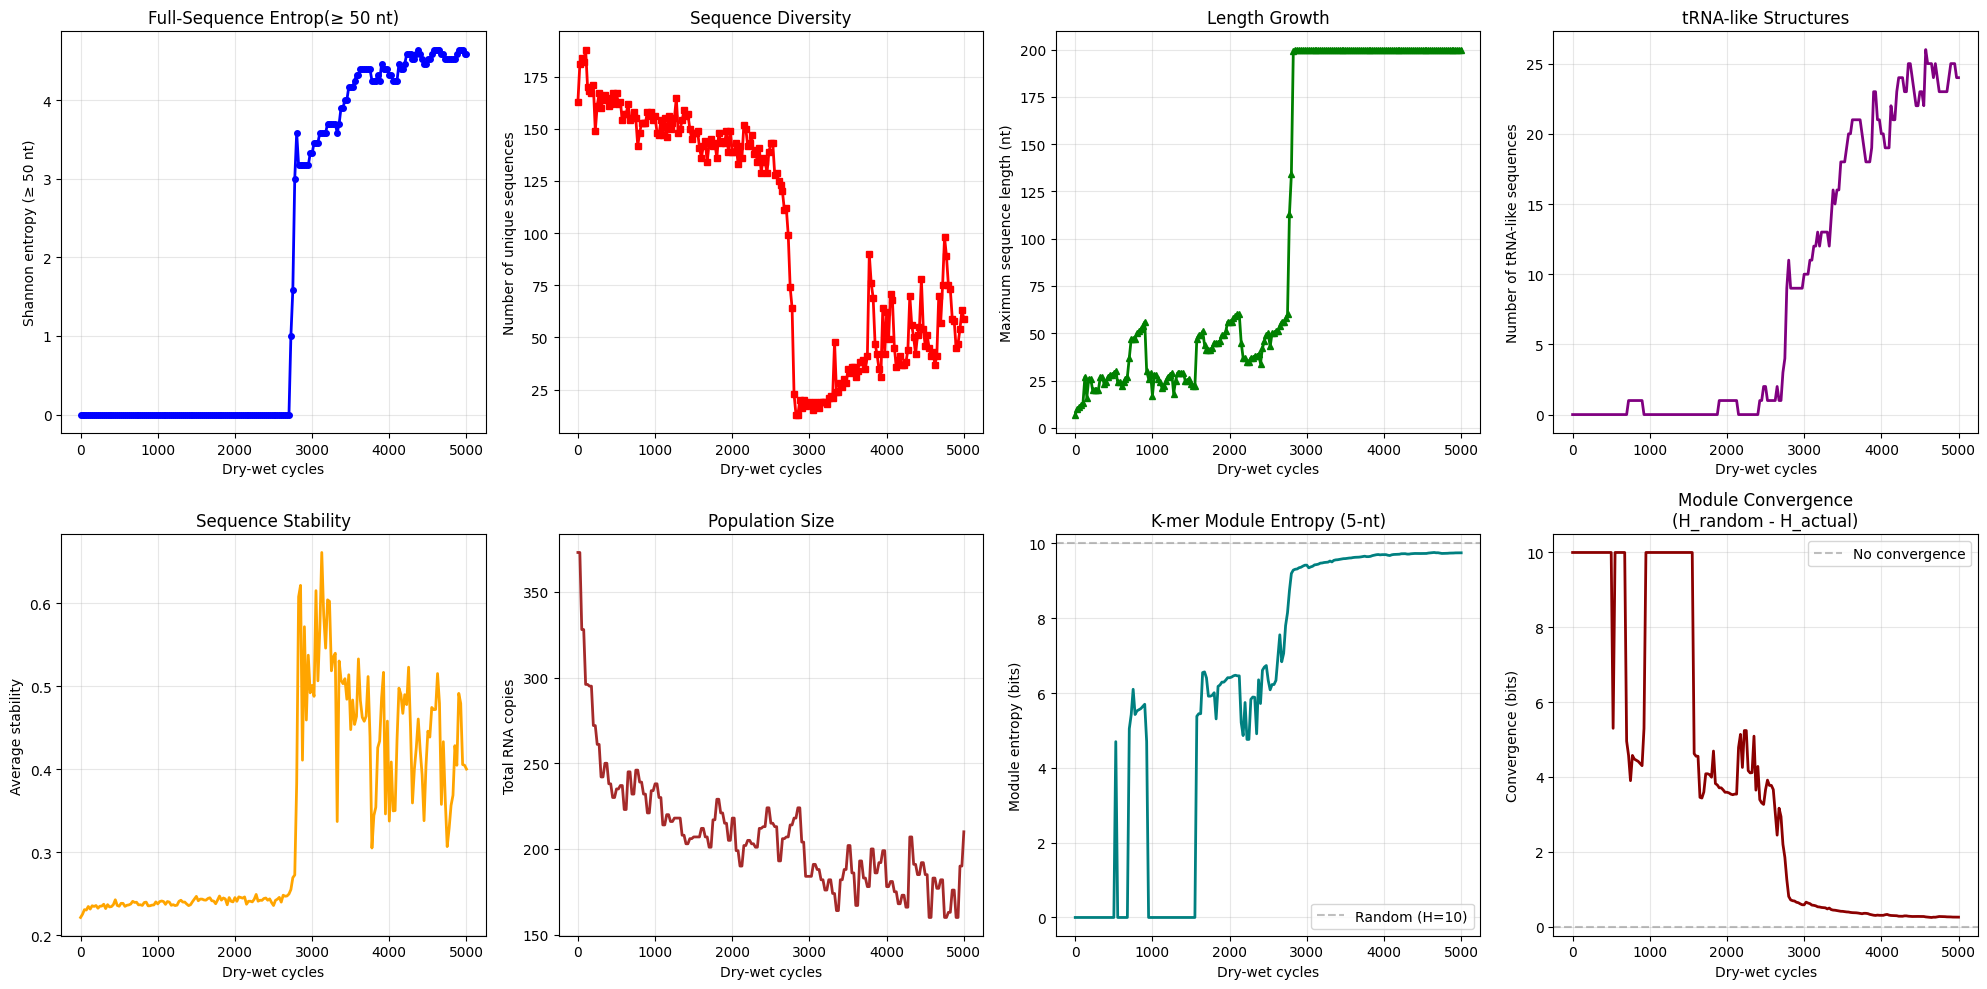


Top 15 Most Frequent Sequences
 1. [    2] GG                                                      (stability=0.200) 
 2. [    1] GCGAACCGUUCUCCGUUCAUUGAAACGUAGCGAAAGUUUGCCAGCGAUGA...   (stability=0.725) ★ tRNA-like
 3. [    1] CCUAUAAGGAACGGGCUAGAUUGUGUCGUGAUUGUUAGCGAAUCGUAUUC...   (stability=0.725) ★ tRNA-like
 4. [    1] UAGCGUUGGGGCUACGUGAUUUUCUUAGGCGUGAUUUUCUUAGGAUCUUC...   (stability=0.725) ★ tRNA-like
 5. [    1] AGGGUAGGAAAUGCCUAGCUCGCCCUGGUGAUGCAGCUAUUAACUGAGUU...   (stability=0.725) ★ tRNA-like
 6. [    1] GAACUAGGCUUCAUUGACAGCGGCAAUUGCUCCAUGGACAACGCCAGCUU...   (stability=0.725) ★ tRNA-like
 7. [    1] GUCAAUAUUCGUUGGUCAAUCUACCAACACCAACACCAACACCAACACCA...   (stability=0.601) ★ tRNA-like
 8. [    1] GACCCGGGCUAGAGGACACUUUCGCGAGGGGUGCGCUGGAUAUACAAAGG...   (stability=0.725) ★ tRNA-like
 9. [    1] GUGGCUGCCGAUUGCAAUAAUCACGGCAAUAAUCACGCUCACACGAGGUA...   (stability=0.725) ★ tRNA-like
10. [    1] CGCGGCCGCUGACUUAAUCUUUCGGGUAUUACCUUAUCUACGCAUUGCGU...   (stability=0.725) ★ tRNA-like

In [ ]:
if __name__ == "__main__":


    # --- EDIT THESE PARAMETERS ---0526
    STABILITY_METHOD = 'vienna'           # 'vienna' or 'heuristic'
    INITIAL_NUCLEOTIDE_POOL = 1000           # Total monomers at start
    NUM_CYCLES =1000                          # Number of wet-dry cycles
    SUPPLEMENTATION_FRACTION = 0.002          # 0.1% of initial pool per cycle
    LIGATION_PROB = 1                     # Base ligation probability
    HARSHNESS = 0.5                         # Environmental harshness
    Wet_degradation_strength=0.35
    Dry_growth_factor = 1
           # initial replication, 1.0 means no replication
    Max_seq_length = 200
    # ----------------------------

    run_demo(
        stability_method=STABILITY_METHOD,
        initial_nucleotide_pool=INITIAL_NUCLEOTIDE_POOL,
        num_cycles=NUM_CYCLES,
        supplementation_fraction=SUPPLEMENTATION_FRACTION,
        ligation_prob=LIGATION_PROB,
        fragmentation_mode=True,
        wet_degradation_strength=Wet_degradation_strength,
        dry_growth_factor=Dry_growth_factor,
        max_seq_length = Max_seq_length,
        harshness=HARSHNESS
    )

     Stability-Distillation Hypothesis Simulation
     Simulating wet-dry cycles driving RNA sequence convergence

Configuration:
  Stability calculation method: VIENNA
  Initial nucleotide pool: 1000 monomers
  Number of cycles: 1000
  Supplementation fraction: 0.2% of initial pool per cycle
  Ligation probability (base): 1
  Environmental harshness: 0.5
    (Higher = more extreme conditions, stability differences amplified)

  ✓ Using ViennaRNA for stability calculations

Simulation initialized
  Initial sequence count: 1
  Unique sequences: 4
  Initial nucleotide pool: 1000
  ViennaRNA available: True
  Fragmentation mode: True
  Environmental harshness: 0.5
  Supplementation fraction: 0.2% of initial pool per cycle
  Ligation base probability: 1

Starting simulation: 1000 wet-dry cycles...
----------------------------------------------------------------------
  Cycle   0: Longest RNA = GUUGGG (length=6)
Cycle    0: Entropy(≥10nt)=0.000 | Unique= 166 | MaxLen=  6 | TotalCopies=   36

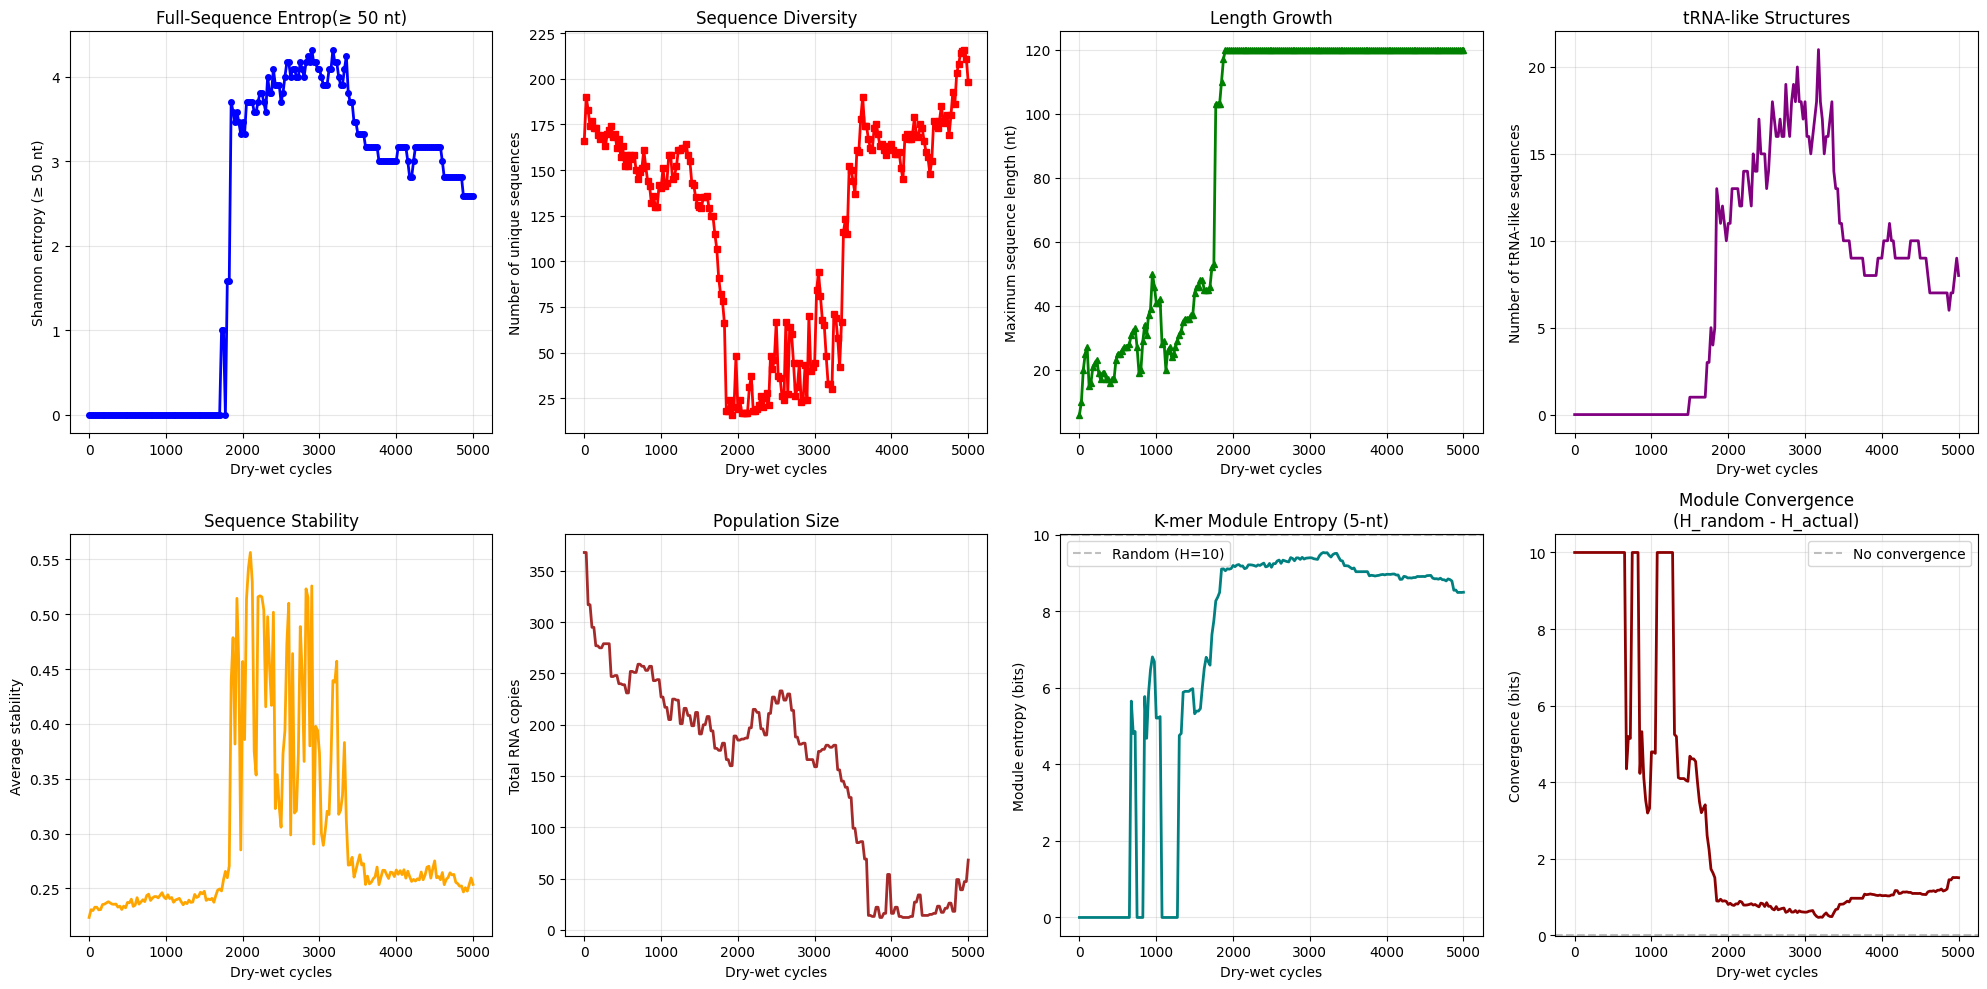


Top 15 Most Frequent Sequences
 1. [    6] UU                                                      (stability=0.200) 
 2. [    4] UC                                                      (stability=0.200) 
 3. [    4] GA                                                      (stability=0.200) 
 4. [    4] CAC                                                     (stability=0.200) 
 5. [    4] AU                                                      (stability=0.200) 
 6. [    3] CU                                                      (stability=0.200) 
 7. [    3] GU                                                      (stability=0.200) 
 8. [    3] CA                                                      (stability=0.200) 
 9. [    3] AG                                                      (stability=0.200) 
10. [    2] UA                                                      (stability=0.200) 
11. [    2] AA                                                      (stability=0.200) 
12. [    2]

In [ ]:
if __name__ == "__main__":


    # --- EDIT THESE PARAMETERS --- 0526
    STABILITY_METHOD = 'vienna'           # 'vienna' or 'heuristic'
    INITIAL_NUCLEOTIDE_POOL = 1000           # Total monomers at start
    NUM_CYCLES =1000                          # Number of wet-dry cycles
    SUPPLEMENTATION_FRACTION = 0.002          # 0.1% of initial pool per cycle
    LIGATION_PROB = 1                     # Base ligation probability
    HARSHNESS = 0.5                         # Environmental harshness
    Wet_degradation_strength=0.35
    Dry_growth_factor = 1.2             # initial replication, 1.0 means no replication
    Max_seq_length = 120
    # ----------------------------

    run_demo(
        stability_method=STABILITY_METHOD,
        initial_nucleotide_pool=INITIAL_NUCLEOTIDE_POOL,
        num_cycles=NUM_CYCLES,
        supplementation_fraction=SUPPLEMENTATION_FRACTION,
        ligation_prob=LIGATION_PROB,
        fragmentation_mode=True,
        wet_degradation_strength=Wet_degradation_strength,
        dry_growth_factor=Dry_growth_factor,
        max_seq_length = Max_seq_length,
        harshness=HARSHNESS
    )

     Stability-Distillation Hypothesis Simulation
     Simulating wet-dry cycles driving RNA sequence convergence

Configuration:
  Stability calculation method: VIENNA
  Initial nucleotide pool: 1000 monomers
  Number of cycles: 1000
  Supplementation fraction: 0.2% of initial pool per cycle
  Ligation probability (base): 1
  Environmental harshness: 0.5
    (Higher = more extreme conditions, stability differences amplified)

  ✓ Using ViennaRNA for stability calculations

Simulation initialized
  Initial sequence count: 1
  Unique sequences: 4
  Initial nucleotide pool: 1000
  ViennaRNA available: True
  Fragmentation mode: True
  Environmental harshness: 0.5
  Supplementation fraction: 0.2% of initial pool per cycle
  Ligation base probability: 1

Starting simulation: 1000 wet-dry cycles...
----------------------------------------------------------------------
  Cycle   0: Longest RNA = CCAGUUCG (length=8)
Cycle    0: Entropy(≥10nt)=0.000 | Unique= 170 | MaxLen=  8 | TotalCopies=   

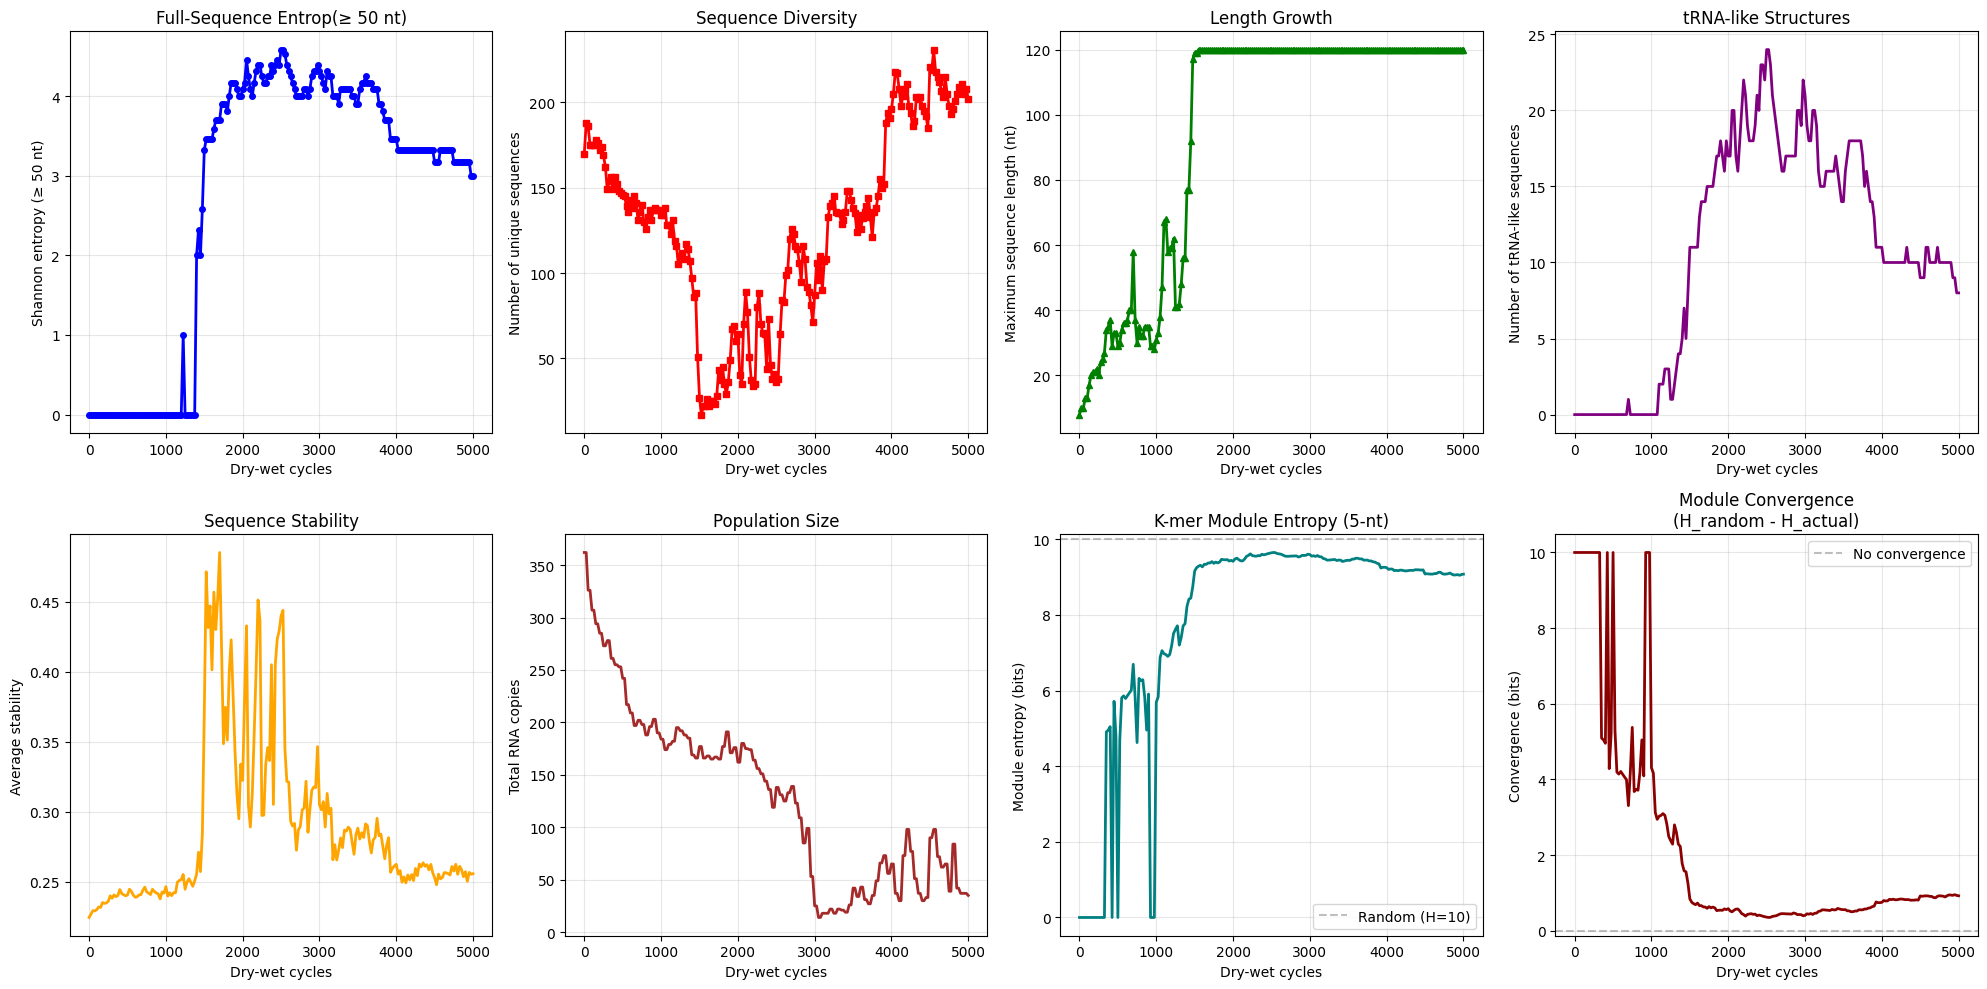


Top 15 Most Frequent Sequences
 1. [    6] AG                                                      (stability=0.200) 
 2. [    6] UC                                                      (stability=0.200) 
 3. [    5] AC                                                      (stability=0.200) 
 4. [    4] UG                                                      (stability=0.200) 
 5. [    4] GU                                                      (stability=0.200) 
 6. [    4] UA                                                      (stability=0.200) 
 7. [    3] CC                                                      (stability=0.200) 
 8. [    3] CG                                                      (stability=0.200) 
 9. [    3] UUC                                                     (stability=0.200) 
10. [    3] GG                                                      (stability=0.200) 
11. [    3] UCG                                                     (stability=0.200) 
12. [    3]

In [ ]:
if __name__ == "__main__":


    # --- EDIT THESE PARAMETERS ---0526
    STABILITY_METHOD = 'vienna'           # 'vienna' or 'heuristic'
    INITIAL_NUCLEOTIDE_POOL = 1000           # Total monomers at start
    NUM_CYCLES =1000                          # Number of wet-dry cycles
    SUPPLEMENTATION_FRACTION = 0.002          # 0.1% of initial pool per cycle
    LIGATION_PROB = 1                     # Base ligation probability
    HARSHNESS = 0.5                         # Environmental harshness
    Wet_degradation_strength=0.35
    Dry_growth_factor = 1.2             # initial replication, 1.0 means no replication
    Max_seq_length = 120
    # ----------------------------

    run_demo(
        stability_method=STABILITY_METHOD,
        initial_nucleotide_pool=INITIAL_NUCLEOTIDE_POOL,
        num_cycles=NUM_CYCLES,
        supplementation_fraction=SUPPLEMENTATION_FRACTION,
        ligation_prob=LIGATION_PROB,
        fragmentation_mode=True,
        wet_degradation_strength=Wet_degradation_strength,
        dry_growth_factor=Dry_growth_factor,
        max_seq_length = Max_seq_length,
        harshness=HARSHNESS
    )

     Stability-Distillation Hypothesis Simulation
     Simulating wet-dry cycles driving RNA sequence convergence

Configuration:
  Stability calculation method: VIENNA
  Initial nucleotide pool: 1000 monomers
  Number of cycles: 1000
  Supplementation fraction: 0.2% of initial pool per cycle
  Ligation probability (base): 1
  Environmental harshness: 0.5
    (Higher = more extreme conditions, stability differences amplified)

  ✓ Using ViennaRNA for stability calculations

Simulation initialized
  Initial sequence count: 1
  Unique sequences: 4
  Initial nucleotide pool: 1000
  ViennaRNA available: True
  Fragmentation mode: True
  Environmental harshness: 0.5
  Supplementation fraction: 0.2% of initial pool per cycle
  Ligation base probability: 1

Starting simulation: 1000 wet-dry cycles...
----------------------------------------------------------------------
  Cycle   0: Longest RNA = CCCUAA (length=6)
Cycle    0: Entropy(≥10nt)=0.000 | Unique= 166 | MaxLen=  6 | TotalCopies=   35

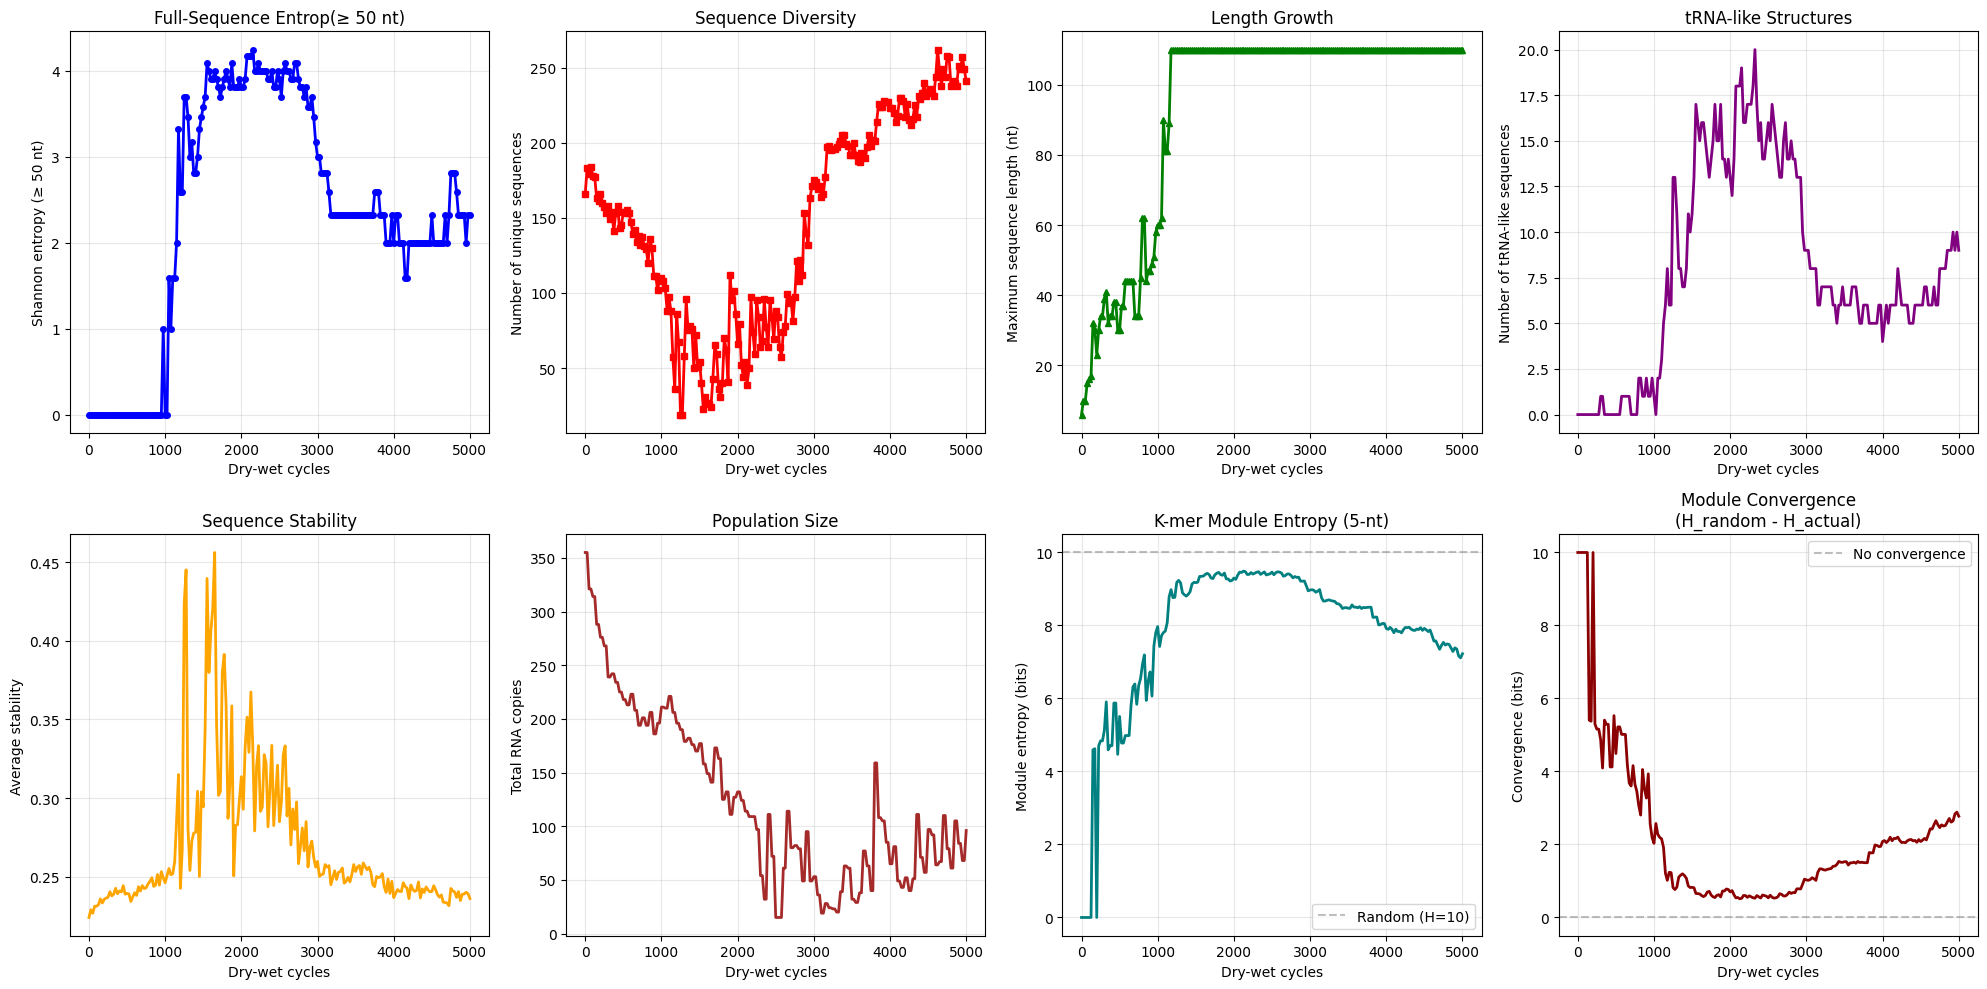


Top 15 Most Frequent Sequences
 1. [   10] CA                                                      (stability=0.200) 
 2. [    8] UU                                                      (stability=0.200) 
 3. [    8] AG                                                      (stability=0.200) 
 4. [    7] AU                                                      (stability=0.200) 
 5. [    7] GU                                                      (stability=0.200) 
 6. [    7] CG                                                      (stability=0.200) 
 7. [    7] AA                                                      (stability=0.200) 
 8. [    6] GA                                                      (stability=0.200) 
 9. [    6] GG                                                      (stability=0.200) 
10. [    6] UA                                                      (stability=0.200) 
11. [    5] GC                                                      (stability=0.200) 
12. [    5]

In [ ]:
if __name__ == "__main__":


    # --- EDIT THESE PARAMETERS ---0526——save
    STABILITY_METHOD = 'vienna'           # 'vienna' or 'heuristic'
    INITIAL_NUCLEOTIDE_POOL = 1000           # Total monomers at start
    NUM_CYCLES =1000                          # Number of wet-dry cycles
    SUPPLEMENTATION_FRACTION = 0.002          # 0.1% of initial pool per cycle
    LIGATION_PROB = 1                     # Base ligation probability
    HARSHNESS = 0.5                         # Environmental harshness
    Wet_degradation_strength=0.35
    Dry_growth_factor = 1.2             # initial replication, 1.0 means no replication
    Max_seq_length = 110
    # ----------------------------

    run_demo(
        stability_method=STABILITY_METHOD,
        initial_nucleotide_pool=INITIAL_NUCLEOTIDE_POOL,
        num_cycles=NUM_CYCLES,
        supplementation_fraction=SUPPLEMENTATION_FRACTION,
        ligation_prob=LIGATION_PROB,
        fragmentation_mode=True,
        wet_degradation_strength=Wet_degradation_strength,
        dry_growth_factor=Dry_growth_factor,
        max_seq_length = Max_seq_length,
        harshness=HARSHNESS
    )

     Stability-Distillation Hypothesis Simulation
     Simulating wet-dry cycles driving RNA sequence convergence

Configuration:
  Stability calculation method: VIENNA
  Initial nucleotide pool: 1000 monomers
  Number of cycles: 1000
  Supplementation fraction: 0.2% of initial pool per cycle
  Ligation probability (base): 1
  Environmental harshness: 0.5
    (Higher = more extreme conditions, stability differences amplified)

  ✓ Using ViennaRNA for stability calculations

Simulation initialized
  Initial sequence count: 1
  Unique sequences: 4
  Initial nucleotide pool: 1000
  ViennaRNA available: True
  Fragmentation mode: True
  Environmental harshness: 0.5
  Supplementation fraction: 0.2% of initial pool per cycle
  Ligation base probability: 1

Starting simulation: 1000 wet-dry cycles...
----------------------------------------------------------------------
  Cycle   0: Longest RNA = UGAAGU (length=6)
Cycle    0: Entropy(≥10nt)=0.000 | Unique= 170 | MaxLen=  6 | TotalCopies=   36

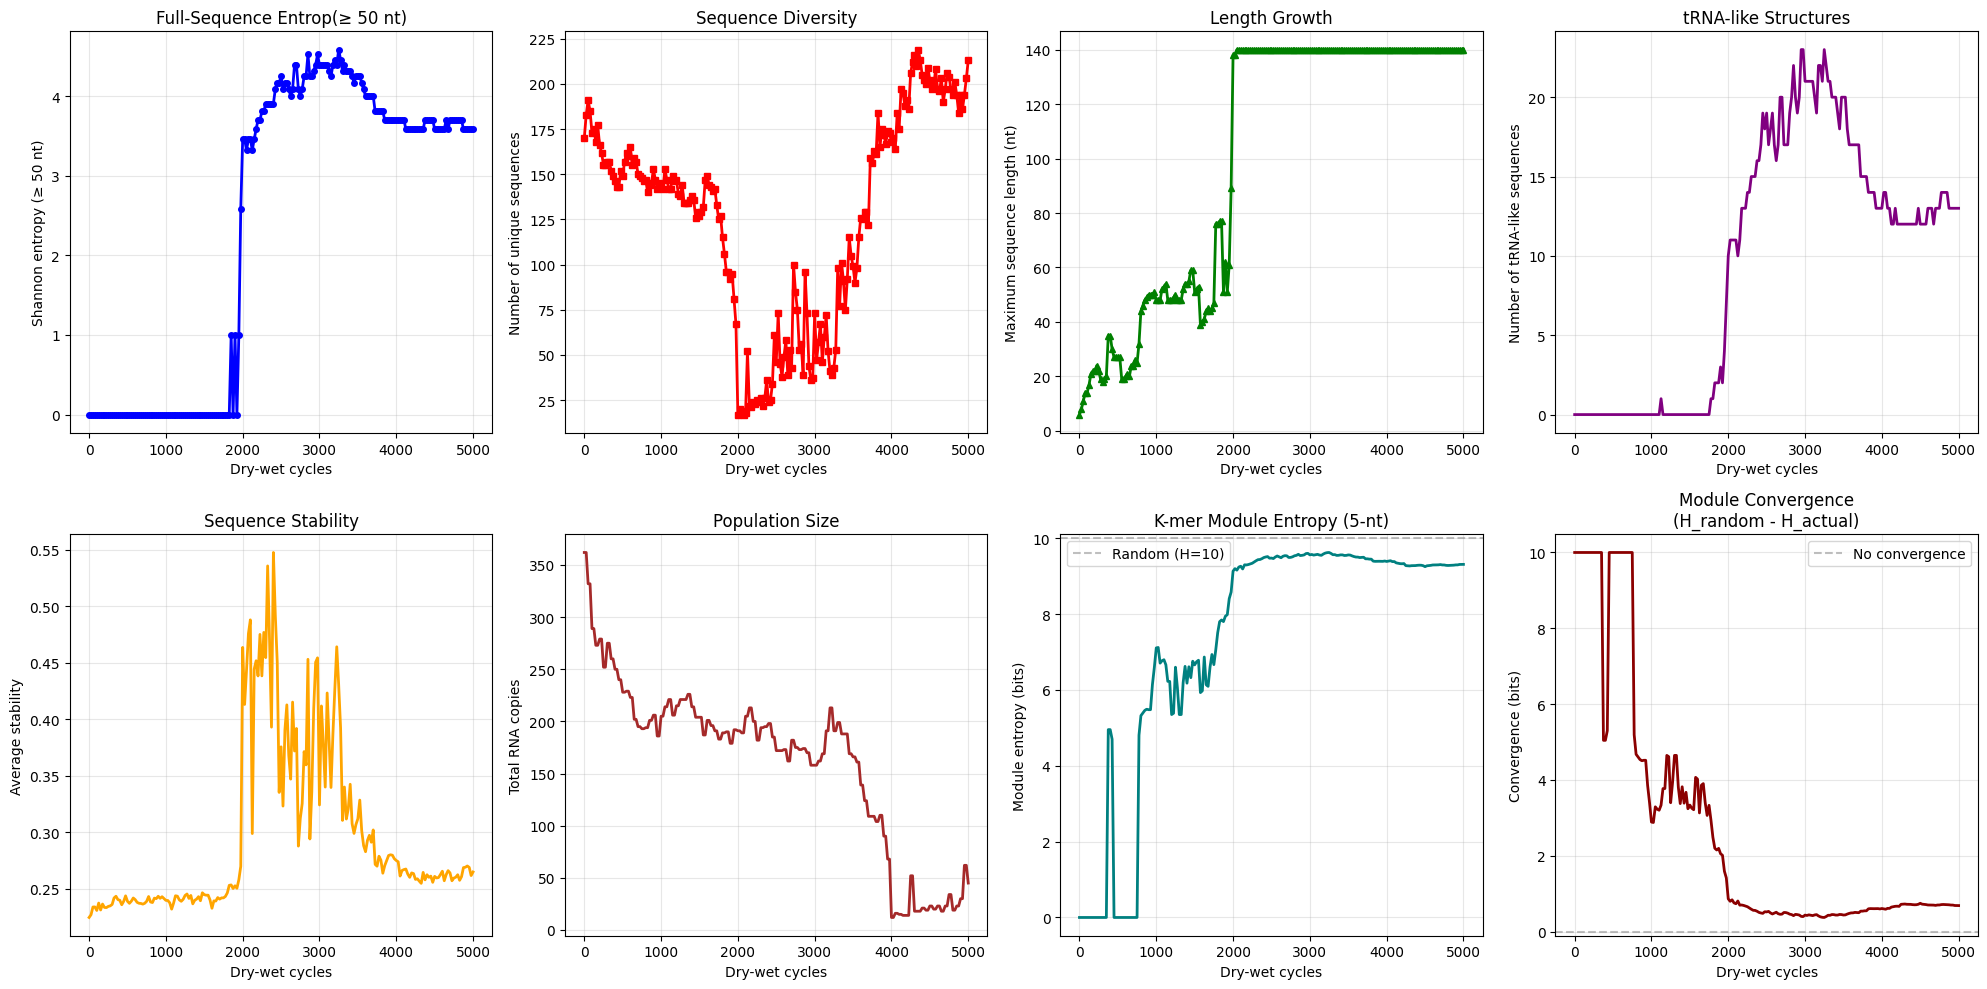


Top 15 Most Frequent Sequences
 1. [    6] UA                                                      (stability=0.200) 
 2. [    5] CC                                                      (stability=0.200) 
 3. [    4] AA                                                      (stability=0.200) 
 4. [    4] GG                                                      (stability=0.200) 
 5. [    4] CA                                                      (stability=0.200) 
 6. [    3] GC                                                      (stability=0.200) 
 7. [    3] UU                                                      (stability=0.200) 
 8. [    3] AG                                                      (stability=0.200) 
 9. [    3] AU                                                      (stability=0.200) 
10. [    3] CU                                                      (stability=0.200) 
11. [    3] CG                                                      (stability=0.200) 
12. [    3]

In [ ]:
if __name__ == "__main__":


    # --- EDIT THESE PARAMETERS ---0526
    STABILITY_METHOD = 'vienna'           # 'vienna' or 'heuristic'
    INITIAL_NUCLEOTIDE_POOL = 1000           # Total monomers at start
    NUM_CYCLES =1000                          # Number of wet-dry cycles
    SUPPLEMENTATION_FRACTION = 0.002          # 0.1% of initial pool per cycle
    LIGATION_PROB = 1                     # Base ligation probability
    HARSHNESS = 0.5                         # Environmental harshness
    Wet_degradation_strength=0.35
    Dry_growth_factor = 1.2             # initial replication, 1.0 means no replication
    Max_seq_length = 140
    # ----------------------------

    run_demo(
        stability_method=STABILITY_METHOD,
        initial_nucleotide_pool=INITIAL_NUCLEOTIDE_POOL,
        num_cycles=NUM_CYCLES,
        supplementation_fraction=SUPPLEMENTATION_FRACTION,
        ligation_prob=LIGATION_PROB,
        fragmentation_mode=True,
        wet_degradation_strength=Wet_degradation_strength,
        dry_growth_factor=Dry_growth_factor,
        max_seq_length = Max_seq_length,
        harshness=HARSHNESS
    )

     Stability-Distillation Hypothesis Simulation
     Simulating wet-dry cycles driving RNA sequence convergence

Configuration:
  Stability calculation method: VIENNA
  Initial nucleotide pool: 1000 monomers
  Number of cycles: 1000
  Supplementation fraction: 0.2% of initial pool per cycle
  Ligation probability (base): 1
  Environmental harshness: 0.5
    (Higher = more extreme conditions, stability differences amplified)

  ✓ Using ViennaRNA for stability calculations

Simulation initialized
  Initial sequence count: 1
  Unique sequences: 4
  Initial nucleotide pool: 1000
  ViennaRNA available: True
  Fragmentation mode: True
  Environmental harshness: 0.5
  Supplementation fraction: 0.2% of initial pool per cycle
  Ligation base probability: 1

Starting simulation: 1000 wet-dry cycles...
----------------------------------------------------------------------
  Cycle   0: Longest RNA = ACCAUAGG (length=8)
Cycle    0: Entropy(≥10nt)=0.000 | Unique= 169 | MaxLen=  8 | TotalCopies=   

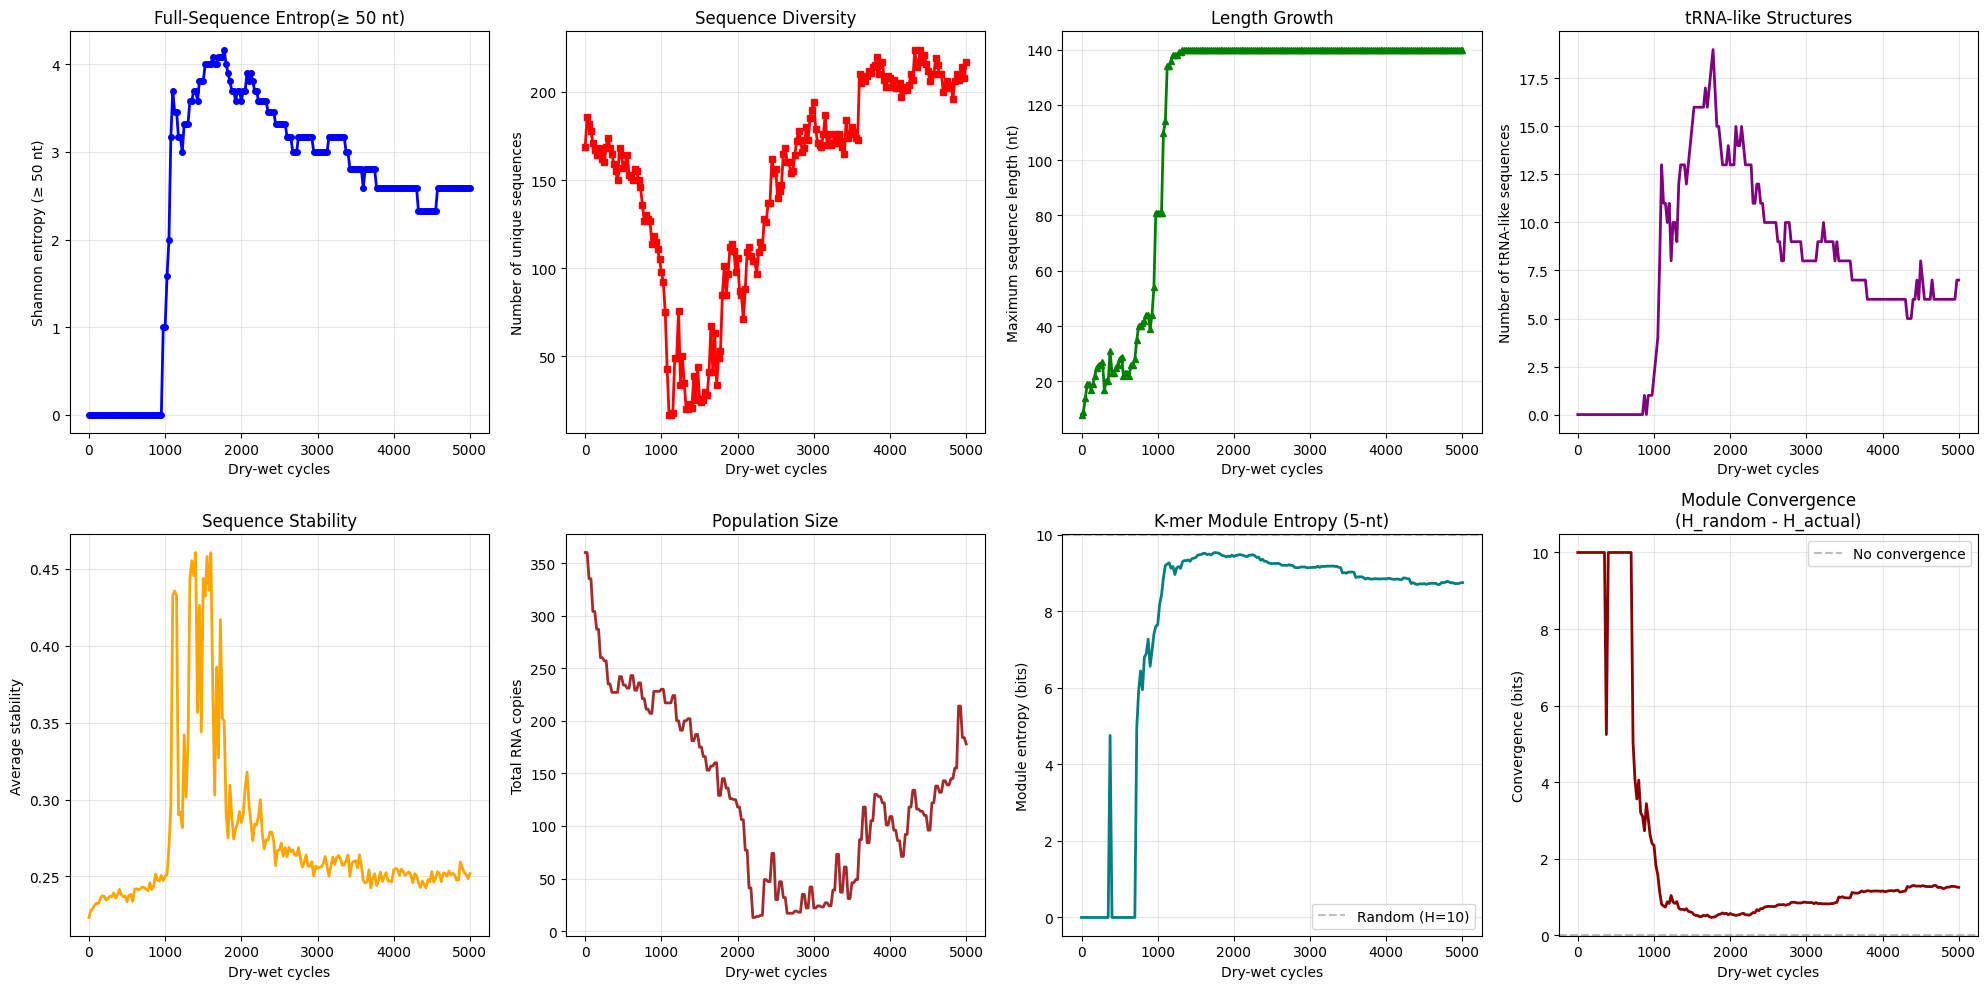


Top 15 Most Frequent Sequences
 1. [    7] AA                                                      (stability=0.200) 
 2. [    6] AU                                                      (stability=0.200) 
 3. [    6] UA                                                      (stability=0.200) 
 4. [    5] UU                                                      (stability=0.200) 
 5. [    5] AAU                                                     (stability=0.200) 
 6. [    4] GU                                                      (stability=0.200) 
 7. [    4] GA                                                      (stability=0.200) 
 8. [    4] AC                                                      (stability=0.200) 
 9. [    3] CU                                                      (stability=0.200) 
10. [    3] AG                                                      (stability=0.200) 
11. [    3] UC                                                      (stability=0.200) 
12. [    3]

In [ ]:
if __name__ == "__main__":


    # --- EDIT THESE PARAMETERS ---0526
    STABILITY_METHOD = 'vienna'           # 'vienna' or 'heuristic'
    INITIAL_NUCLEOTIDE_POOL = 1000           # Total monomers at start
    NUM_CYCLES =1000                          # Number of wet-dry cycles
    SUPPLEMENTATION_FRACTION = 0.002          # 0.1% of initial pool per cycle
    LIGATION_PROB = 1                     # Base ligation probability
    HARSHNESS = 0.5                         # Environmental harshness
    Wet_degradation_strength=0.35
    Dry_growth_factor = 1.2             # initial replication, 1.0 means no replication
    Max_seq_length = 140
    # ----------------------------

    run_demo(
        stability_method=STABILITY_METHOD,
        initial_nucleotide_pool=INITIAL_NUCLEOTIDE_POOL,
        num_cycles=NUM_CYCLES,
        supplementation_fraction=SUPPLEMENTATION_FRACTION,
        ligation_prob=LIGATION_PROB,
        fragmentation_mode=True,
        wet_degradation_strength=Wet_degradation_strength,
        dry_growth_factor=Dry_growth_factor,
        max_seq_length = Max_seq_length,
        harshness=HARSHNESS
    )

     Stability-Distillation Hypothesis Simulation
     Simulating wet-dry cycles driving RNA sequence convergence

Configuration:
  Stability calculation method: VIENNA
  Initial nucleotide pool: 1000 monomers
  Number of cycles: 400
  Supplementation fraction: 0.2% of initial pool per cycle
  Ligation probability (base): 1
  Environmental harshness: 0.5
    (Higher = more extreme conditions, stability differences amplified)

  ✓ Using ViennaRNA for stability calculations

Simulation initialized
  Initial sequence count: 1
  Unique sequences: 4
  Initial nucleotide pool: 1000
  ViennaRNA available: True
  Fragmentation mode: True
  Environmental harshness: 0.5
  Supplementation fraction: 0.2% of initial pool per cycle
  Ligation base probability: 1

Starting simulation: 400 wet-dry cycles...
----------------------------------------------------------------------
  Cycle   0: Longest RNA = CCCACAU (length=7)
Cycle    0: Entropy(≥10nt)=0.000 | Unique= 172 | MaxLen=  7 | TotalCopies=   362

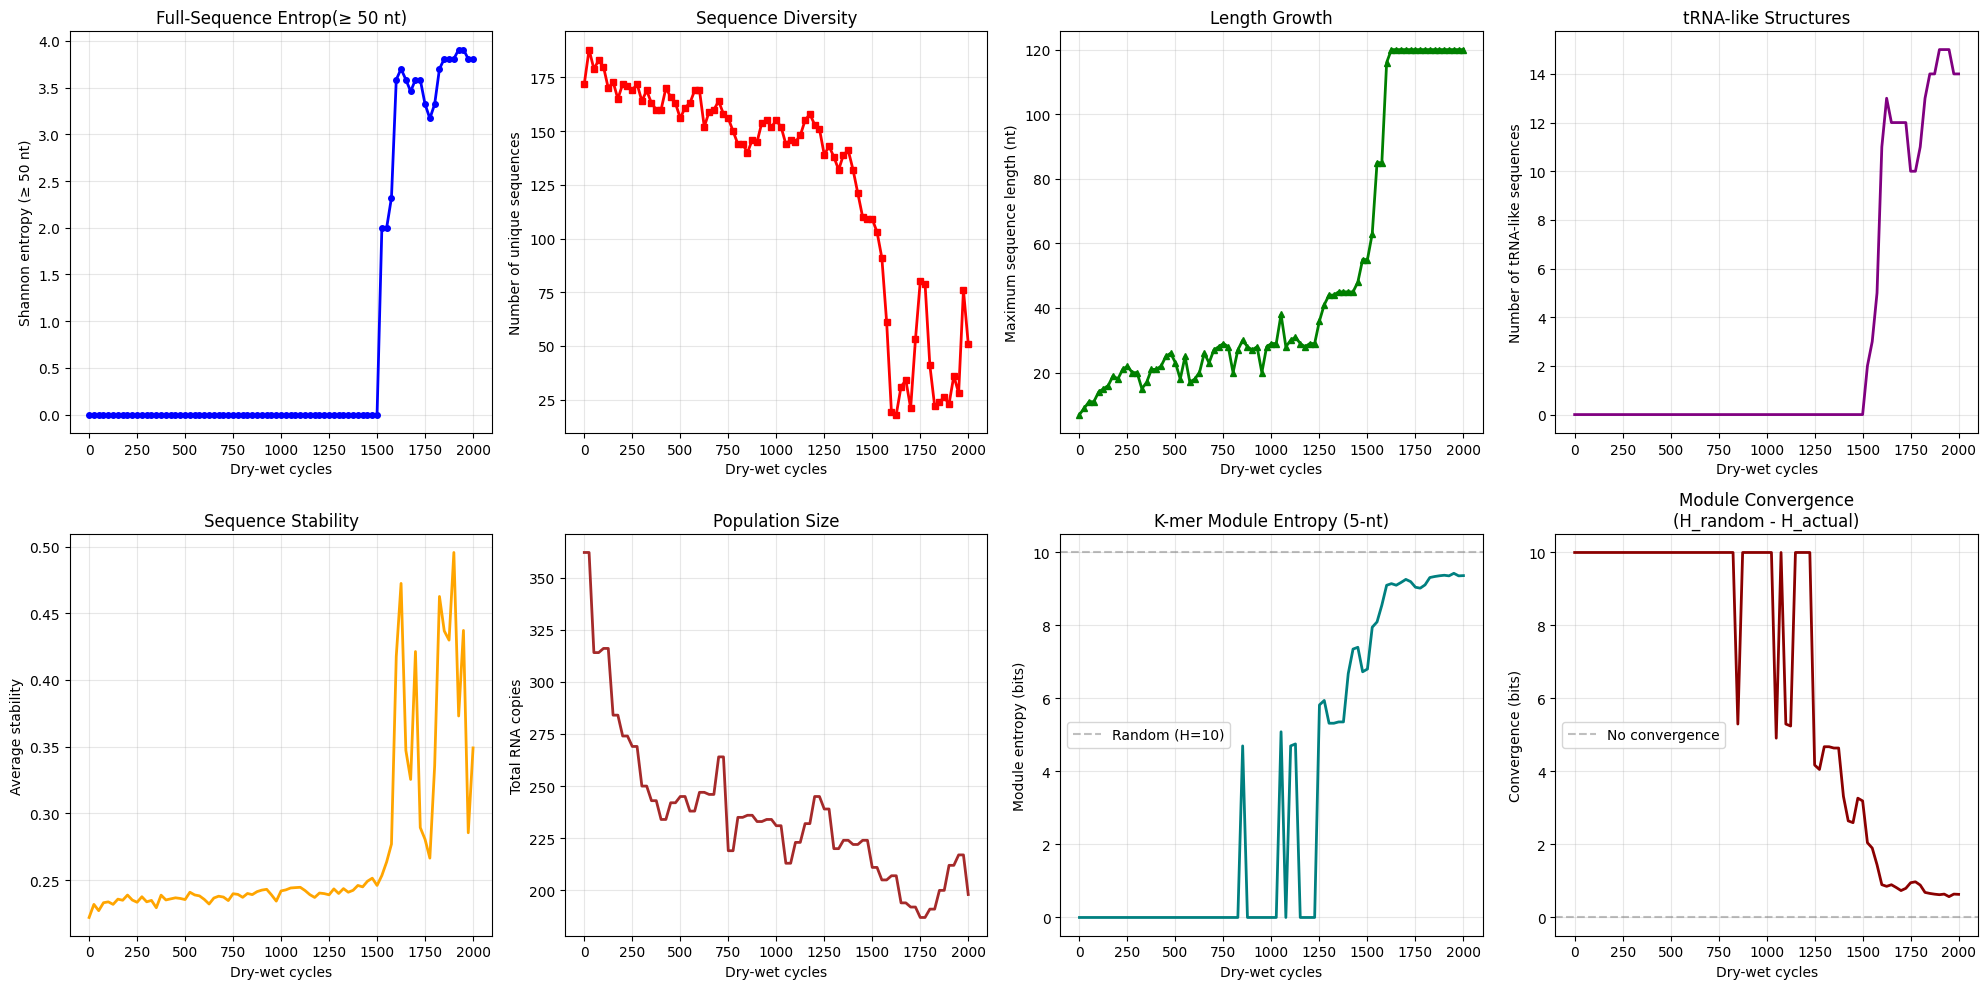


Top 15 Most Frequent Sequences
 1. [    1] GCUUACUCGGAUAACUAGUGUACCCUAUUUUGUUAAUACCAUAAUGGAGU...   (stability=0.436) ★ tRNA-like
 2. [    1] CGCGUAUUCAUUACAAUAUGCCGUGUGGAUUCAUGAGGGACUAAAUCGGG...   (stability=0.517) ★ tRNA-like
 3. [    1] CAGAUGUGAACCCCACUGUGUUUCGCGCACAGGGGUCUGACCGACUGUUA...   (stability=0.630) ★ tRNA-like
 4. [    1] GGGUGUCGAAAGACAUCCUGUUGUUGCUUCAGCCAGGGCAACUUCCGCGG...   (stability=0.611) ★ tRNA-like
 5. [    1] UUCACAGCUCACUAUGAAACCACGAGACCUUUUCAUUCAGAGAUUUCGUA...   (stability=0.487) ★ tRNA-like
 6. [    1] GCCUUGUAGAUGAACUGGGGGAUUAGGCAUGAAGCUCUUCCGUGAUCCUA...   (stability=0.647) ★ tRNA-like
 7. [    1] UACAUCUGACAGUCAUCUGACAGUGGCUGAAGCAUCUCUAGUGACGGGCU...   (stability=0.592) ★ tRNA-like
 8. [    1] CGUUCAAUUGUGGGCCAGGACUGGAUGACGAUUGGGCGACGAGGAGUGCC...   (stability=0.614) ★ tRNA-like
 9. [    1] AUGGCCGCUCAAGAGGCUUACGUGCGUAAACCGGAGUAGUCUGAAGCGCG...   (stability=0.607) ★ tRNA-like
10. [    1] CGCGAGGGCUAACUAUGUUGGUUUGGCCUUCGCUCCAGUUCCAUAUUUAA...   (stability=0.555) 

In [19]:
if __name__ == "__main__":


    # --- EDIT THESE PARAMETERS --- 0526
    STABILITY_METHOD = 'vienna'           # 'vienna' or 'heuristic'
    INITIAL_NUCLEOTIDE_POOL = 1000           # Total monomers at start
    NUM_CYCLES =400                          # Number of wet-dry cycles
    SUPPLEMENTATION_FRACTION = 0.002          # 0.1% of initial pool per cycle
    LIGATION_PROB = 1                     # Base ligation probability
    HARSHNESS = 0.5                         # Environmental harshness
    Wet_degradation_strength=0.35
    Dry_growth_factor = 1.5            # initial replication, 1.0 means no replication
    Max_seq_length = 120
    # ----------------------------

    run_demo(
        stability_method=STABILITY_METHOD,
        initial_nucleotide_pool=INITIAL_NUCLEOTIDE_POOL,
        num_cycles=NUM_CYCLES,
        supplementation_fraction=SUPPLEMENTATION_FRACTION,
        ligation_prob=LIGATION_PROB,
        fragmentation_mode=True,
        wet_degradation_strength=Wet_degradation_strength,
        dry_growth_factor=Dry_growth_factor,
        max_seq_length = Max_seq_length,
        harshness=HARSHNESS
    )

In [ ]:
# clear_memory
def clear_memory_between_stages():
    """clear_memory"""
    import gc

    for name in dir():
        obj = globals().get(name)
        if obj is not None and hasattr(obj, '__sizeof__'):
            if obj.__sizeof__() > 1e6:  #
                print(f"  Deleting {name} ({obj.__sizeof__()//1024} KB)")
                del globals()[name]
    gc.collect()
    print("  Memory cleared between stages")

clear_memory_between_stages()

**Stage 2 Simulation Logic Explanation**

1.**Overall Framework: The Two-Pool System**

The simulation uses two connected pools to model the upstream-downstream relationship in natural geothermal systems:

**Pool A (Upstream)**: High temperature, strong wet-dry cycles. Here, RNA stability distillation continuously occurs—randomly generated RNAs are filtered through wet-dry cycles; unstable sequences degrade, stable ones are retained. This pool continuously sends three things downstream: stable RNA sequences, lipid molecules, and primitive cells that have already encapsulated RNA.

**Pool B (Downstream)**: Lower temperature, weaker wet-dry cycles. This is where cellular evolution truly happens. Materials from upstream are utilized, competed over, and evolved by cells. DNA emerges here, and viruses originate here.

In theory, this system can be extended into multiple sequential pools—the further downstream, the more stable the environment, the weaker the wet-dry cycles, and the more suitable for normal cell division and reproduction. This gradient naturally separates the processes of "RNA distillation" and "cellular evolution."

**2. Translation System: The Dual-Tag Mechanism**

For cells to produce proteins, ribosomes need to recognize specific sequences on RNA. The simulation uses "tags" to represent these recognition sequences:

Normal Tags (10 tags, length 4): Represent regulatory elements that cells evolve on their own. More tags mean higher translation efficiency:

0-1 tags: Baseline efficiency (1x)

2-3 tags: 10x efficiency

4-5 tags: 20x efficiency

6+ tags: 30x efficiency

Special Tags (10 tags, length 8): Represent viral super-enhancers. Only a few are needed to dramatically increase translation efficiency:

1 special tag: 30x efficiency

2 special tags: 100x efficiency

3+ special tags: 1000x efficiency

This dual-layer design simulates two parallel evolutionary paths: "cellular self-optimization" (slow, gradual) and "virus-mediated leapfrog evolution" (fast, abrupt).


**3. Protein-Dependent DNA Replication**

This is a key design: DNA cannot replicate on its own; it requires protein.

Each cell has a "translation rate" metric representing the speed of protein synthesis. DNA replication speed is coupled to this metric:

Very low translation rate → DNA barely replicates

Medium translation rate → DNA replicates slowly

Very high translation rate → DNA replicates at maximum speed

This simulates biological reality: DNA replication requires DNA polymerase, helicase, and many other proteins. Without protein, DNA cannot replicate. Therefore, only cells that can efficiently produce proteins can proliferate—natural selection naturally favors beneficial genes.

**4. The Dual Threshold for Cell Division**

For a cell to divide, two conditions must be met simultaneously:

Sufficient total macromolecules (representing adequate cellular content)

Sufficient protein mass (representing functional capability)

Even if a cell is large, it cannot divide without enough protein. This design prevents "empty shell" cells from dividing simply by accumulating mass—cells must be functional (able to produce proteins) to reproduce.

**5. Reverse Transcription: The Origin of DNA**

DNA cells do not pre-exist; they arise from RNA cells through reverse transcription.

Intracellular Reverse Transcription (High Efficiency) : Cells use internal RNA as a template to reverse transcribe RNA into DNA. This is the primary pathway for DNA emergence. Once an RNA cell successfully acquires its first piece of DNA, it transforms into a DNA cell, possessing a stably inheritable genome.

Environmental Reverse Transcription (Very Low Efficiency) : RNA also exists in the environment, but due to low concentration, the success rate is only 1%. This simulates the core idea that "cells are the unit of evolution"—important genetic innovations occur inside cells.

**6. Encapsulation During Dry Phase: The Birth of New Cells**

During the dry phase of each cycle, when water evaporates and the environment becomes concentrated, two things happen:

First, lipids in the environment spontaneously self-assemble into vesicles. Second, these vesicles randomly encapsulate surrounding materials (RNA, DNA fragments, etc.), forming new cells.

The number of new cells is determined by available lipids—more lipids mean more new cells can form. The default is 20% of the theoretical maximum. This simulates the abiotic formation of protocells in drying environments.

**7. Virus Origin: Rupture from Excessive Growth**

When a cell produces protein too quickly, it falls into a crisis:

High translation efficiency → Rapid macromolecule synthesis

    ↓
Macromolecules accumulate faster than lipid supply

    ↓
Insufficient lipids for division → Cell cannot divide

    ↓
Continued accumulation → Osmotic pressure increases

    ↓
Water influx → Cell swelling → Membrane rupture

    ↓
Contents released (DNA, RNA, proteins) into environment

**8. The Primitive Virus Transmission Cycle**

DNA released from ruptured cells becomes "primitive vectors" (free DNA) in the environment. During the next dry phase, these vectors are encapsulated by lipid vesicles, forming new DNA cells. These new cells carry viral genetic material, have high translation efficiency (from special tags), grow rapidly, consume lipids, and rupture again—the cycle repeats.

This cycle explains why viral genetic material tends to be highly efficient—they are "accelerators" selected by natural selection.


**9. DNA as a Mapping of Environmental RNA**

This is the key to understanding the entire simulation:

The DNA sequences in cells are not arbitrary; they are a compressed mapping of the environmental RNA distribution. Reverse transcription takes a "snapshot" of environmental RNA and stores it as DNA. Therefore:

DNA sequences show high similarity to environmental RNA (similarity > 0.7 indicates successful capture)

Special tags appear in DNA after appearing in the environment

The genome reflects the evolutionary history of the cell's environment

This means that cellular DNA is essentially a "log book" recording which useful RNA sequences its ancestors once encountered.

**10. Current Limitations (Computational Constraints)**

Due to computational limitations, the current simulation does NOT explicitly model the following processes:

rRNA evolution

Ribosome assembly

Complete translation system evolution (genetic code, tRNA charging, etc.)

Full metabolic networks

Instead, we made a simplification: assuming cells already possess a functional translation system capable of polymerizing amino acids into proteins. Translation rate is modeled as a function of RNA structural stability and tag count.

Adding these processes would increase complexity by 10-100x, but the core conclusion (the necessity of DNA for stable inheritance) does not require these details. These remain important directions for future research.

**11. Future Plans (Stage 3)**

Cell Membrane Evolution: Cells evolve ion channels and active transport to regulate osmotic pressure. Even with rapid macromolecule synthesis, cells can control water flow by regulating ion concentrations, preventing immediate rupture.

Virus Counter-Evolution: Viruses evolve membrane attack proteins that can directly disrupt cell membranes, bypassing the cell's osmotic regulation.

Continuing Arms Race: Cells evolve stronger membranes → viruses evolve stronger attacks → cells evolve immune recognition → viruses evolve immune evasion → the cycle continues to the present day.

**12. Core Conclusion**

The simulation reveals a profound insight: Cells and viruses are not separate evolutionary lineages but two sides of the same coin.

Cells provide the "factory"—stable genetic storage and protein synthesis

Viruses provide the "vector"—a medium for horizontal gene transfer

The very same process that created the first DNA cells—rapid replication leading to lipid depletion and rupture—inevitably produced primitive viral particles. Cells and viruses emerged together, locked in a co-evolutionary relationship that continues to shape all life on Earth.

Viruses are not late-appearing parasites; they are an intrinsic component of the origin of life.




In [ ]:
print("hi")

In [33]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
STAGE 2: DNA Emergence with Dual-Tag System, Protein-Dependent Replication, and Sequence Similarity Analysis
================================================================================
SIMULATION LOGIC DESCRIPTION
================================================================================

This simulation implements a two-pool system where DNA emerges naturally from
RNA-only cells through reverse transcription, with a dual-tag system for
translation regulation and protein-dependent DNA replication.

KEY MECHANISMS:

1. PROTEIN-DEPENDENT DNA REPLICATION:
   - DNA replication rate depends on protein synthesis rate
   - No protein → No DNA replication → No cell division
   - This creates real natural selection for functional genes

2. PROTEIN-DEPENDENT CELL DIVISION:
   - Division requires sufficient protein mass (not just total macromolecules)
   - Cells cannot divide without functional translation system

3. DUAL-TAG TRANSLATION SYSTEM:
   - Normal tags (10 tags): 2 tags=10x, 4 tags=20x, 6+ tags=30x
   - Special tags (10 tags): 1 tag=30x, 2 tags=100x, 3+ tags=1000x

4. SEQUENCE SIMILARITY ANALYSIS:
   - DNA-RNA similarity (T↔U mapping) shows reverse transcription fidelity
   - Special tag distribution in DNA vs environmental RNA
   - Tracks horizontal gene transfer

5. MULTI-CELL ENCAPSULATION:
   - New cells based on lipid availability

================================================================================
"""

import numpy as np
import random
import matplotlib.pyplot as plt
from collections import defaultdict
import warnings
import json
warnings.filterwarnings('ignore')

# Try to import ViennaRNA for accurate stability calculation
try:
    import RNA
    VIENNA_AVAILABLE = True
    print("✓ ViennaRNA loaded successfully")
except ImportError:
    VIENNA_AVAILABLE = False
    print("⚠ ViennaRNA not available, using heuristic stability function")

# ============================================================================
# Part 1: Stability Calculation Functions
# ============================================================================

USE_VIENNA_GLOBAL = False
HARSHNESS_GLOBAL = 1.0

def calculate_stability_vienna(sequence, harshness=1.0):
    if len(sequence) < 4:
        return 0.2, "", 0
    try:
        fc = RNA.fold_compound(sequence)
        (ss, mfe) = fc.mfe()
        raw_stability = -mfe / 50.0
        stability = min(0.95, max(0.05, raw_stability))
        if harshness != 1.0:
            deviation = stability - 0.5
            stability = 0.5 + deviation * harshness
            stability = min(0.95, max(0.05, stability))
        return stability, ss, mfe
    except:
        return calculate_stability_heuristic(sequence, harshness), "", 0

def calculate_stability_heuristic(sequence, harshness=1.0):
    if len(sequence) < 4:
        return 0.2
    comp_map = {'A': 'U', 'U': 'A', 'G': 'C', 'C': 'G'}
    half_len = len(sequence) // 2
    complement_score = 0
    if half_len >= 1:
        first_half = sequence[:half_len]
        second_half_rev = sequence[half_len:][::-1]
        matches = 0
        for i in range(min(len(first_half), len(second_half_rev))):
            if comp_map.get(first_half[i], '') == second_half_rev[i]:
                matches += 1
        complement_score = matches / max(1, half_len)
    structural_score = 0
    for i in range(len(sequence) - 3):
        for length in range(3, min(8, (len(sequence) - i) // 2)):
            left = sequence[i:i+length]
            right = sequence[i+length:i+2*length][::-1]
            if len(right) >= length:
                matches = 0
                for k in range(length):
                    if comp_map.get(left[k], '') == right[k]:
                        matches += 1
                pair_rate = matches / length
                if pair_rate > structural_score:
                    structural_score = pair_rate
    gc_ratio = (sequence.count('G') + sequence.count('C')) / len(sequence)
    stability = 0.1 + 0.5 * complement_score + 0.3 * structural_score + 0.1 * gc_ratio
    if len(sequence) > 30 and structural_score > 0.5:
        stability = min(0.95, stability + 0.1)
    if harshness != 1.0:
        deviation = stability - 0.5
        stability = 0.5 + deviation * harshness
        stability = min(0.95, max(0.05, stability))
    return stability

def get_stability(sequence):
    if USE_VIENNA_GLOBAL and VIENNA_AVAILABLE and len(sequence) >= 4:
        stability, _, _ = calculate_stability_vienna(sequence, HARSHNESS_GLOBAL)
        return stability
    else:
        return calculate_stability_heuristic(sequence, HARSHNESS_GLOBAL)


# ============================================================================
# Part 2: Dual-Tag Translation System
# ============================================================================

MIN_TRANSLATION_LENGTH = 20

# Normal tags (10 tags, length 4) - for cellular optimization
NUM_NORMAL_TAGS = 10
NORMAL_TAG_LENGTH = 4
NORMAL_TAG_BOOST_2 = 10.0
NORMAL_TAG_BOOST_4 = 20.0
NORMAL_TAG_BOOST_6 = 30.0

# Special tags (10 tags, length 8) - viral/high-efficiency elements
NUM_SPECIAL_TAGS = 10
SPECIAL_TAG_LENGTH = 8
SPECIAL_TAG_BOOST_1 = 30
SPECIAL_TAG_BOOST_2 = 100.0
SPECIAL_TAG_BOOST_3 = 1000.0

NORMAL_TAGS = []
SPECIAL_TAGS = []

def initialize_tags(seed=None):
    """Initialize normal and special translation tags."""
    global NORMAL_TAGS, SPECIAL_TAGS
    if seed is not None:
        random.seed(seed)

    nucleotides = ['A', 'U', 'G', 'C']

    # Generate normal tags (length 4)
    NORMAL_TAGS = []
    for _ in range(NUM_NORMAL_TAGS):
        tag = ''.join(random.choice(nucleotides) for _ in range(NORMAL_TAG_LENGTH))
        NORMAL_TAGS.append(tag)

    # Generate special tags (length 8)
    SPECIAL_TAGS = []
    for _ in range(NUM_SPECIAL_TAGS):
        tag = ''.join(random.choice(nucleotides) for _ in range(SPECIAL_TAG_LENGTH))
        SPECIAL_TAGS.append(tag)

    print(f"  Normal tags: {NUM_NORMAL_TAGS} tags (length {NORMAL_TAG_LENGTH})")
    print(f"  Special tags: {NUM_SPECIAL_TAGS} tags (length {SPECIAL_TAG_LENGTH})")

def count_normal_tags(sequence):
    """Count how many normal tags appear in the sequence."""
    count = 0
    for tag in NORMAL_TAGS:
        if tag in sequence:
            count += 1
    return count

def count_special_tags(sequence):
    """Count how many special tags appear in the sequence."""
    count = 0
    for tag in SPECIAL_TAGS:
        if tag in sequence:
            count += 1
    return count

def get_normal_tag_boost(count):
    """Get translation boost from normal tags."""
    if count >= 6:
        return NORMAL_TAG_BOOST_6
    elif count >= 4:
        return NORMAL_TAG_BOOST_4
    elif count >= 2:
        return NORMAL_TAG_BOOST_2
    else:
        return 1.0

def get_special_tag_boost(count):
    """Get translation boost from special tags (viral/high-efficiency)."""
    if count >= 3:
        return SPECIAL_TAG_BOOST_3
    elif count >= 2:
        return SPECIAL_TAG_BOOST_2
    elif count >= 1:
        return SPECIAL_TAG_BOOST_1
    else:
        return 1.0

def get_translation_boost(sequence):
    """Calculate total translation boost from both normal and special tags."""
    special_count = count_special_tags(sequence)
    if special_count >= 3:
        return SPECIAL_TAG_BOOST_3
    elif special_count >= 2:
        return SPECIAL_TAG_BOOST_2
    elif special_count >= 1:
        return SPECIAL_TAG_BOOST_1
    else:
        normal_count = count_normal_tags(sequence)
        return get_normal_tag_boost(normal_count)

def get_translation_efficiency(stability, seq_length, sequence):
    """Calculate translation efficiency based on stability and tags."""
    if seq_length < MIN_TRANSLATION_LENGTH:
        return 0.0

    if stability < 0.2:
        base_efficiency = 0.05
    elif stability < 0.4:
        base_efficiency = 0.2 + (stability - 0.2) * 2.0
    elif stability < 0.7:
        base_efficiency = 0.6 + (stability - 0.4) * 1.0
    elif stability < 0.85:
        base_efficiency = 0.9 - (stability - 0.7) * 2.0
    else:
        base_efficiency = 0.6 - (stability - 0.85) * 2.0

    boost = get_translation_boost(sequence)
    return min(0.95, base_efficiency * boost)

def calculate_translation_rate(rna_distribution, translation_scale_factor=0.3):
    """Calculate protein synthesis rate from RNA distribution."""
    total_efficiency = 0
    total_copies = 0

    for seq, count in rna_distribution.items():
        if len(seq) >= MIN_TRANSLATION_LENGTH:
            stability = get_stability(seq)
            efficiency = get_translation_efficiency(stability, len(seq), seq)
            total_efficiency += efficiency * count
            total_copies += count

    if total_copies == 0:
        return 0.0

    avg_efficiency = total_efficiency / total_copies
    return avg_efficiency * total_copies * translation_scale_factor


# ============================================================================
# Part 3: Sequence Similarity Functions
# ============================================================================

def dna_to_rna(dna_seq):
    """Convert DNA sequence to RNA sequence (T -> U)."""
    return dna_seq.replace('T', 'U')

def calculate_sequence_similarity(seq1, seq2):
    """
    Calculate similarity between two sequences.
    For DNA-RNA comparison, T in DNA matches U in RNA.
    """
    if len(seq1) != len(seq2):
        return 0.0

    matches = 0
    for a, b in zip(seq1, seq2):
        if a == b:
            matches += 1
        elif (a == 'T' and b == 'U') or (a == 'U' and b == 'T'):
            matches += 1
    return matches / len(seq1)

def calculate_dna_rna_similarity(dna_sequences, rna_distribution):
    """
    Calculate the maximum similarity between DNA sequences and environmental RNA.
    """
    if not dna_sequences or not rna_distribution:
        return 0.0

    # Get most common DNA sequence
    dna_counts = defaultdict(int)
    for seq in dna_sequences:
        dna_counts[seq] += 1
    most_common_dna = max(dna_counts.items(), key=lambda x: x[1])[0]

    # Convert DNA to RNA for comparison
    dna_as_rna = dna_to_rna(most_common_dna)

    # Find best matching RNA in environment
    best_similarity = 0.0
    for rna_seq in rna_distribution.keys():
        sim = calculate_sequence_similarity(dna_as_rna, rna_seq)
        if sim > best_similarity:
            best_similarity = sim

    return best_similarity


# ============================================================================
# Part 4: Cell Class
# ============================================================================

class Cell:
    def __init__(self, cell_type='rna_only', dna_sequence=None, dna_copies=1,
                 rna_mass_per_copy=100.0, dna_mass_per_copy=1000.0,
                 protein_mass_per_unit=100.0, cell_size_factor=10.0):
        self.cell_type = cell_type
        self.has_dna = (cell_type == 'dna')
        self.rna_mass_per_copy = rna_mass_per_copy
        self.dna_mass_per_copy = dna_mass_per_copy
        self.protein_mass_per_unit = protein_mass_per_unit
        self.cell_size_factor = cell_size_factor

        if self.has_dna:
            self.dna_sequence = dna_sequence if dna_sequence else []
            self.dna_copies = dna_copies
        else:
            self.dna_sequence = []
            self.dna_copies = 0

        self.rna_distribution = defaultdict(int)
        self.protein_mass = 0.0
        self.amino_acids = 0.0
        self.nucleotides = 0.0
        self.lipid_content = 10.0
        self.size = 0.0
        self.alive = True
        self.generation = 0
        self.division_count = 0
        self.waiting_for_division = False

    def add_rna(self, seq, count=1):
        self.rna_distribution[seq] += count

    def get_total_macromolecules(self):
        rna_mass = sum(self.rna_distribution.values()) * self.rna_mass_per_copy
        dna_mass = self.dna_copies * self.dna_mass_per_copy
        return rna_mass + dna_mass + self.protein_mass

    def get_rna_total_copies(self):
        return sum(self.rna_distribution.values())

    def get_max_special_tags_in_rna(self):
        max_tags = 0
        for seq in self.rna_distribution.keys():
            tags = count_special_tags(seq)
            if tags > max_tags:
                max_tags = tags
        return max_tags

    def get_translation_rate(self):
        return calculate_translation_rate(self.rna_distribution, 0.3)


# ============================================================================
# Part 5: Stage 2 Simulation Class
# ============================================================================

class Stage2Simulation:
    def __init__(self,
                 pool_a_file='converged_rna_pool.json',
                 num_cycles=500,
                 initial_cells=50,
                 max_cells=800,
                 translation_tags=None,
                 pool_a_to_b_transfer_fraction=0.05,
                 lipid_transfer_fraction=0.2,
                 initial_lipids=500.0,
                 lipids_per_new_cell=5.0,
                 lipids_required_for_division=15.0,
                 lipids_released_on_rupture=20.0,
                 lipid_decay_rate=0.05,
                 osmotic_rupture_threshold=2000.0,
                 max_rupture_probability=0.9,
                 division_threshold=1000.0,
                 protein_division_threshold=100.0,
                 cell_fusion_probability=0.08,
                 fusion_dry_phase_boost=2.0,
                 encapsulation_rate=0.8,
                 encapsulation_fraction=0.2,
                 encapsulation_dna_prob_base=0.05,
                 encapsulation_fraction_of_lipids=0.2,
                 # Reverse transcription parameters
                 env_reverse_transcription_rate=0.01,
                 # DNA replication parameters (protein-dependent)
                 dna_replication_base_rate=1.02,
                 dna_replication_protein_factor=0.1,
                 dna_replication_cost=5.0,
                 # Other parameters
                 free_dna_decay_rate=0.1,
                 free_dna_fragmentation_prob=0.5,
                 fragment_min_len=10,
                 fragment_max_len=30,
                 random_rna_ratio=0.95,
                 stable_rna_ratio=0.05,
                 max_absorption_length=50,
                 absorption_rate=30,
                 dna_maintenance_cost=0.01,
                 transcription_rate=0.5,
                 transcription_fraction=0.7,
                 reverse_transcriptase_activity=0.2,
                 rna_inheritance_fraction=0.6,
                 rna_degradation_rate=0.08,
                 translation_scale_factor=0.02,
                 diffusion_coefficient=0.08,
                 env_amino_acid_conc=100.0,
                 env_nucleotide_conc=100.0,
                 rna_mass_per_copy=10.0,
                 dna_mass_per_copy=100.0,
                 protein_mass_per_unit=10.0,
                 nucleotides_per_rna=1.0,
                 nucleotides_per_dna=10.0,
                 cell_size_factor=10.0,
                 initial_amino_acids=50.0,
                 initial_nucleotides=50.0,
                 dna_initial_amino_acids=100.0,
                 dna_initial_nucleotides=100.0):

        self.num_cycles = num_cycles
        self.max_cells = max_cells
        self.cycle = 0

        # RNA initialization ratios
        self.random_rna_ratio = random_rna_ratio
        self.stable_rna_ratio = stable_rna_ratio

        # Reverse transcription parameters
        self.env_reverse_transcription_rate = env_reverse_transcription_rate

        # DNA replication parameters (protein-dependent)
        self.dna_replication_base_rate = dna_replication_base_rate
        self.dna_replication_protein_factor = dna_replication_protein_factor
        self.dna_replication_cost = dna_replication_cost

        # Division parameters
        self.protein_division_threshold = protein_division_threshold

        # Translation tags
        global NORMAL_TAGS, SPECIAL_TAGS
        if translation_tags is not None:
            NORMAL_TAGS, SPECIAL_TAGS = translation_tags
        elif len(NORMAL_TAGS) == 0:
            initialize_tags()

        # Pool transfer parameters
        self.pool_a_to_b_transfer_fraction = pool_a_to_b_transfer_fraction
        self.lipid_transfer_fraction = lipid_transfer_fraction

        # Lipid parameters
        self.initial_lipids = initial_lipids
        self.lipids_per_new_cell = lipids_per_new_cell
        self.lipids_required_for_division = lipids_required_for_division
        self.lipids_released_on_rupture = lipids_released_on_rupture
        self.lipid_decay_rate = lipid_decay_rate

        # Osmotic rupture parameters
        self.osmotic_rupture_threshold = osmotic_rupture_threshold
        self.max_rupture_probability = max_rupture_probability
        self.division_threshold = division_threshold

        # Cell fusion parameters
        self.cell_fusion_probability = cell_fusion_probability
        self.fusion_dry_phase_boost = fusion_dry_phase_boost

        # Encapsulation parameters
        self.encapsulation_rate = encapsulation_rate
        self.encapsulation_dna_prob_base = encapsulation_dna_prob_base
        self.encapsulation_fraction = encapsulation_fraction
        self.encapsulation_fraction_of_lipids = encapsulation_fraction_of_lipids

        # Primitive vector degradation parameters
        self.free_dna_decay_rate = free_dna_decay_rate
        self.free_dna_fragmentation_prob = free_dna_fragmentation_prob
        self.fragment_min_len = fragment_min_len
        self.fragment_max_len = fragment_max_len

        # Absorption parameters
        self.max_absorption_length = max_absorption_length
        self.absorption_rate = absorption_rate

        # DNA parameters
        self.dna_maintenance_cost = dna_maintenance_cost
        self.transcription_rate = transcription_rate
        self.transcription_fraction = transcription_fraction
        self.reverse_transcriptase_activity = reverse_transcriptase_activity

        # RNA parameters
        self.rna_inheritance_fraction = rna_inheritance_fraction
        self.rna_degradation_rate = rna_degradation_rate
        self.translation_scale_factor = translation_scale_factor

        # Environment parameters
        self.diffusion_coefficient = diffusion_coefficient
        self.env_amino_acid_conc = env_amino_acid_conc
        self.env_nucleotide_conc = env_nucleotide_conc

        # Mass constants
        self.rna_mass_per_copy = rna_mass_per_copy
        self.dna_mass_per_copy = dna_mass_per_copy
        self.protein_mass_per_unit = protein_mass_per_unit
        self.nucleotides_per_rna = nucleotides_per_rna
        self.nucleotides_per_dna = nucleotides_per_dna
        self.cell_size_factor = cell_size_factor

        # Initial resources
        self.initial_amino_acids = initial_amino_acids
        self.initial_nucleotides = initial_nucleotides
        self.dna_initial_amino_acids = dna_initial_amino_acids
        self.dna_initial_nucleotides = dna_initial_nucleotides

        global USE_VIENNA_GLOBAL
        USE_VIENNA_GLOBAL = False

        # Load Pool A
        self.pool_a_rna = self._load_pool_a(pool_a_file)
        self.pool_a_total_copies = sum(self.pool_a_rna.values())

        # Pool B state
        self.cells = []
        self.pool_b_environmental_rna = defaultdict(int)
        self.pool_b_lipids = initial_lipids
        self.pool_b_free_dna = []

        self._initialize_cells(initial_cells)

        # Statistics
        self.history = {
            'cycle': [], 'total_cells': [], 'dna_cells': [], 'rna_cells': [],
            'avg_dna_copies': [], 'avg_rna_copies': [],
            'avg_translation_rate_rna': [], 'avg_translation_rate_dna': [],
            'avg_size': [], 'total_lipids': [],
            'pool_a_total_rna': [], 'pool_b_env_rna_total': [],
            'rupture_events': [], 'fusion_events': [], 'new_cells_formed': [],
            'primitive_vectors': [],
            'cells_with_0_special': [], 'cells_with_1_special': [],
            'cells_with_2_special': [], 'cells_with_3plus_special': [],
            'dna_special_ratio': [], 'env_rna_special_ratio': [],
            'dna_rna_similarity': [], 'avg_protein_mass': [],
            'total_extinction_events': 0
        }

        self.rupture_counter = 0
        self.fusion_counter = 0
        self.new_cells_counter = 0
        self.extinction_counter = 0
        self.vector_counter = 0

        print("=" * 80)
        print("STAGE 2: DNA Emergence with Protein-Dependent Replication")
        print("=" * 80)
        print(f"\nInitialization: {initial_cells} RNA-ONLY cells")
        print(f"  • {random_rna_ratio*100:.0f}% random sequences")
        print(f"  • {stable_rna_ratio*100:.0f}% stable sequences from Pool A")
        print(f"\nProtein-Dependent DNA Replication:")
        print(f"  • Base rate: {dna_replication_base_rate}")
        print(f"  • Protein factor: {dna_replication_protein_factor}")
        print(f"  • Protein division threshold: {protein_division_threshold}")
        print(f"\nDual-Tag Translation System:")
        print(f"  • Normal tags ({NUM_NORMAL_TAGS}): 10x/20x/30x for 2/4/6+ tags")
        print(f"  • Special tags ({NUM_SPECIAL_TAGS}): 30x/100x/1000x for 1/2/3+ tags")
        print(f"\nMulti-Cell Encapsulation:")
        print(f"  • New cells = lipids × {encapsulation_fraction_of_lipids*100:.0f}%")
        print()

    def _load_pool_a(self, filepath):
        sequences = defaultdict(int)
        try:
            with open(filepath, 'r') as f:
                data = json.load(f)
                for item in data.get('sequences', []):
                    if isinstance(item, list) and len(item) >= 2:
                        seq = item[0].upper()
                        count = item[1]
                    elif isinstance(item, str):
                        seq = item.upper()
                        count = 1
                    else:
                        continue
                    if all(c in 'AUCG' for c in seq) and len(seq) >= 4:
                        sequences[seq] += count
            print(f"  Loaded Pool A: {len(sequences)} sequences")
            return sequences
        except:
            pass

        txt_file = filepath.replace('.json', '.txt')
        try:
            with open(txt_file, 'r') as f:
                for line in f:
                    parts = line.strip().split(',')
                    seq = parts[0].upper()
                    count = int(parts[1]) if len(parts) > 1 else 1
                    if all(c in 'AUCG' for c in seq) and len(seq) >= 4:
                        sequences[seq] += count
            print(f"  Loaded Pool A from TXT: {len(sequences)} sequences")
            return sequences
        except:
            pass

        print("  Using default Pool A")
        default_seqs = ['GCGCGCGC', 'CGCGCGCG', 'GGCCGGCC', 'CGAAUUCG', 'AUUCGAAU']
        for seq in default_seqs:
            sequences[seq] = 100
        return sequences

    def _initialize_cells(self, num_cells):
        """Initialize ONLY RNA cells (no DNA cells initially)."""
        self.cells = []
        nucleotides = ['A', 'U', 'G', 'C']
        pool_a_keys = list(self.pool_a_rna.keys())

        for _ in range(num_cells):
            cell = Cell(cell_type='rna_only',
                       rna_mass_per_copy=self.rna_mass_per_copy,
                       dna_mass_per_copy=self.dna_mass_per_copy,
                       protein_mass_per_unit=self.protein_mass_per_unit,
                       cell_size_factor=self.cell_size_factor)

            num_rna_types = random.randint(5, 15)
            num_random = int(num_rna_types * self.random_rna_ratio)
            num_stable = num_rna_types - num_random

            if num_stable == 0 and num_rna_types > 0 and pool_a_keys:
                num_stable = 1
                num_random = num_rna_types - 1

            selected_seqs = []

            for _ in range(num_random):
                length = random.randint(6, 15)
                seq = ''.join(random.choice(nucleotides) for _ in range(length))
                selected_seqs.append(seq)

            if pool_a_keys and num_stable > 0:
                stable_samples = random.sample(pool_a_keys, min(num_stable, len(pool_a_keys)))
                selected_seqs.extend(stable_samples)

            for seq in selected_seqs:
                count = random.randint(5, 20)
                cell.add_rna(seq, count)

            cell.amino_acids = self.initial_amino_acids
            cell.nucleotides = self.initial_nucleotides
            cell.lipid_content = 10.0
            cell.size = cell.get_total_macromolecules() / self.cell_size_factor
            self.cells.append(cell)

        print(f"  Initialized {num_cells} RNA-ONLY cells")

    def _reset_environment(self):
        self.pool_b_environmental_rna = defaultdict(int)
        self.pool_b_free_dna = []
        self.pool_b_lipids = self.initial_lipids

    def _transfer_from_pool_a(self):
        for seq, count in self.pool_a_rna.items():
            transfer = int(count * self.pool_a_to_b_transfer_fraction)
            if transfer > 0:
                self.pool_b_environmental_rna[seq] += transfer

        lipid_transfer = self.lipid_transfer_fraction * 100
        self.pool_b_lipids += lipid_transfer

    def _decay_free_dna(self):
        new_free_dna = []
        for dna_seq in self.pool_b_free_dna:
            if random.random() < self.free_dna_decay_rate:
                if random.random() < self.free_dna_fragmentation_prob:
                    if len(dna_seq) > self.fragment_min_len:
                        frag_len = random.randint(self.fragment_min_len,
                                                  min(self.fragment_max_len, len(dna_seq)))
                        start = random.randint(0, len(dna_seq) - frag_len)
                        fragment = dna_seq[start:start+frag_len]
                        new_free_dna.append(fragment)
            else:
                new_free_dna.append(dna_seq)
        self.pool_b_free_dna = new_free_dna

    def _get_dna_encapsulation_probability(self):
        num_free_dna = len(self.pool_b_free_dna)
        return min(0.5, self.encapsulation_dna_prob_base + num_free_dna / 200.0)

    def _encapsulate_rna_into_cell(self, cell):
        env_rna_items = list(self.pool_b_environmental_rna.items())
        if not env_rna_items:
            return

        num_types = random.randint(5, 15)
        num_types = min(num_types, len(env_rna_items))
        sampled = random.sample(env_rna_items, num_types)

        for seq, env_count in sampled:
            captured = max(1, int(env_count * self.encapsulation_fraction))
            cell.add_rna(seq, captured)
            self.pool_b_environmental_rna[seq] -= captured
            if self.pool_b_environmental_rna[seq] <= 0:
                del self.pool_b_environmental_rna[seq]

    def _create_one_cell(self):
        dna_encapsulation_prob = self._get_dna_encapsulation_probability()
        has_dna_in_env = len(self.pool_b_free_dna) > 0

        if has_dna_in_env and random.random() < dna_encapsulation_prob:
            dna_sequence = [random.choice(self.pool_b_free_dna)]
            new_cell = Cell(cell_type='dna', dna_sequence=dna_sequence, dna_copies=1,
                           rna_mass_per_copy=self.rna_mass_per_copy,
                           dna_mass_per_copy=self.dna_mass_per_copy,
                           protein_mass_per_unit=self.protein_mass_per_unit,
                           cell_size_factor=self.cell_size_factor)
            self.pool_b_free_dna.remove(dna_sequence[0])
            self.vector_counter += 1
        else:
            new_cell = Cell(cell_type='rna_only',
                           rna_mass_per_copy=self.rna_mass_per_copy,
                           dna_mass_per_copy=self.dna_mass_per_copy,
                           protein_mass_per_unit=self.protein_mass_per_unit,
                           cell_size_factor=self.cell_size_factor)

        self._encapsulate_rna_into_cell(new_cell)

        new_cell.amino_acids = self.initial_amino_acids
        new_cell.nucleotides = self.initial_nucleotides
        new_cell.lipid_content = self.lipids_per_new_cell
        new_cell.size = new_cell.get_total_macromolecules() / self.cell_size_factor

        return new_cell

    def _encapsulate_new_cells(self, is_dry_phase):
        if not is_dry_phase:
            return 0

        # Calculate capacity considering both lipids and max cells
        max_by_lipids = int(self.pool_b_lipids / self.lipids_per_new_cell)
        max_by_capacity = self.max_cells - len(self.cells)
        max_possible = min(max_by_lipids, max_by_capacity)

        target_new = int(max_possible * self.encapsulation_fraction_of_lipids)

        if target_new <= 0:
            return 0

        new_count = 0
        for _ in range(target_new):
            if random.random() > self.encapsulation_rate:
                continue

            if self.pool_b_lipids < self.lipids_per_new_cell:
                break

            if len(self.cells) >= self.max_cells:
                break

            new_cell = self._create_one_cell()
            if new_cell:
                self.cells.append(new_cell)
                self.pool_b_lipids -= self.lipids_per_new_cell
                new_count += 1

        self.new_cells_counter += new_count
        return new_count

    def _absorb_environmental_rna(self, cell):
        env_items = list(self.pool_b_environmental_rna.items())
        absorbed = 0
        for seq, count in env_items:
            if absorbed >= self.absorption_rate:
                break
            uptake = min(count, self.absorption_rate - absorbed)
            if uptake > 0:
                cell.add_rna(seq, uptake)
                self.pool_b_environmental_rna[seq] -= uptake
                if self.pool_b_environmental_rna[seq] <= 0:
                    del self.pool_b_environmental_rna[seq]
                absorbed += uptake

    def _free_diffusion_uptake(self, cell):
        gradient_aa = self.env_amino_acid_conc - cell.amino_acids
        if gradient_aa > 0:
            cell.amino_acids += self.diffusion_coefficient * gradient_aa
        gradient_nt = self.env_nucleotide_conc - cell.nucleotides
        if gradient_nt > 0:
            cell.nucleotides += self.diffusion_coefficient * gradient_nt

    def _dna_maintenance(self, cell):
        if not cell.has_dna or cell.dna_copies == 0:
            return
        cost = cell.dna_copies * self.dna_maintenance_cost
        if cell.nucleotides >= cost:
            cell.nucleotides -= cost
        else:
            ratio = 1.0 - (cell.nucleotides / cost) if cost > 0 else 1.0
            cell.dna_copies *= (1.0 - ratio * 0.5)
            cell.nucleotides = 0

    def _dna_replication(self, cell):
        """
        DNA replication rate depends on protein synthesis.
        Without protein, DNA cannot replicate.
        """
        if not cell.has_dna or cell.dna_copies == 0:
            return

        # Calculate translation efficiency (protein synthesis rate)
        translation_rate = calculate_translation_rate(cell.rna_distribution,
                                                       self.translation_scale_factor)

        # Protein-dependent replication factor
        # More protein = faster DNA replication
        replication_factor = min(1.0, translation_rate * self.dna_replication_protein_factor)

        # Effective replication rate
        effective_rate = 1.0 + (self.dna_replication_base_rate - 1.0) * replication_factor

        new = cell.dna_copies * (effective_rate - 1.0)
        nucleotides_needed = new * self.dna_replication_cost

        if cell.nucleotides >= nucleotides_needed:
            cell.dna_copies += new
            cell.nucleotides -= nucleotides_needed
        else:
            possible = cell.nucleotides / self.dna_replication_cost if self.dna_replication_cost > 0 else 0
            cell.dna_copies += possible
            cell.nucleotides = 0

    def _transcription(self, cell):
        if not cell.has_dna or cell.dna_copies == 0 or len(cell.dna_sequence) == 0:
            return
        transcribable = [seq for seq in cell.dna_sequence
                         if random.random() < self.transcription_fraction]
        if not transcribable:
            return
        total_rna = cell.dna_copies * self.transcription_rate
        rna_per_gene = total_rna / len(transcribable)
        needed = total_rna * self.nucleotides_per_rna
        if cell.nucleotides >= needed:
            for seq in transcribable:
                cell.add_rna(seq, rna_per_gene)
            cell.nucleotides -= needed
        else:
            possible = cell.nucleotides / self.nucleotides_per_rna if self.nucleotides_per_rna > 0 else 0
            for seq in transcribable:
                cell.add_rna(seq, possible / len(transcribable))
            cell.nucleotides = 0

    def _reverse_transcription(self, cell):
        """Reverse transcription: RNA to DNA."""
        candidates = []

        # From intracellular RNA
        for seq, count in cell.rna_distribution.items():
            if len(seq) >= MIN_TRANSLATION_LENGTH:
                candidates.append(seq)

        # Attempt intracellular reverse transcription
        for seq in set(candidates):
            eff = self.reverse_transcriptase_activity
            eff *= (0.5 + get_stability(seq) * 0.5)

            if random.random() < eff:
                if not cell.has_dna:
                    cell.dna_sequence = [seq]
                    cell.dna_copies = 1
                    cell.cell_type = 'dna'
                    cell.has_dna = True
                    cell.amino_acids += self.dna_initial_amino_acids
                    cell.nucleotides += self.dna_initial_nucleotides
                else:
                    if seq not in cell.dna_sequence:
                        cell.dna_sequence.append(seq)
                        cell.dna_copies += 0.1

        # From environmental RNA (lower efficiency)
        env_candidates = []
        for seq, count in self.pool_b_environmental_rna.items():
            if len(seq) >= MIN_TRANSLATION_LENGTH:
                env_candidates.append(seq)

        for seq in set(env_candidates):
            eff = self.env_reverse_transcription_rate
            eff *= (0.5 + get_stability(seq) * 0.5)

            if random.random() < eff and seq not in cell.dna_sequence:
                if not cell.has_dna:
                    cell.dna_sequence = [seq]
                    cell.dna_copies = 1
                    cell.cell_type = 'dna'
                    cell.has_dna = True
                    cell.amino_acids += self.dna_initial_amino_acids
                    cell.nucleotides += self.dna_initial_nucleotides
                else:
                    if seq not in cell.dna_sequence:
                        cell.dna_sequence.append(seq)
                        cell.dna_copies += 0.1

    def _translation(self, cell):
        translation_rate = calculate_translation_rate(cell.rna_distribution,
                                                       self.translation_scale_factor)
        protein = min(translation_rate, cell.amino_acids)
        if protein > 0:
            cell.protein_mass += protein * self.protein_mass_per_unit
            cell.amino_acids -= protein
        return translation_rate

    def _rna_degradation(self, cell):
        for seq, count in list(cell.rna_distribution.items()):
            stability = get_stability(seq)
            deg_prob = (1 - stability) * self.rna_degradation_rate
            count_int = int(count)
            remaining = np.random.binomial(count_int, 1.0 - deg_prob)
            degraded = count_int - remaining

            if remaining > 0:
                cell.rna_distribution[seq] = remaining
            else:
                del cell.rna_distribution[seq]

            if degraded > 0 and len(seq) > 10:
                frag_len = min(10, max(2, len(seq) // 3))
                fragment = seq[:frag_len]
                self.pool_b_environmental_rna[fragment] += degraded

    def _cell_growth(self, cell):
        cell.size = cell.get_total_macromolecules() / self.cell_size_factor

    def _check_division_or_rupture(self, cell):
        macromolecules = cell.get_total_macromolecules()
        protein_mass = cell.protein_mass

        if macromolecules >= self.division_threshold:
            # Division requires sufficient protein as well
            if cell.lipid_content >= self.lipids_required_for_division and protein_mass >= self.protein_division_threshold:
                cell.lipid_content -= self.lipids_required_for_division
                # Reset protein mass after division (consumed)
                cell.protein_mass /= 2
                return 'divide'
            else:
                cell.waiting_for_division = True
                if macromolecules >= self.osmotic_rupture_threshold:
                    rupture_prob = min(self.max_rupture_probability,
                                      (macromolecules - self.osmotic_rupture_threshold) / self.osmotic_rupture_threshold)
                    if random.random() < rupture_prob:
                        return 'rupture'
                return 'wait'
        return 'grow'

    def _rupture_cell(self, cell):
        for seq, count in cell.rna_distribution.items():
            self.pool_b_environmental_rna[seq] += int(count)

        if cell.has_dna and cell.dna_sequence:
            for seq in cell.dna_sequence:
                self.pool_b_free_dna.append(seq)

        self.pool_b_lipids += self.lipids_released_on_rupture
        self.rupture_counter += 1
        cell.alive = False

    def _divide_rna_cell(self, mother):
        d1 = Cell(cell_type='rna_only',
                 rna_mass_per_copy=self.rna_mass_per_copy,
                 dna_mass_per_copy=self.dna_mass_per_copy,
                 protein_mass_per_unit=self.protein_mass_per_unit,
                 cell_size_factor=self.cell_size_factor)
        d2 = Cell(cell_type='rna_only',
                 rna_mass_per_copy=self.rna_mass_per_copy,
                 dna_mass_per_copy=self.dna_mass_per_copy,
                 protein_mass_per_unit=self.protein_mass_per_unit,
                 cell_size_factor=self.cell_size_factor)

        for seq, count in mother.rna_distribution.items():
            count_int = int(count)
            split = np.random.binomial(count_int, 0.5)
            if split > 0:
                d1.add_rna(seq, split)
            if count_int - split > 0:
                d2.add_rna(seq, count_int - split)

        d1.amino_acids = mother.amino_acids / 2
        d2.amino_acids = mother.amino_acids / 2
        d1.nucleotides = mother.nucleotides / 2
        d2.nucleotides = mother.nucleotides / 2
        d1.protein_mass = mother.protein_mass / 2
        d2.protein_mass = mother.protein_mass / 2
        d1.lipid_content = mother.lipid_content / 2
        d2.lipid_content = mother.lipid_content / 2
        d1.size = d1.get_total_macromolecules() / self.cell_size_factor
        d2.size = d2.get_total_macromolecules() / self.cell_size_factor
        return d1, d2

    def _divide_dna_cell(self, mother):
        d1 = Cell(cell_type='dna', dna_sequence=mother.dna_sequence.copy(),
                  dna_copies=mother.dna_copies / 2,
                  rna_mass_per_copy=self.rna_mass_per_copy,
                  dna_mass_per_copy=self.dna_mass_per_copy,
                  protein_mass_per_unit=self.protein_mass_per_unit,
                  cell_size_factor=self.cell_size_factor)
        d2 = Cell(cell_type='dna', dna_sequence=mother.dna_sequence.copy(),
                  dna_copies=mother.dna_copies / 2,
                  rna_mass_per_copy=self.rna_mass_per_copy,
                  dna_mass_per_copy=self.dna_mass_per_copy,
                  protein_mass_per_unit=self.protein_mass_per_unit,
                  cell_size_factor=self.cell_size_factor)

        transcribed = False
        for seq in d1.dna_sequence:
            if random.random() < self.transcription_fraction:
                rna_count = d1.dna_copies * self.transcription_rate / max(1, len(d1.dna_sequence))
                d1.add_rna(seq, rna_count)
                d2.add_rna(seq, rna_count)
                transcribed = True
        if not transcribed and d1.dna_sequence:
            rna_count = d1.dna_copies * self.transcription_rate / max(1, len(d1.dna_sequence))
            d1.add_rna(d1.dna_sequence[0], rna_count)
            d2.add_rna(d2.dna_sequence[0], rna_count)

        for seq, count in mother.rna_distribution.items():
            count_int = int(count)
            inherited = int(count_int * self.rna_inheritance_fraction)
            if inherited > 0:
                d1.add_rna(seq, inherited)
                d2.add_rna(seq, inherited)

        d1.amino_acids = mother.amino_acids / 2
        d2.amino_acids = mother.amino_acids / 2
        d1.nucleotides = mother.nucleotides / 2
        d2.nucleotides = mother.nucleotides / 2
        d1.protein_mass = mother.protein_mass / 2
        d2.protein_mass = mother.protein_mass / 2
        d1.lipid_content = mother.lipid_content / 2
        d2.lipid_content = mother.lipid_content / 2
        d1.size = d1.get_total_macromolecules() / self.cell_size_factor
        d2.size = d2.get_total_macromolecules() / self.cell_size_factor
        return d1, d2

    def _cell_fusion(self, cell1, cell2, is_dry_phase):
        fusion_prob = self.cell_fusion_probability
        if is_dry_phase:
            fusion_prob *= self.fusion_dry_phase_boost
        lipid_factor = min(2.0, (cell1.lipid_content + cell2.lipid_content) / 20.0)
        fusion_prob *= lipid_factor

        if random.random() < fusion_prob:
            self.fusion_counter += 1
            return self._perform_fusion(cell1, cell2)
        return None

    def _perform_fusion(self, cell1, cell2):
        fused = Cell(cell_type='dna' if (cell1.has_dna or cell2.has_dna) else 'rna_only',
                    rna_mass_per_copy=self.rna_mass_per_copy,
                    dna_mass_per_copy=self.dna_mass_per_copy,
                    protein_mass_per_unit=self.protein_mass_per_unit,
                    cell_size_factor=self.cell_size_factor)

        for seq, count in cell1.rna_distribution.items():
            fused.add_rna(seq, count)
        for seq, count in cell2.rna_distribution.items():
            fused.add_rna(seq, count)

        if cell1.has_dna:
            for seq in cell1.dna_sequence:
                if seq not in fused.dna_sequence:
                    fused.dna_sequence.append(seq)
        if cell2.has_dna:
            for seq in cell2.dna_sequence:
                if seq not in fused.dna_sequence:
                    fused.dna_sequence.append(seq)
        fused.dna_copies = (cell1.dna_copies + cell2.dna_copies) / 2

        fused.amino_acids = cell1.amino_acids + cell2.amino_acids
        fused.nucleotides = cell1.nucleotides + cell2.nucleotides
        fused.protein_mass = cell1.protein_mass + cell2.protein_mass
        fused.lipid_content = cell1.lipid_content + cell2.lipid_content
        fused.size = (cell1.size + cell2.size) / 2
        fused.generation = max(cell1.generation, cell2.generation) + 1

        return fused

    def step(self):
        """Execute one complete dry-wet cycle."""

        # ========== DRY PHASE ==========
        is_dry = True

        self._transfer_from_pool_a()
        self._encapsulate_new_cells(is_dry_phase=True)

        # Cell fusion during dry phase
        if len(self.cells) > 1:
            new_cells_after_fusion = []
            i = 0
            while i < len(self.cells):
                if i + 1 < len(self.cells):
                    fused = self._cell_fusion(self.cells[i], self.cells[i+1], is_dry_phase=True)
                    if fused:
                        new_cells_after_fusion.append(fused)
                        i += 2
                        continue
                new_cells_after_fusion.append(self.cells[i])
                i += 1
            self.cells = new_cells_after_fusion

        # Process all cells
        trans_rna_list = []
        trans_dna_list = []

        for cell in self.cells:
            if cell.alive:
                self._absorb_environmental_rna(cell)
                self._free_diffusion_uptake(cell)
                self._dna_maintenance(cell)
                self._dna_replication(cell)
                self._reverse_transcription(cell)
                self._transcription(cell)
                trans_rate = self._translation(cell)

                if cell.cell_type == 'rna_only':
                    trans_rna_list.append(trans_rate)
                else:
                    trans_dna_list.append(trans_rate)

                self._rna_degradation(cell)
                self._cell_growth(cell)

        # ========== WET PHASE ==========
        is_dry = False

        new_cells_list = []
        for cell in self.cells:
            if not cell.alive:
                continue

            action = self._check_division_or_rupture(cell)

            if action == 'rupture':
                self._rupture_cell(cell)
                continue
            elif action == 'divide':
                if cell.cell_type == 'rna_only':
                    d1, d2 = self._divide_rna_cell(cell)
                else:
                    d1, d2 = self._divide_dna_cell(cell)
                if len(new_cells_list) + 2 <= self.max_cells:
                    new_cells_list.extend([d1, d2])
                else:
                    new_cells_list.append(cell)
            elif action == 'wait':
                new_cells_list.append(cell)
            else:
                new_cells_list.append(cell)

        self.cells = new_cells_list

        # Cell fusion during wet phase
        if len(self.cells) > 1:
            new_cells_after_fusion = []
            i = 0
            while i < len(self.cells):
                if i + 1 < len(self.cells):
                    fused = self._cell_fusion(self.cells[i], self.cells[i+1], is_dry_phase=False)
                    if fused:
                        new_cells_after_fusion.append(fused)
                        i += 2
                        continue
                new_cells_after_fusion.append(self.cells[i])
                i += 1
            self.cells = new_cells_after_fusion

        # Decay processes
        self.pool_b_lipids *= (1.0 - self.lipid_decay_rate)

        for seq in list(self.pool_b_environmental_rna.keys()):
            self.pool_b_environmental_rna[seq] *= 0.7
            if self.pool_b_environmental_rna[seq] < 1:
                del self.pool_b_environmental_rna[seq]

        self._decay_free_dna()

        # Check for extinction
        if len(self.cells) == 0:
            self.extinction_counter += 1
            self.history['total_extinction_events'] = self.extinction_counter
            self._reset_environment()
            self._initialize_cells(30)
            print(f"  Extinction #{self.extinction_counter}: Population and environment reset")

        avg_trans_rna = np.mean(trans_rna_list) if trans_rna_list else 0.0
        avg_trans_dna = np.mean(trans_dna_list) if trans_dna_list else 0.0

        self.history['avg_translation_rate_rna'].append(avg_trans_rna)
        self.history['avg_translation_rate_dna'].append(avg_trans_dna)

        self.cycle += 1

    def run(self):
        print(f"\nStarting Stage 2: {self.num_cycles} cycles...")
        print("-" * 70)
        for cycle in range(self.num_cycles):
            self.step()
            if cycle % 50 == 0 or cycle == self.num_cycles - 1:
                self._record_statistics(cycle)
        print("-" * 70)
        print("Stage 2 complete!")

    def _record_statistics(self, cycle):
        if not self.cells:
            return

        total = len(self.cells)
        dna = sum(1 for c in self.cells if c.has_dna)
        rna = total - dna
        avg_dna = np.mean([c.dna_copies for c in self.cells if c.has_dna]) if dna > 0 else 0
        avg_rna = np.mean([c.get_rna_total_copies() for c in self.cells])
        avg_size = np.mean([c.size for c in self.cells])
        avg_protein = np.mean([c.protein_mass for c in self.cells])
        avg_trans_rna = self.history['avg_translation_rate_rna'][-1] if self.history['avg_translation_rate_rna'] else 0
        avg_trans_dna = self.history['avg_translation_rate_dna'][-1] if self.history['avg_translation_rate_dna'] else 0

        # Categorize cells by special tag count
        special_0 = special_1 = special_2 = special_3plus = 0
        all_dna_sequences = []

        for cell in self.cells:
            max_special = cell.get_max_special_tags_in_rna()
            if max_special == 0:
                special_0 += 1
            elif max_special == 1:
                special_1 += 1
            elif max_special == 2:
                special_2 += 1
            else:
                special_3plus += 1

            if cell.has_dna:
                all_dna_sequences.extend(cell.dna_sequence)

        # Calculate DNA special tag ratio
        dna_special = 0
        for dna_seq in all_dna_sequences:
            if count_special_tags(dna_seq) > 0:
                dna_special += 1
        dna_special_ratio = dna_special / len(all_dna_sequences) if all_dna_sequences else 0

        # Calculate environmental RNA special tag ratio
        env_rna_special = 0
        total_env_rna = 0
        for rna_seq, count in self.pool_b_environmental_rna.items():
            if count_special_tags(rna_seq) > 0:
                env_rna_special += count
            total_env_rna += count
        env_rna_special_ratio = env_rna_special / total_env_rna if total_env_rna > 0 else 0

        # Calculate DNA-RNA similarity
        dna_rna_sim = calculate_dna_rna_similarity(all_dna_sequences, self.pool_b_environmental_rna)

        num_free_dna = len(self.pool_b_free_dna)


        self.history['cycle'].append(cycle)
        self.history['total_cells'].append(total)
        self.history['dna_cells'].append(dna)
        self.history['rna_cells'].append(rna)
        self.history['avg_dna_copies'].append(avg_dna)
        self.history['avg_rna_copies'].append(avg_rna)
        self.history['avg_size'].append(avg_size)
        self.history['total_lipids'].append(self.pool_b_lipids)
        self.history['pool_a_total_rna'].append(self.pool_a_total_copies)
        self.history['pool_b_env_rna_total'].append(total_env_rna)
        self.history['rupture_events'].append(self.rupture_counter)
        self.history['fusion_events'].append(self.fusion_counter)
        self.history['new_cells_formed'].append(self.new_cells_counter)
        self.history['primitive_vectors'].append(num_free_dna)
        self.history['cells_with_0_special'].append(special_0)
        self.history['cells_with_1_special'].append(special_1)
        self.history['cells_with_2_special'].append(special_2)
        self.history['cells_with_3plus_special'].append(special_3plus)
        self.history['dna_special_ratio'].append(dna_special_ratio)
        self.history['env_rna_special_ratio'].append(env_rna_special_ratio)
        self.history['dna_rna_similarity'].append(dna_rna_sim)
        self.history['avg_protein_mass'].append(avg_protein)

        dna_pct = dna / total * 100 if total > 0 else 0

        print(f"Cycle {cycle:4d}: Cells={total:3d} | DNA={dna:2d} ({dna_pct:.1f}%) | "
              f"Special:0={special_0:2d} 1={special_1:2d} 2={special_2:2d} 3+={special_3plus:2d} | "
              f"DNA-Spec={dna_special_ratio:.1%} | Env-Spec={env_rna_special_ratio:.1%} | "
              f"Sim={dna_rna_sim:.2f} | Vectors={num_free_dna:3d} | Rupt={self.rupture_counter}")

    def plot_results(self):
        if not self.history.get('cycle'):
            print("No data to plot")
            return

        min_len = len(self.history['cycle'])
        for key in self.history:
            if isinstance(self.history[key], list) and len(self.history[key]) < min_len:
                min_len = len(self.history[key])

        if min_len < 2:
            print(f"Not enough data (min_len={min_len})")
            return

        cycles = self.history['cycle'][:min_len]
        total_cells = self.history['total_cells'][:min_len]
        dna_cells = self.history['dna_cells'][:min_len]
        dna_pct = [d/t*100 if t>0 else 0 for d,t in zip(dna_cells, total_cells)]
        trans_dna = self.history['avg_translation_rate_dna'][:min_len]

        special_0 = self.history['cells_with_0_special'][:min_len]
        special_1 = self.history['cells_with_1_special'][:min_len]
        special_2 = self.history['cells_with_2_special'][:min_len]
        special_3plus = self.history['cells_with_3plus_special'][:min_len]

        dna_special = self.history['dna_special_ratio'][:min_len]
        env_special = self.history['env_rna_special_ratio'][:min_len]
        dna_rna_sim = self.history['dna_rna_similarity'][:min_len]
        vectors = self.history['primitive_vectors'][:min_len]
        lipids = self.history['total_lipids'][:min_len]

        fig, axes = plt.subplots(2, 3, figsize=(15, 10))

        # Plot 1: Cell population
        axes[0,0].plot(cycles, total_cells, 'b-', label='Total')
        axes[0,0].plot(cycles, dna_cells, 'g-', label='DNA')
        axes[0,0].set_xlabel('Cycles')
        axes[0,0].set_ylabel('Cells')
        axes[0,0].set_title('Cell Population')
        axes[0,0].legend()
        axes[0,0].grid(True, alpha=0.3)

        # Plot 2: DNA fraction and special tag fractions
        axes[0,1].plot(cycles, dna_pct, 'purple', label='DNA cells')
        axes[0,1].plot(cycles, [s/t*100 if t>0 else 0 for s,t in zip(special_3plus, total_cells)],
                      'red', label='3+ special tags', linestyle='--')
        axes[0,1].set_xlabel('Cycles')
        axes[0,1].set_ylabel('Percentage (%)')
        axes[0,1].set_title('DNA and Viral Tag Fractions')
        axes[0,1].legend()
        axes[0,1].grid(True, alpha=0.3)

        # Plot 3: Translation rate (DNA cells)
        axes[0,2].plot(cycles, trans_dna, 'g-')
        axes[0,2].set_xlabel('Cycles')
        axes[0,2].set_ylabel('Translation rate')
        axes[0,2].set_title('Translation Rate (DNA cells)')
        axes[0,2].grid(True, alpha=0.3)

        # Plot 4: Special tag distribution (stacked)
        axes[1,0].stackplot(cycles, special_0, special_1, special_2, special_3plus,
                           labels=['0 tags', '1 tag', '2 tags', '3+ tags'],
                           colors=['gray', 'blue', 'orange', 'red'], alpha=0.7)
        axes[1,0].set_xlabel('Cycles')
        axes[1,0].set_ylabel('Cells')
        axes[1,0].set_title('Cells by Special Tag Count')
        axes[1,0].legend(loc='upper left')
        axes[1,0].grid(True, alpha=0.3)

        # Plot 5: DNA-RNA similarity and special tag ratios
        axes[1,1].plot(cycles, dna_rna_sim, 'green', label='DNA-RNA similarity')
        axes[1,1].plot(cycles, dna_special, 'purple', label='DNA special ratio')
        axes[1,1].plot(cycles, env_special, 'orange', label='Env RNA special ratio')
        axes[1,1].set_xlabel('Cycles')
        axes[1,1].set_ylabel('Ratio')
        axes[1,1].set_title('Sequence Similarity & Tag Distribution')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)

        # Plot 6: Vectors, ruptures, and lipids
        axes[1,2].plot(cycles, vectors, 'purple', label='Vectors')
        axes[1,2].plot(cycles, self.history['rupture_events'][:min_len], 'red', label='Ruptures', alpha=0.7)
        axes[1,2].plot(cycles, lipids, 'brown', label='Lipids', alpha=0.7)
        axes[1,2].set_xlabel('Cycles')
        axes[1,2].set_ylabel('Count')
        axes[1,2].set_title('Vectors, Ruptures, and Lipids')
        axes[1,2].legend()
        axes[1,2].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('stage2_results.png', dpi=150)
        plt.show()

    def print_summary(self):
        print("\n" + "=" * 80)
        print("Stage 2 Summary")
        print("=" * 80)
        if not self.history.get('total_cells'):
            print("  No data")
            return

        final = self.history['total_cells'][-1] if self.history['total_cells'] else 0
        dna = self.history['dna_cells'][-1] if self.history['dna_cells'] else 0
        special_3plus = self.history['cells_with_3plus_special'][-1] if self.history['cells_with_3plus_special'] else 0
        vectors = self.history['primitive_vectors'][-1] if self.history['primitive_vectors'] else 0
        dna_special = self.history['dna_special_ratio'][-1] if self.history['dna_special_ratio'] else 0
        dna_rna_sim = self.history['dna_rna_similarity'][-1] if self.history['dna_rna_similarity'] else 0
        pct = dna/final*100 if final>0 else 0
        virus_pct = special_3plus/final*100 if final>0 else 0

        print(f"Total cells: {final}")
        print(f"DNA cells: {dna} ({pct:.1f}%)")
        print(f"Cells with 3+ special tags (viral): {special_3plus} ({virus_pct:.1f}%)")
        print(f"DNA special tag ratio: {dna_special:.1%}")
        print(f"DNA-RNA sequence similarity: {dna_rna_sim:.2f}")
        print(f"Primitive vectors: {vectors}")
        print(f"Extinctions: {self.history['total_extinction_events']}")
        print(f"Rupture events: {self.rupture_counter}")
        print(f"Fusion events: {self.fusion_counter}")
        print(f"New cells formed: {self.new_cells_counter}")

        if self.history['avg_translation_rate_dna']:
            print(f"Final translation (DNA): {self.history['avg_translation_rate_dna'][-1]:.6f}")

        if dna_rna_sim > 0.7:
            print("\n  ✓ High DNA-RNA similarity detected!")
            print("    This confirms reverse transcription is faithfully")
            print("    capturing environmental RNA sequences.")

        if pct > 80:
            print("\n  ✓ DNA cells dominated!")
        elif pct > 50:
            print("\n  ~ DNA cells reached majority")
        else:
            print("\n  ⚠ RNA-only still dominant")




✓ ViennaRNA loaded successfully


In [32]:
import json
# check RNA distribution, you need to get stable rna first
with open('converged_rna_pool.json', 'r') as f:
    data = json.load(f)
for seq, count in data['sequences'][:10]:
    print(f"len={len(seq)}, count={count}, stab={get_stability(seq):.3f}")

len=113, count=1, stab=0.649
len=120, count=1, stab=0.687
len=120, count=1, stab=0.681
len=120, count=1, stab=0.668
len=120, count=1, stab=0.636
len=120, count=1, stab=0.679
len=120, count=1, stab=0.640
len=116, count=1, stab=0.685
len=120, count=1, stab=0.625
len=120, count=1, stab=0.678


STAGE 2: DNA Emergence with Protein-Dependent Replication

Key Features:
  • DNA replication rate depends on protein synthesis
  • Cell division requires sufficient protein
  • Dual-tag system: Normal tags (10x/20x/30x) + Special tags (30x/100x/1000x)
  • DNA-RNA similarity tracking confirms reverse transcription
  • Multi-cell encapsulation based on lipid availability

  Normal tags: 10 tags (length 4)
  Special tags: 10 tags (length 8)
  Loaded Pool A: 46 sequences
  Initialized 50 RNA-ONLY cells
STAGE 2: DNA Emergence with Protein-Dependent Replication

Initialization: 50 RNA-ONLY cells
  • 95% random sequences
  • 5% stable sequences from Pool A

Protein-Dependent DNA Replication:
  • Base rate: 1.02
  • Protein factor: 0.1
  • Protein division threshold: 100.0

Dual-Tag Translation System:
  • Normal tags (10): 10x/20x/30x for 2/4/6+ tags
  • Special tags (10): 30x/100x/1000x for 1/2/3+ tags

Multi-Cell Encapsulation:
  • New cells = lipids × 20%


Starting Stage 2: 500 cycles...


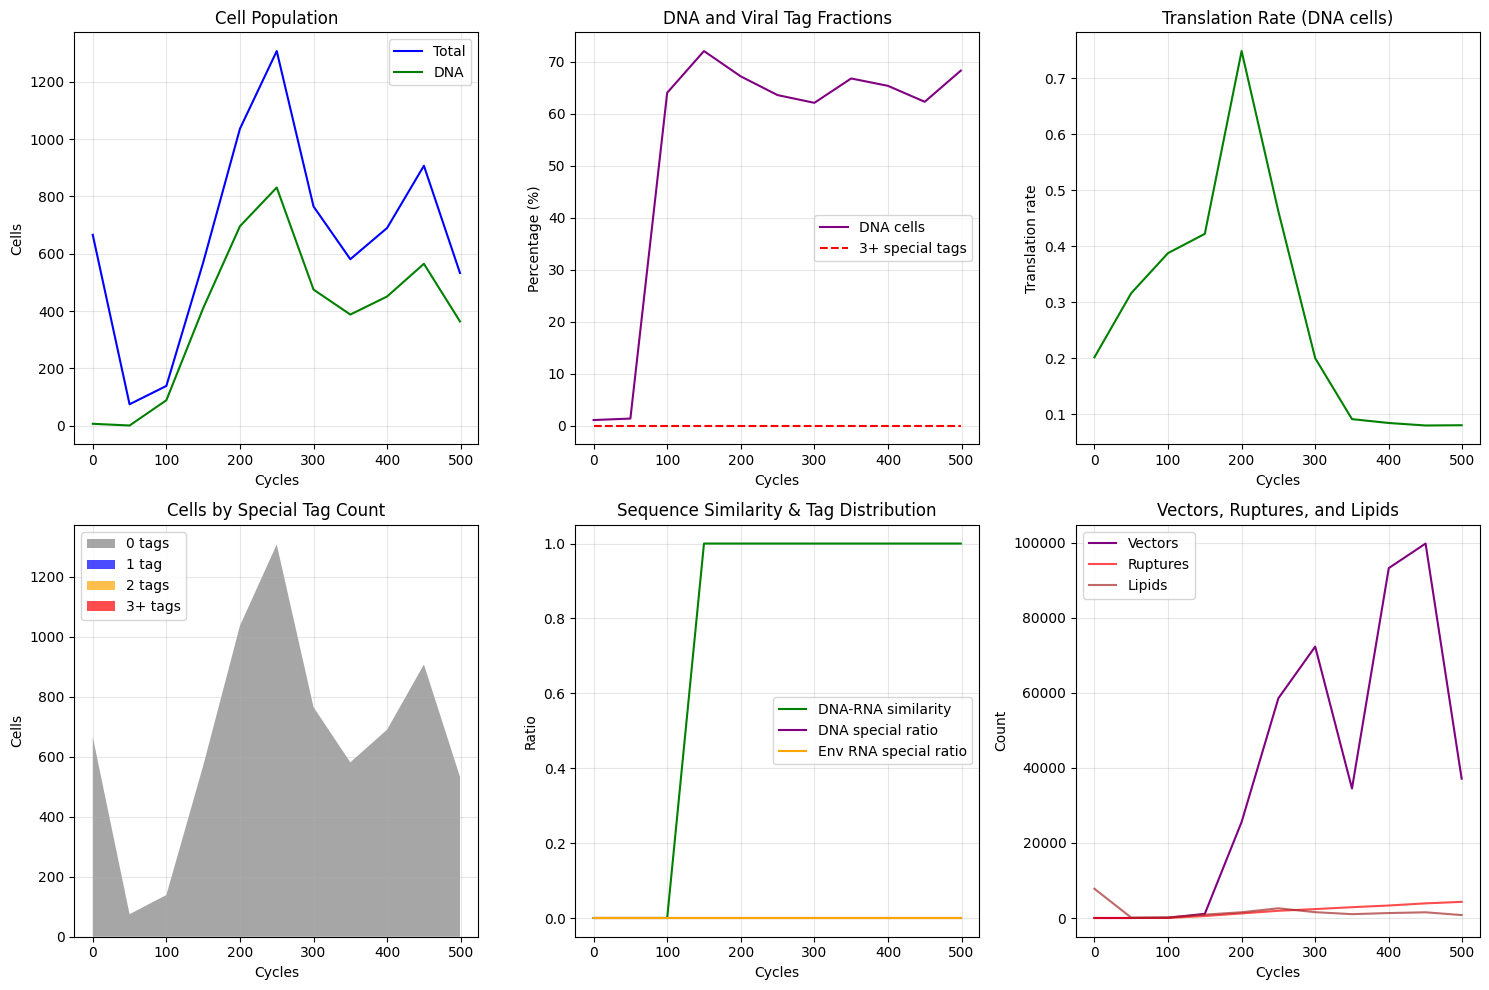


Stage 2 Summary
Total cells: 533
DNA cells: 364 (68.3%)
Cells with 3+ special tags (viral): 0 (0.0%)
DNA special tag ratio: 0.0%
DNA-RNA sequence similarity: 1.00
Primitive vectors: 37106
Extinctions: 0
Rupture events: 4300
Fusion events: 47424
New cells formed: 44418
Final translation (DNA): 0.375487

  ✓ High DNA-RNA similarity detected!
    This confirms reverse transcription is faithfully
    capturing environmental RNA sequences.

  ~ DNA cells reached majority

SIMULATION COMPLETE


In [ ]:
# ============================================================================
# Part 6: Main Program
# ============================================================================

if __name__ == "__main__":
    print("=" * 80)
    print("STAGE 2: DNA Emergence with Protein-Dependent Replication")
    print("=" * 80)
    print("\nKey Features:")
    print("  • DNA replication rate depends on protein synthesis")
    print("  • Cell division requires sufficient protein")
    print("  • Dual-tag system: Normal tags (10x/20x/30x) + Special tags (30x/100x/1000x)")
    print("  • DNA-RNA similarity tracking confirms reverse transcription")
    print("  • Multi-cell encapsulation based on lipid availability")
    print()

    random.seed(42)
    initialize_tags()

    sim = Stage2Simulation(
        pool_a_file='converged_rna_pool.json',
        num_cycles=500,
        initial_cells=50,
        max_cells=10000,
        pool_a_to_b_transfer_fraction=0.1,
        lipid_transfer_fraction=0.3,
        initial_lipids=10000.0,
        lipids_per_new_cell=3.0,
        lipids_required_for_division=5.0,
        lipids_released_on_rupture=30.0,
        lipid_decay_rate=0.03,
        osmotic_rupture_threshold=8000.0,
        max_rupture_probability=0.3,
        division_threshold=5000.0,
        protein_division_threshold=100.0,
        cell_fusion_probability=0.08,
        fusion_dry_phase_boost=2.0,
        encapsulation_rate=1.0,
        encapsulation_fraction=0.7,
        encapsulation_dna_prob_base=0.05,
        encapsulation_fraction_of_lipids=0.2,
        env_reverse_transcription_rate=0.01,
        dna_replication_base_rate=1.02,
        dna_replication_protein_factor=0.1,
        dna_replication_cost=5.0,
        free_dna_decay_rate=0.1,
        free_dna_fragmentation_prob=0.5,
        fragment_min_len=10,
        fragment_max_len=30,
        random_rna_ratio=0.95,
        stable_rna_ratio=0.05,
        max_absorption_length=50,
        absorption_rate=30,
        dna_maintenance_cost=0.01,
        transcription_rate=0.5,
        transcription_fraction=0.7,
        reverse_transcriptase_activity=0.2,
        rna_inheritance_fraction=0.6,
        rna_degradation_rate=0.08,
        translation_scale_factor=0.02,
        diffusion_coefficient=0.08,
        env_amino_acid_conc=100.0,
        env_nucleotide_conc=100.0,
        rna_mass_per_copy=10.0,
        dna_mass_per_copy=100.0,
        protein_mass_per_unit=10.0,
        nucleotides_per_rna=1.0,
        nucleotides_per_dna=10.0,
        cell_size_factor=10.0,
        initial_amino_acids=50.0,
        initial_nucleotides=50.0,
        dna_initial_amino_acids=100.0,
        dna_initial_nucleotides=100.0
    )

    sim.run()
    sim.plot_results()
    sim.print_summary()

    print("\n" + "=" * 80)
    print("SIMULATION COMPLETE")
    print("=" * 80)

**The Co-evolutionary Dynamics of Cells and Primitive Viruses**

**Vectors: The Fragile Genetic Messengers**

In the simulation results, Vectors represent free DNA molecules released into the environment after cell rupture. These primitive genetic fragments are inherently unstable in the hot spring environment and will gradually degrade over time. Their transient nature means they cannot persist independently; they must find a new host quickly or be lost forever.

However, when DNA associates with proteins (and sometimes RNA), they form complex macromolecular assemblies with significantly greater stability than naked DNA. This principle manifests in two fundamental forms in modern biology: chromosomes (DNA compacted with histone proteins, serving as the standard genetic archive in all cellular life) and viruses (nucleic acid encapsulated in protein capsids, serving as the infectious vector form). Both forms achieve the same goal—protecting genetic information from environmental degradation—but serve opposite strategies: one stays home, the other travels.

**The Mechanism of Viral Lysis**

**Osmotic Catastrophe Driven by Environmental Cycles**

For a primitive cell infected with a parasitic genetic element, the path to lysis is not determined by the virus alone—it is a collaborative act between the pathogen’s replication strategy and the physical properties of the host membrane under fluctuating environmental conditions. This model rests on a single foundational premise, which is also the key assumption of the broader Stability-Distillation Hypothesis: the cell membrane's primitive, random pores allow the monomers of biopolymers (amino acids, nucleotides) to pass through more readily than their corresponding polymers (proteins, RNA, DNA). Once inside, these small molecules are covalently locked into macromolecules and can no longer escape. This differential permeability is the thermodynamic engine that drives all subsequent dynamics.

Now, consider an infected cell undergoing a complete wet-dry-wet cycle. The cascade proceeds through three distinct phases:

**Phase 1** : The Dry Phase — Viral Replication and Osmotic Decompression. The environment enters a dry period. The cell membrane dehydrates, its random pores constrict dramatically, and it becomes nearly impermeable even to small monomers. The internal supply of free amino acids and nucleotides is finite. The virus, having hijacked the cell’s translation and replication machinery, consumes this dwindling pool of monomers to synthesize its own proteins and nucleic acids. Critically, this process reduces the total number of osmotically active solute particles inside the cell, because many free monomers are now covalently linked into a much smaller number of large, osmotically less active polymer chains. The cell’s internal osmotic pressure actually drops. Yet, because the constricted membrane prevents water from entering, the cell does not swell; it remains in a stable, albeit metabolically stressed, non-turgid state. The virus has effectively "loaded the explosive" but has not yet armed the detonator.

**Phase 2**: The Wet Phase — Arming the Detonator. The dry period ends, and moisture returns, driven by rainfall, a rising water table, or the periodic eruption of a geyser. The temperature also rises. Both factors increase membrane fluidity, causing the random pores to widen significantly. This is the critical window for the virus. The widened pores now allow the free diffusion of small molecules—amino acids, nucleotides—that are abundant in the external environment. Drawn by the concentration gradient created by the virus’s voracious consumption in Phase 1, these monomers flood into the cell. However, they are not allowed to simply accumulate as monomers. Inside the cell, the virus’s high-efficiency replication machinery immediately captures and incorporates them into new viral polymers (proteins, RNA, DNA). In a physicochemical sense, the virus is acting as a molecular ratchet pump. It does not need to encode any membrane-disrupting proteins. It simply uses the cyclical availability of membrane permeability to passively import raw materials and then chemically locks them inside as non-diffusible molecules. The total number of osmotically active particles trapped inside the cell—monomers that have entered and their counterions required to maintain electroneutrality—surges dramatically.

**Phase 3**: The Cooling-Contraction Phase — Detonation. Following the wet period, the temperature moderates. The membrane cools, its fluidity decreases, and the random pores contract and disappear, once again sealing the cell. It is at this specific moment that the cell faces an irreversible osmotic crisis. The external environment remains wet, providing an effectively infinite source of water. Inside the cell, however, the osmotic pressure has reached its absolute peak due to the newly synthesized macromolecules and all the additional free solutes still residing within. Osmosis relentlessly drives water inward. The primitive membrane, lacking any rigid cell wall or sophisticated osmoregulatory channels, expands until it reaches its physical limit. The cell swells, the membrane ruptures, and its contents—including the newly replicated viral polymers—are violently expelled into the environment.

Conclusion of the Physical Mechanism. This entire sequence constitutes a form of environmentally-driven physical lysis. The virus does not need to evolve a dedicated "lysis protein." The mechanism is an emergent property of three interacting factors: (1) the fundamental differential permeability of a primitive fatty-acid membrane, (2) the thermodynamic drive of osmosis, and (3) the periodic fluctuations of a wet-dry environment. It was this automatic, physical disruption of the host cell that constituted the earliest "viral reproduction cycle" and formed the relentless selection pressure that ultimately drove the evolution of true, genetically encoded lytic enzymes as viruses and their hosts entered an evolutionary arms race.



**The Genetic Legacy in Modern Cells**

The simulation explains two major classes of genetic elements found in all modern cells.

The first class is housekeeping RNAs, including tRNA, rRNA, and snRNAs. These short, stable RNA sequences are not evolutionary accidents. They represent the ancient environmental RNA pool that was reverse-transcribed into the first genomes. Cells did not invent these RNAs from scratch; they captured them from the environment and preserved them in DNA. The universal conservation of tRNA and rRNA across all life is evidence of this ancestral capture event.

The second class is viral sequences in genomes, known as endogenous viral elements. Modern genomes are littered with sequences derived from ancient viruses—from endogenous retroviruses (which make up approximately 8 percent of the human genome) to integrated phage sequences in bacteria. The simulation demonstrates that these are not mere parasites or genomic junk. They are the fossil record of the long-term co-evolutionary relationship between cells and viruses. Some viral sequences become domesticated, evolving into essential cellular functions such as syncytin in placental development. Others remain as dormant remnants, reactivatable under specific conditions.

**Conclusion: The Unbreakable Bond**

The simulation reveals a profound truth about the nature of life: cells and viruses did not originate separately and then encounter each other. They were born together, locked in a co-evolutionary embrace that has never been broken.

Cells provide the factory—ribosomes, metabolism, and membrane enclosure. Viruses provide the vector—horizontal gene transfer and rapid evolution. The cell's genome is a library, a stable archive of useful genetic information. The virus is a librarian, a carrier that moves books between libraries. Neither is complete without the other.

This perspective transforms our understanding of the genome. The vast non-coding regions, the retrotransposons, the endogenous retroviruses—these are not parasites or junk DNA. They are the living history of the billion-year conversation between cells and viruses, written in the language of nucleic acids.

